# Phase separation with simple 2D autoencoders and an EGNN

This notebook builds the benchmark in eight stages:

1. **Liquid vs FCC:** an easier binary phase-separation baseline.
2. **FCC vs HCP:** a difficult binary comparison that exposes the limitations of local reconstruction with a simple dense autoencoder.
3. **Liquid vs FCC vs HCP:** the same invariant-input experiment with all three classes.
4. **EGNN:** a neighborhood graph encoder with invariant pooling, a dense two-dimensional bottleneck, and target-specific MLP decoders.
5. **Minimal EGNN upgrade:** a small anti-collapse and readout follow-up for the three-class experiment.
6. **Working EGNN recipe, liquid vs FCC:** the standalone EGNN setup applied to four reconstruction targets and both shells, including 30 seeded probe runs.
7. **Reconstruction-driven EGNN:** a return to the coordinate-updating EGNN, with reconstruction as the only training objective and a complete 30-seed liquid/FCC robustness run.
8. **Full-data PCA-decoder EGNN:** the final two-class recipe from `egnn_reconstruction_signal_exploration.ipynb`, repeated end-to-end for 30 seeds.

Every bottleneck is exactly two-dimensional, so latent plots show the learned coordinates directly—there is no PCA, t-SNE, or UMAP. Each simple-autoencoder comparison and the final binary working-EGNN comparison use a visual run plus **30 complete seeded runs** for their robustness distributions.

| comparison | inputs or reconstruction targets | first shell | second shell |
|---|---|---|---|
| liquid vs FCC | center distances, pairwise distances, vectors, $q_l$ | 12 NN | 18 NN |
| FCC vs HCP | center distances, pairwise distances, central triplet angles, $q_l$ | 12 NN | 18 NN |
| all three phases | center distances, pairwise distances, central triplet angles, $q_l$ | 12 NN | 18 NN |
| EGNN, all three phases | graph input; separate MLP decoders for the four invariant targets | 12 NN | 18 NN |
| minimal-upgrade EGNN, all three phases | graph input; invariant reconstruction targets and latent-usage regularization | 12 NN | 18 NN |
| working-recipe EGNN, liquid vs FCC | graph input; center distances, pairwise distances, vectors, $q_l$ | 12 NN | 18 NN |
| reconstruction-driven EGNN, liquid vs FCC | center-inclusive, degree-normalized graph encoder; center distances, pairwise distances, vectors, $q_l$ | 12 NN | 18 NN |
| full-data PCA-decoder EGNN, liquid vs FCC | center-aware RBF graph encoder; fixed inverse-PCA decoders for center distances, pairwise distances, vectors, $q_l$ | 12 NN | 18 NN |

The $q_l$ convention is standard/non-averaged for one shell and Lechner–Dellago averaged for two shells. See the data-integrity warning below: the currently available second-shell NPZs contain 18 geometric neighbors but stored averaged $q_l$ values calculated with 12 neighbors.

Shared evaluation protocol:

- Phase labels never enter an encoder or decoder. They are used only for balanced sampling, splitting, visualization, and downstream probes.
- Simulation frames, rather than particles, are assigned to train/validation/test partitions, preventing snapshot leakage.
- Feature and target scalers are fitted on the training partition only.
- A logistic-regression probe is fitted on train + validation latent vectors and evaluated once on held-out test frames.
- The same sampled particles and frame split are reused across representations and shells within each seed.


In [55]:
# Imports
import gc
import os
import random
import warnings
from copy import deepcopy
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [56]:
# Configuration
PHASES = ("liquid", "fcc")
LABEL_MAP = {"liquid": 0, "fcc": 1}
LABEL_NAMES = {0: "liquid", 1: "fcc"}
LABEL_COLORS = {0: "tab:green", 1: "tab:blue"}

SHELL_CONFIG = {
    "first_shell": {
        "label": "1 shell (12 NN)",
        "filenames": ("particle_data.npz",),
        "n_neighbors": 12,
        "ql_key": "ql_no_average",
        "ql_variant": "standard",
    },
    "second_shell": {
        "label": "2 shells (18 NN)",
        # Prefer the correctly regenerated file; fall back with an explicit warning.
        "filenames": (
            "particle_data_second_shell_nn18_ql18.npz",
            "particle_data_second_shell.npz",
        ),
        "n_neighbors": 18,
        "ql_key": "ql",
        "ql_variant": "Lechner-Dellago averaged",
    },
}
SHELL_ORDER = tuple(SHELL_CONFIG)
FEATURE_ORDER = ("radii", "pairwise_distances", "vectors", "ql")
FEATURE_LABELS = {
    "radii": "Center distances",
    "pairwise_distances": "Pairwise distances",
    "vectors": "Neighbor vectors",
    "ql": r"$q_l$",
}

VISUAL_SEED = 42
# Exactly 30 complete runs: the visual seed plus 29 additional seeds.
ROBUSTNESS_SEEDS = (VISUAL_SEED, *range(29))
MAX_SAMPLES_PER_PHASE = 12_000
EPOCHS = 25
BATCH_SIZE = 512
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 6
VAL_FRACTION = 0.20
TEST_FRACTION = 0.20
MAX_PLOT_POINTS_PER_PHASE = 3_000
PAIRWISE_CHUNK_SIZE = 2_048

# Set AE_SMOKE_TEST=1 before starting the kernel for a fast end-to-end check.
if os.environ.get("AE_SMOKE_TEST") == "1":
    MAX_SAMPLES_PER_PHASE = 512
    EPOCHS = 2
    EARLY_STOPPING_PATIENCE = 2
    ROBUSTNESS_SEEDS = (VISUAL_SEED, 71)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR_CANDIDATES = (
    Path("."),
    Path("lammps/LJ/statistically_independent_samples/statistically_independent_samples"),
    Path("autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples"),
)
DATA_DIR = next(
    (
        path
        for path in DATA_DIR_CANDIDATES
        if all((path / phase / "particle_data.npz").exists() for phase in PHASES)
    ),
    None,
)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not locate the liquid and fcc particle_data.npz files. "
        "Run the notebook from its directory or from the repository root."
    )

print("Data:", DATA_DIR.resolve())
print("Device:", DEVICE)
print("Main seed:", VISUAL_SEED)
print("Robustness seeds:", ROBUSTNESS_SEEDS)

Data: /home/jakob/Masterabeit/autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples
Device: cuda
Main seed: 42
Robustness seeds: (42, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28)


## 1. Load and validate the prepared neighborhood data

Distances are sorted per sample and the vectors are reordered by the same permutation. This gives the vector baseline a deterministic radial ordering, but does not make it rotation invariant. Near-degenerate neighbor radii can also swap order, which is one reason this representation is expected to be fragile.

In [57]:
def _scalar(npz, key, default=None):
    if key not in npz.files:
        return default
    value = np.asarray(npz[key])
    return value.item() if value.shape == () else value.tolist()


def _resolve_shell_file(phase, shell_name):
    for filename in SHELL_CONFIG[shell_name]["filenames"]:
        candidate = DATA_DIR / phase / filename
        if candidate.exists():
            return candidate
    tried = ", ".join(SHELL_CONFIG[shell_name]["filenames"])
    raise FileNotFoundError(f"No {shell_name} file for {phase}; tried: {tried}")


def load_particle_data(path, ql_key):
    with np.load(path, allow_pickle=True) as npz:
        dist = np.asarray(npz["dist"], dtype=np.float32)
        vec = np.asarray(npz["vec_dist"], dtype=np.float32)
        if vec.ndim == 2 and vec.shape[1] % 3 == 0:
            vec = vec.reshape(vec.shape[0], vec.shape[1] // 3, 3)
        if vec.ndim != 3 or vec.shape[2] != 3:
            raise ValueError(f"Unexpected vec_dist shape in {path}: {vec.shape}")
        if ql_key not in npz.files:
            raise KeyError(f"{path} does not contain requested key {ql_key!r}")

        data = {
            "dist": dist,
            "vec_dist": vec,
            "ql": np.asarray(npz[ql_key], dtype=np.float32),
            "picked_ids": np.asarray(npz["picked_ids"], dtype=np.int32),
            "frame_indices": np.asarray(npz["frame_indices"], dtype=np.int32),
            "nn_metadata": int(_scalar(npz, "nn", dist.shape[1])),
            "descriptor_nn": int(_scalar(npz, "descriptor_nn", _scalar(npz, "nn", dist.shape[1]))),
            "source": path,
        }

    order = np.argsort(data["dist"], axis=1)
    data["dist"] = np.take_along_axis(data["dist"], order, axis=1)
    data["vec_dist"] = np.take_along_axis(data["vec_dist"], order[:, :, None], axis=1)
    return data


shell_data = {}
summary_rows = []
for shell_name, config in SHELL_CONFIG.items():
    shell_data[shell_name] = {}
    for phase in PHASES:
        path = _resolve_shell_file(phase, shell_name)
        data = load_particle_data(path, config["ql_key"])
        expected_nn = config["n_neighbors"]
        if data["dist"].shape[1] != expected_nn or data["vec_dist"].shape[1] != expected_nn:
            raise ValueError(
                f"{path}: expected {expected_nn} geometric neighbors, "
                f"got dist={data['dist'].shape[1]} and vec={data['vec_dist'].shape[1]}"
            )
        ql_exact = data["descriptor_nn"] == expected_nn
        if not ql_exact:
            warnings.warn(
                f"{path.name} ({phase}): q_l used {data['descriptor_nn']} neighbors, "
                f"not the requested {expected_nn}. Regenerate the exact second-shell file "
                "to make this q_l experiment strictly 18-NN.",
                stacklevel=2,
            )
        data["ql_exact"] = ql_exact
        shell_data[shell_name][phase] = data
        summary_rows.append(
            {
                "shell": config["label"],
                "phase": phase,
                "file": path.name,
                "samples": len(data["dist"]),
                "geometric_NN": data["dist"].shape[1],
                "q_l_key": config["ql_key"],
                "q_l_variant": config["ql_variant"],
                "q_l_descriptor_NN": data["descriptor_nn"],
                "q_l_exact_requested_NN": ql_exact,
            }
        )

# The exact same picked particles must be used for a paired shell comparison.
for phase in PHASES:
    first = shell_data["first_shell"][phase]
    second = shell_data["second_shell"][phase]
    if not np.array_equal(first["picked_ids"], second["picked_ids"]):
        raise ValueError(f"Picked particle IDs differ between shells for {phase}.")
    if not np.array_equal(first["frame_indices"], second["frame_indices"]):
        raise ValueError(f"Frame indices differ between shells for {phase}.")

data_summary = pd.DataFrame(summary_rows)
display(data_summary)

/home/jakob/miniconda3/envs/autoencode-statmech/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3579: UserWarning: particle_data_second_shell.npz (liquid): q_l used 12 neighbors, not the requested 18. Regenerate the exact second-shell file to make this q_l experiment strictly 18-NN.
  exec(code_obj, self.user_global_ns, self.user_ns)
/home/jakob/miniconda3/envs/autoencode-statmech/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3579: UserWarning: particle_data_second_shell.npz (fcc): q_l used 12 neighbors, not the requested 18. Regenerate the exact second-shell file to make this q_l experiment strictly 18-NN.
  exec(code_obj, self.user_global_ns, self.user_ns)


,shell,phase,file,samples,geometric_NN,q_l_key,q_l_variant,q_l_descriptor_NN,q_l_exact_requested_NN
0,1 shell (12 NN),liquid,particle_data.npz,90300,12,ql_no_average,standard,12,True
1,1 shell (12 NN),fcc,particle_data.npz,180300,12,ql_no_average,standard,12,True
2,2 shells (18 NN),liquid,particle_data_second_shell.npz,90300,18,ql,Lechner-Dellago averaged,12,False
3,2 shells (18 NN),fcc,particle_data_second_shell.npz,180300,18,ql,Lechner-Dellago averaged,12,False


### Producing exact 18-neighbor Dellago-averaged q_l data

The checked-in preprocessing script already supports the needed setting. From each phase directory, regenerate the preferred file with the same picked particles:

    python ../../../preprocess_traj.py \
        -f traj.lammpstrj \
        -npick 300 \
        -nn 18 \
        -descriptor_nn 18 \
        -picked_ids_from particle_data.npz \
        -o particle_data_second_shell_nn18_ql18.npz

This is intentionally not launched by the notebook because it scans multi-gigabyte trajectories and also recomputes the other structural descriptors. After both files exist, rerun from the loading cell; the exact files are selected automatically.

## 2. Feature construction and leakage-safe sampling

Pairwise inputs contain the center at the origin and use every unique point-to-point distance. Sorting this distance signature removes point ordering. Vector inputs are flattened after radial neighbor sorting; they remain tied to the laboratory coordinate frame.

In [58]:
def pairwise_distance_features(vectors, chunk_size=PAIRWISE_CHUNK_SIZE):
    """All upper-triangle distances among the center and its neighbors."""
    n_samples, n_neighbors, _ = vectors.shape
    n_points = n_neighbors + 1
    upper_i, upper_j = np.triu_indices(n_points, k=1)
    output = np.empty((n_samples, len(upper_i)), dtype=np.float32)

    for start in range(0, n_samples, chunk_size):
        stop = min(start + chunk_size, n_samples)
        center = np.zeros((stop - start, 1, 3), dtype=np.float32)
        points = np.concatenate((center, vectors[start:stop]), axis=1)
        delta = points[:, upper_i, :] - points[:, upper_j, :]
        output[start:stop] = np.linalg.norm(delta, axis=-1)
    output.sort(axis=1)
    return output


def build_feature(data, feature_kind, indices):
    if feature_kind == "radii":
        return data["dist"][indices].copy()
    if feature_kind == "pairwise_distances":
        return pairwise_distance_features(data["vec_dist"][indices])
    if feature_kind == "vectors":
        return data["vec_dist"][indices].reshape(len(indices), -1).copy()
    if feature_kind == "ql":
        return data["ql"][indices].copy()
    raise KeyError(feature_kind)


def _frame_split(frame_indices, rng):
    """Assign whole frames to 60/20/20 train/validation/test partitions."""
    unique_frames = np.unique(frame_indices)
    if len(unique_frames) < 5:
        raise ValueError("At least five distinct frames per phase are required.")
    shuffled = rng.permutation(unique_frames)
    n_test = max(1, int(round(TEST_FRACTION * len(shuffled))))
    n_val = max(1, int(round(VAL_FRACTION * len(shuffled))))
    test_frames = shuffled[:n_test]
    val_frames = shuffled[n_test:n_test + n_val]

    split = np.full(len(frame_indices), "train", dtype="<U5")
    split[np.isin(frame_indices, val_frames)] = "val"
    split[np.isin(frame_indices, test_frames)] = "test"
    return split


def build_sampling_plan(reference_shell, seed):
    """Balanced particle sampling plus phase-stratified frame-group splitting."""
    rng = np.random.default_rng(seed)
    n_per_phase = min(
        MAX_SAMPLES_PER_PHASE,
        *(len(reference_shell[phase]["dist"]) for phase in PHASES),
    )
    plan = {}
    for phase in PHASES:
        data = reference_shell[phase]
        indices = np.sort(rng.choice(len(data["dist"]), size=n_per_phase, replace=False))
        split = _frame_split(data["frame_indices"][indices], rng)
        plan[phase] = {"indices": indices, "split": split}
    return plan


def summarize_plan(plan):
    rows = []
    for phase in PHASES:
        entry = plan[phase]
        frames = shell_data["first_shell"][phase]["frame_indices"][entry["indices"]]
        for split_name in ("train", "val", "test"):
            mask = entry["split"] == split_name
            rows.append(
                {
                    "phase": phase,
                    "partition": split_name,
                    "particles": int(mask.sum()),
                    "frames": int(np.unique(frames[mask]).size),
                }
            )
    return pd.DataFrame(rows)


def prepare_experiment(shell_name, feature_kind, plan):
    X_parts, y_parts, split_parts = [], [], []
    for phase in PHASES:
        entry = plan[phase]
        X_parts.append(
            build_feature(shell_data[shell_name][phase], feature_kind, entry["indices"])
        )
        y_parts.append(np.full(len(entry["indices"]), LABEL_MAP[phase], dtype=np.int64))
        split_parts.append(entry["split"])
    return (
        np.concatenate(X_parts).astype(np.float32, copy=False),
        np.concatenate(y_parts),
        np.concatenate(split_parts),
    )

example_plan = build_sampling_plan(shell_data["first_shell"], VISUAL_SEED)
display(summarize_plan(example_plan))

,phase,partition,particles,frames
0,liquid,train,7152,181
1,liquid,val,2409,60
2,liquid,test,2439,60
3,fcc,train,7191,361
4,fcc,val,2367,120
5,fcc,test,2442,120


## 3. Two-dimensional autoencoder and linear probe

The nonlinear autoencoder is deliberately small. Its decoder ends in a sigmoid because each input feature is min-max scaled from the training data. The two latent units have no activation constraint.

Early stopping monitors validation reconstruction MSE and restores the best epoch. The test frames are never used to fit the scaler, autoencoder, or probe.

In [59]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


class SimpleAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=2):
        super().__init__()
        hidden_dim = max(32, min(256, 2 * input_dim))
        mid_dim = max(16, hidden_dim // 2)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, mid_dim),
            nn.SiLU(),
            nn.Linear(mid_dim, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, mid_dim),
            nn.SiLU(),
            nn.Linear(mid_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


def _encode_in_batches(model, X_scaled, batch_size=BATCH_SIZE):
    loader = DataLoader(
        TensorDataset(torch.from_numpy(X_scaled)),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )
    chunks = []
    model.eval()
    with torch.no_grad():
        for (xb,) in loader:
            chunks.append(model.encoder(xb.to(DEVICE)).cpu().numpy())
    return np.concatenate(chunks)


def train_autoencoder(X, split, seed):
    set_seed(seed)
    train_mask = split == "train"
    val_mask = split == "val"

    scaler = MinMaxScaler()
    X_scaled = np.empty_like(X, dtype=np.float32)
    scaler.fit(X[train_mask])
    X_scaled[:] = scaler.transform(X).astype(np.float32)

    train_tensor = torch.from_numpy(X_scaled[train_mask])
    val_tensor = torch.from_numpy(X_scaled[val_mask])
    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(
        TensorDataset(train_tensor, train_tensor),
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
        num_workers=0,
    )
    val_loader = DataLoader(
        TensorDataset(val_tensor, val_tensor),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )

    model = SimpleAutoencoder(X.shape[1], latent_dim=2).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    criterion = nn.MSELoss()
    history = {"train_mse": [], "val_mse": []}
    best_state = None
    best_val = np.inf
    best_epoch = -1
    stale_epochs = 0

    for epoch in range(EPOCHS):
        model.train()
        running = 0.0
        for xb, target in train_loader:
            xb, target = xb.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(xb), target)
            loss.backward()
            optimizer.step()
            running += loss.item() * len(xb)
        train_mse = running / len(train_tensor)

        model.eval()
        running = 0.0
        with torch.no_grad():
            for xb, target in val_loader:
                xb, target = xb.to(DEVICE), target.to(DEVICE)
                running += criterion(model(xb), target).item() * len(xb)
        val_mse = running / len(val_tensor)
        history["train_mse"].append(train_mse)
        history["val_mse"].append(val_mse)

        if val_mse < best_val - 1e-8:
            best_val = val_mse
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= EARLY_STOPPING_PATIENCE:
                break

    model.load_state_dict(best_state)
    Z = _encode_in_batches(model, X_scaled)
    return {
        "model": model,
        "scaler": scaler,
        "history": history,
        "Z": Z,
        "best_epoch": best_epoch + 1,
        "best_val_mse": float(best_val),
    }


def probe_latent(Z, y, split, seed):
    fit_mask = split != "test"
    test_mask = split == "test"
    probe = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=5_000,
            class_weight="balanced",
            random_state=seed,
        ),
    )
    probe.fit(Z[fit_mask], y[fit_mask])
    y_test = y[test_mask]
    y_pred = probe.predict(Z[test_mask])
    y_score = probe.predict_proba(Z[test_mask])[:, list(probe.classes_).index(1)]
    return {
        "probe": probe,
        "y_test": y_test,
        "y_pred": y_pred,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "roc_auc": roc_auc_score(y_test, y_score),
    }

In [60]:
def run_suite(seed, keep_artifacts=True, verbose=True):
    plan = build_sampling_plan(shell_data["first_shell"], seed)
    rows = []
    artifacts = {}

    for shell_name in SHELL_ORDER:
        shell_cfg = SHELL_CONFIG[shell_name]
        ql_exact = all(shell_data[shell_name][phase]["ql_exact"] for phase in PHASES)
        for feature_kind in FEATURE_ORDER:
            if verbose:
                print(
                    f"seed={seed:>3} | {shell_cfg['label']:<18} | "
                    f"{FEATURE_LABELS[feature_kind]}"
                )
            X, y, split = prepare_experiment(shell_name, feature_kind, plan)
            ae = train_autoencoder(X, split, seed)
            probe = probe_latent(ae["Z"], y, split, seed)

            rows.append(
                {
                    "seed": seed,
                    "shell": shell_name,
                    "shell_label": shell_cfg["label"],
                    "n_neighbors": shell_cfg["n_neighbors"],
                    "feature": feature_kind,
                    "feature_label": FEATURE_LABELS[feature_kind],
                    "input_dim": X.shape[1],
                    "n_samples": len(X),
                    "best_epoch": ae["best_epoch"],
                    "validation_mse": ae["best_val_mse"],
                    "accuracy": probe["accuracy"],
                    "balanced_accuracy": probe["balanced_accuracy"],
                    "macro_f1": probe["macro_f1"],
                    "roc_auc": probe["roc_auc"],
                    "q_l_exact_requested_NN": ql_exact if feature_kind == "ql" else pd.NA,
                }
            )
            if keep_artifacts:
                artifacts[(shell_name, feature_kind)] = {
                    "Z": ae["Z"],
                    "y": y,
                    "split": split,
                    "history": ae["history"],
                    "model": ae["model"],
                    "scaler": ae["scaler"],
                    "probe": probe,
                }

            del X, ae
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return pd.DataFrame(rows), artifacts, plan

## Part I — Liquid vs FCC

### Main run: direct latent views and probe performance

In [61]:
main_scores, main_artifacts, main_plan = run_suite(
    VISUAL_SEED,
    keep_artifacts=True,
    verbose=True,
)

score_columns = [
    "shell_label",
    "feature_label",
    "input_dim",
    "best_epoch",
    "validation_mse",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "roc_auc",
    "q_l_exact_requested_NN",
]
display(
    main_scores[score_columns]
    .sort_values(["feature_label", "shell_label"])
    .reset_index(drop=True)
    .round(4)
)

seed= 42 | 1 shell (12 NN)    | Center distances
seed= 42 | 1 shell (12 NN)    | Pairwise distances
seed= 42 | 1 shell (12 NN)    | Neighbor vectors
seed= 42 | 1 shell (12 NN)    | $q_l$
seed= 42 | 2 shells (18 NN)   | Center distances
seed= 42 | 2 shells (18 NN)   | Pairwise distances
seed= 42 | 2 shells (18 NN)   | Neighbor vectors
seed= 42 | 2 shells (18 NN)   | $q_l$


,shell_label,feature_label,input_dim,best_epoch,validation_mse,accuracy,balanced_accuracy,macro_f1,roc_auc,q_l_exact_requested_NN
0,1 shell (12 NN),$q_l$,20,25,0.0081,0.9430,0.9431,0.9430,0.9806,True
1,2 shells (18 NN),$q_l$,20,25,0.0065,1.0000,1.0000,1.0000,1.0000,False
2,1 shell (12 NN),Center distances,12,25,0.0051,0.8847,0.8847,0.8847,0.9524,<NA>
3,2 shells (18 NN),Center distances,18,25,0.0081,0.9267,0.9266,0.9266,0.9780,<NA>
4,1 shell (12 NN),Neighbor vectors,36,25,0.0613,0.5153,0.5153,0.5143,0.5202,<NA>
5,2 shells (18 NN),Neighbor vectors,54,25,0.0642,0.5151,0.5151,0.5150,0.5099,<NA>
6,1 shell (12 NN),Pairwise distances,78,22,0.0017,0.9385,0.9385,0.9385,0.9834,<NA>
7,2 shells (18 NN),Pairwise distances,171,25,0.0015,0.9836,0.9836,0.9836,0.9980,<NA>


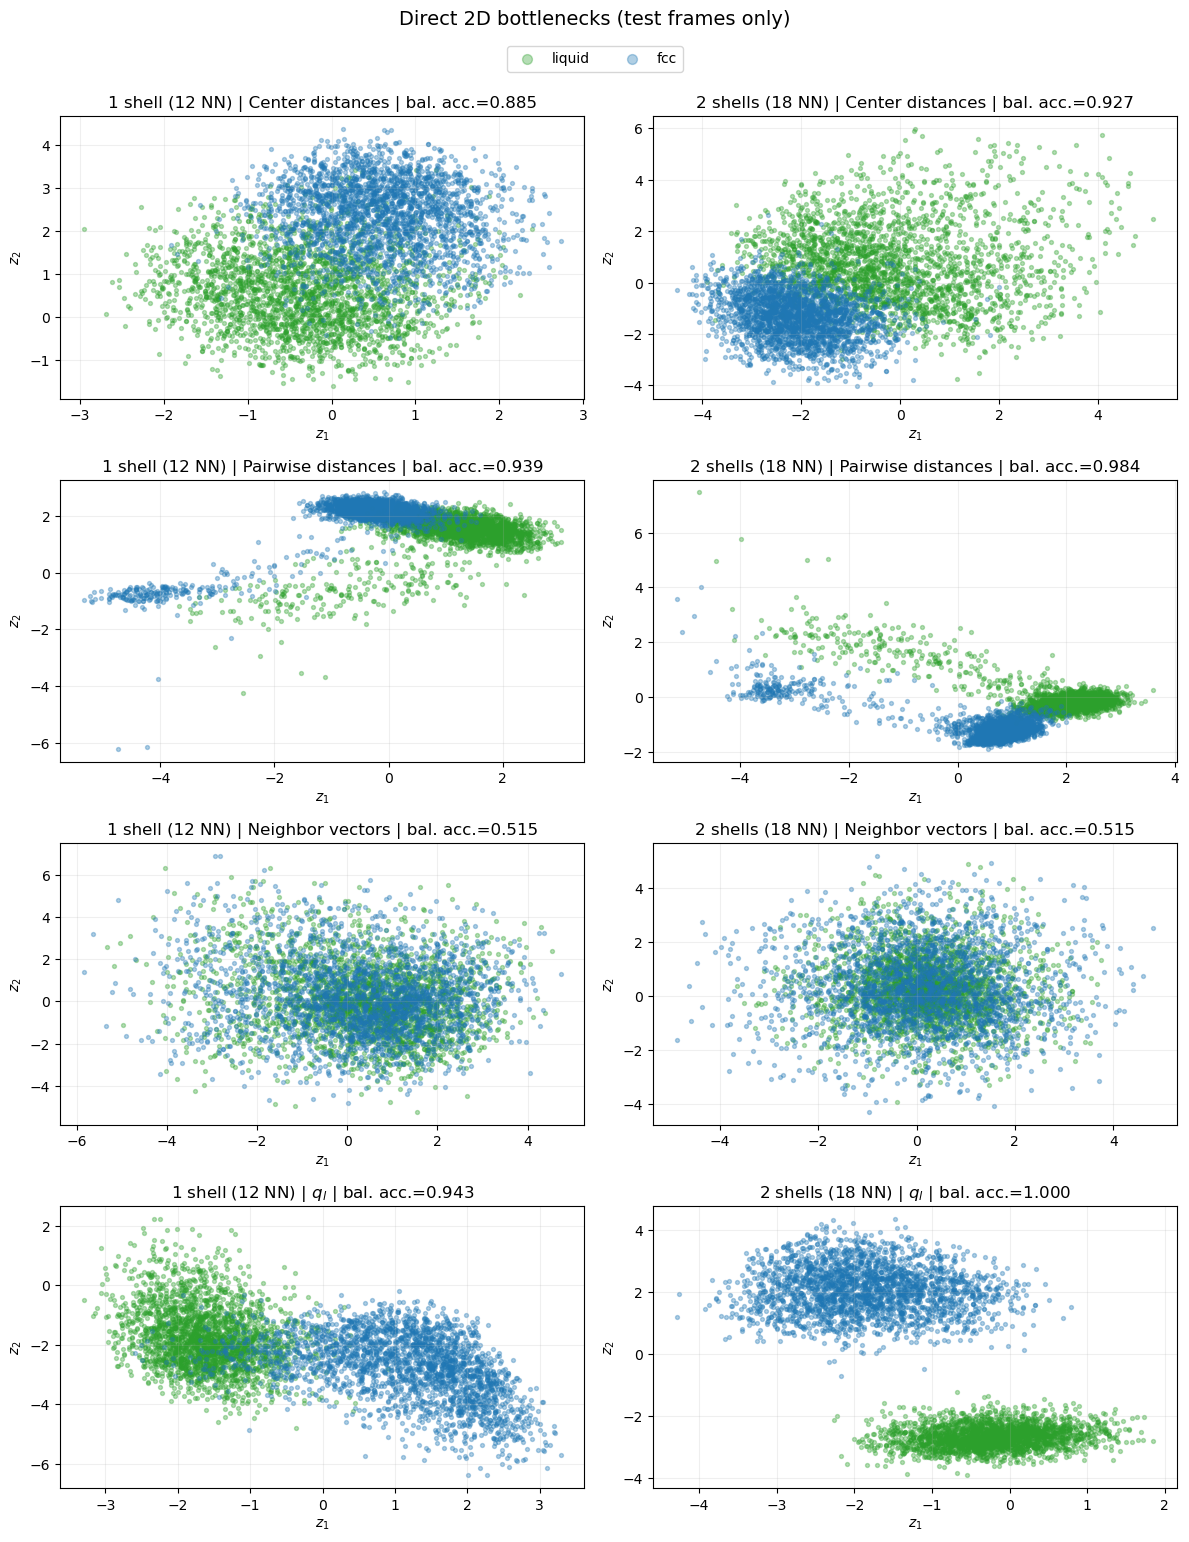

In [62]:
def plot_latent_grid(artifacts, split_to_plot="test"):
    fig, axes = plt.subplots(
        len(FEATURE_ORDER),
        len(SHELL_ORDER),
        figsize=(12, 15),
        squeeze=False,
    )
    rng = np.random.default_rng(VISUAL_SEED)

    for row, feature_kind in enumerate(FEATURE_ORDER):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            artifact = artifacts[(shell_name, feature_kind)]
            Z, y, split = artifact["Z"], artifact["y"], artifact["split"]
            keep = split == split_to_plot

            for phase in PHASES:
                label = LABEL_MAP[phase]
                indices = np.flatnonzero(keep & (y == label))
                if len(indices) > MAX_PLOT_POINTS_PER_PHASE:
                    indices = rng.choice(
                        indices,
                        size=MAX_PLOT_POINTS_PER_PHASE,
                        replace=False,
                    )
                ax.scatter(
                    Z[indices, 0],
                    Z[indices, 1],
                    s=8,
                    alpha=0.35,
                    color=LABEL_COLORS[label],
                    label=phase,
                    rasterized=True,
                )

            score = artifact["probe"]["balanced_accuracy"]
            ax.set_title(
                f"{SHELL_CONFIG[shell_name]['label']} | "
                f"{FEATURE_LABELS[feature_kind]} | bal. acc.={score:.3f}"
            )
            ax.set_xlabel(r"$z_1$")
            ax.set_ylabel(r"$z_2$")
            ax.grid(alpha=0.2)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2,
        bbox_to_anchor=(0.5, 1.005),
        markerscale=2.5,
    )
    fig.suptitle(
        f"Direct 2D bottlenecks ({split_to_plot} frames only)",
        y=1.025,
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


plot_latent_grid(main_artifacts, split_to_plot="test")

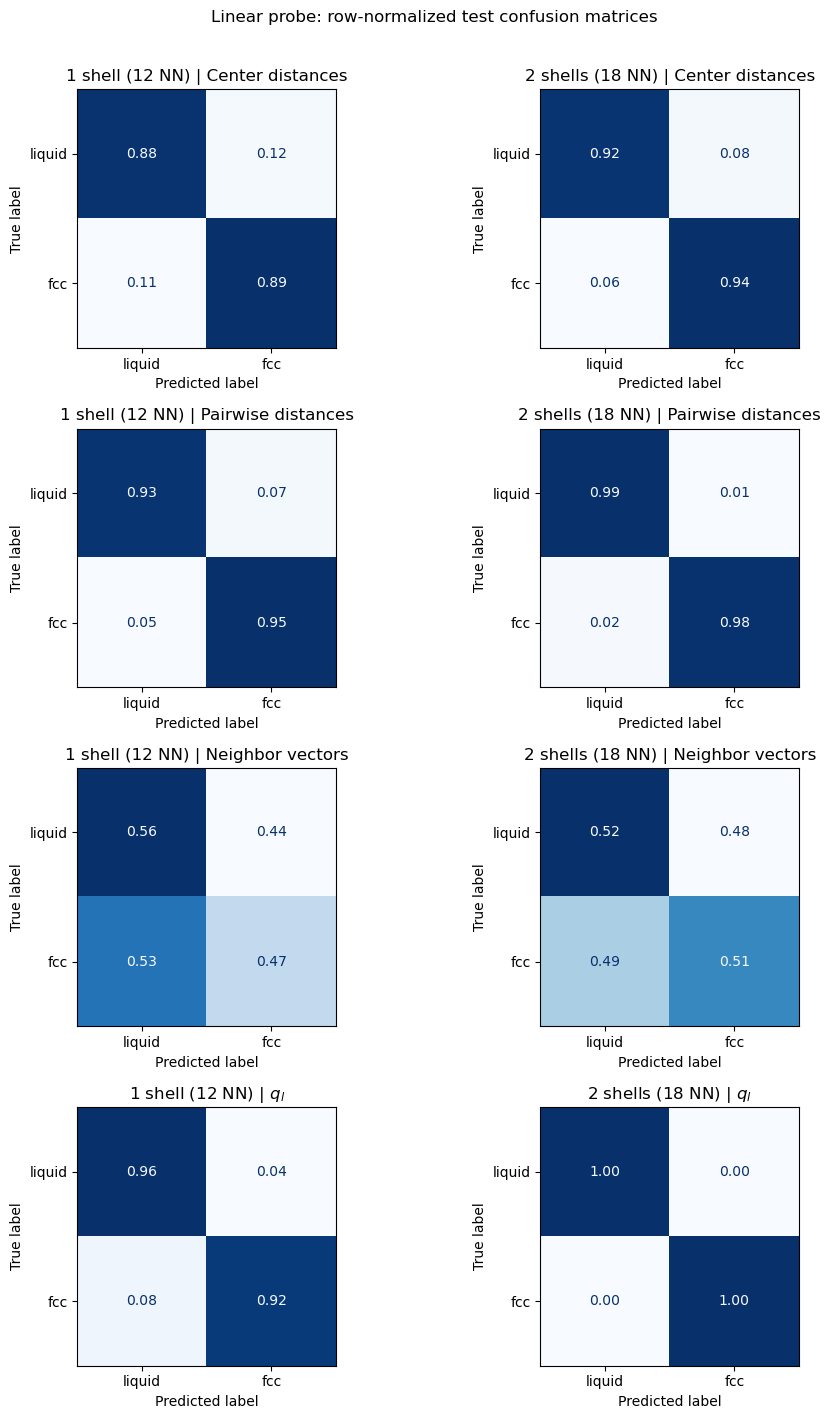

balanced_accuracy                         macro_f1  \
shell_label          1 shell (12 NN) 2 shells (18 NN) 1 shell (12 NN)   
feature_label                                                           
$q_l$                         0.9431           1.0000          0.9430   
Center distances              0.8847           0.9266          0.8847   
Neighbor vectors              0.5153           0.5151          0.5143   
Pairwise distances            0.9385           0.9836          0.9385   

                                            roc_auc                   
shell_label        2 shells (18 NN) 1 shell (12 NN) 2 shells (18 NN)  
feature_label                                                         
$q_l$                        1.0000          0.9806           1.0000  
Center distances             0.9266          0.9524           0.9780  
Neighbor vectors             0.5150          0.5202           0.5099  
Pairwise distances           0.9836          0.9834           0.9980

In [63]:
def plot_confusion_grid(artifacts):
    fig, axes = plt.subplots(
        len(FEATURE_ORDER),
        len(SHELL_ORDER),
        figsize=(10, 14),
        squeeze=False,
    )
    labels = [LABEL_MAP[phase] for phase in PHASES]
    names = [LABEL_NAMES[label] for label in labels]

    for row, feature_kind in enumerate(FEATURE_ORDER):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            probe = artifacts[(shell_name, feature_kind)]["probe"]
            matrix = confusion_matrix(
                probe["y_test"],
                probe["y_pred"],
                labels=labels,
                normalize="true",
            )
            ConfusionMatrixDisplay(
                matrix,
                display_labels=names,
            ).plot(
                ax=ax,
                cmap="Blues",
                colorbar=False,
                values_format=".2f",
            )
            ax.set_title(
                f"{SHELL_CONFIG[shell_name]['label']} | "
                f"{FEATURE_LABELS[feature_kind]}"
            )
            ax.grid(False)

    fig.suptitle("Linear probe: row-normalized test confusion matrices", y=1.01)
    plt.tight_layout()
    plt.show()


plot_confusion_grid(main_artifacts)

main_metric_table = main_scores.pivot(
    index="feature_label",
    columns="shell_label",
    values=["balanced_accuracy", "macro_f1", "roc_auc"],
)
display(main_metric_table.round(4))

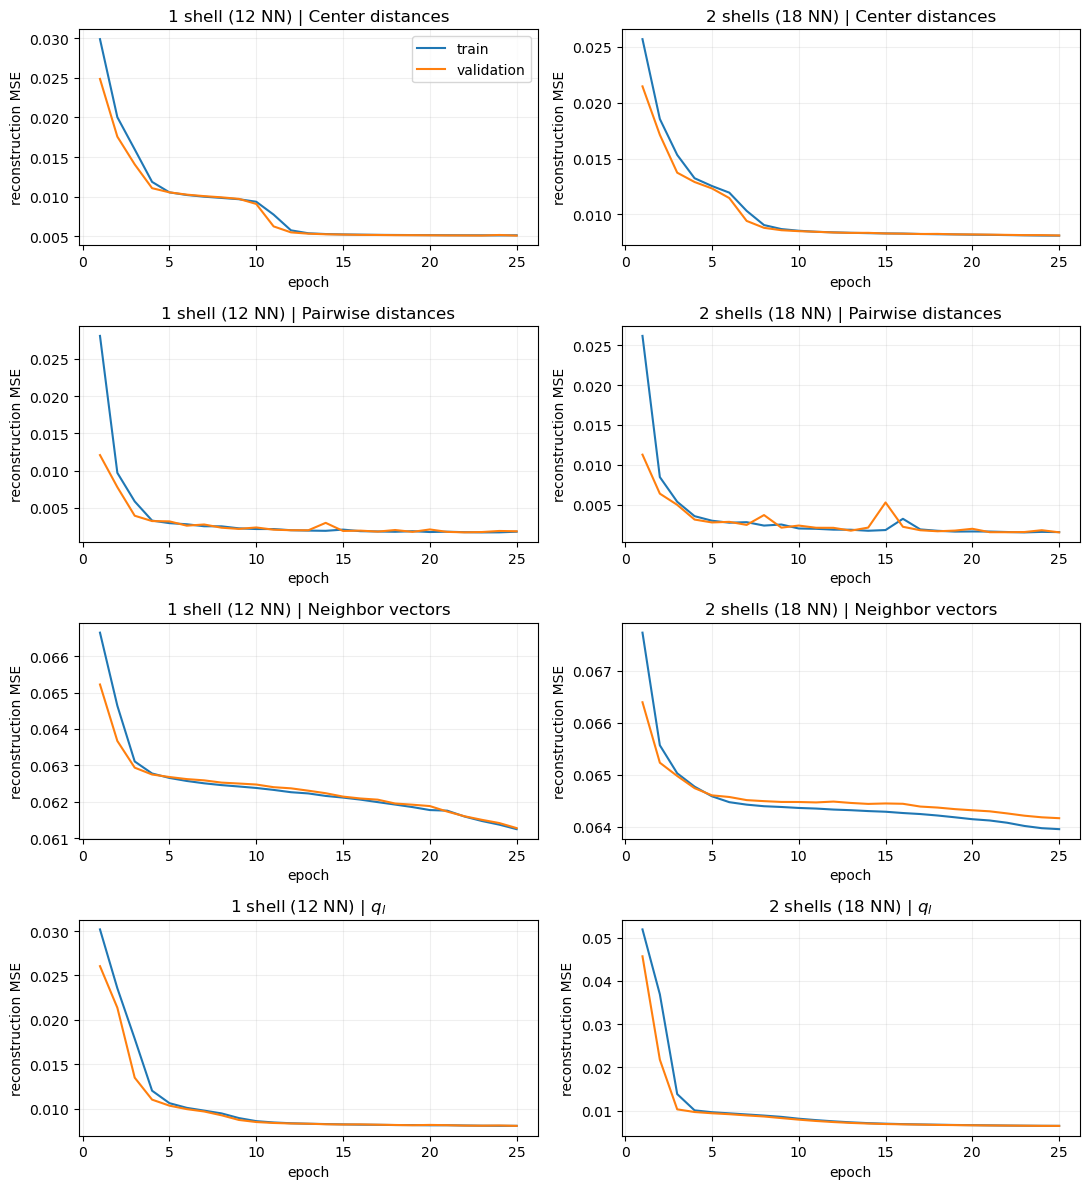

In [64]:
def plot_training_curves(artifacts):
    fig, axes = plt.subplots(
        len(FEATURE_ORDER),
        len(SHELL_ORDER),
        figsize=(11, 12),
        squeeze=False,
    )
    for row, feature_kind in enumerate(FEATURE_ORDER):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            history = artifacts[(shell_name, feature_kind)]["history"]
            epochs = np.arange(1, len(history["train_mse"]) + 1)
            ax.plot(epochs, history["train_mse"], label="train")
            ax.plot(epochs, history["val_mse"], label="validation")
            ax.set_title(
                f"{SHELL_CONFIG[shell_name]['label']} | "
                f"{FEATURE_LABELS[feature_kind]}"
            )
            ax.set_xlabel("epoch")
            ax.set_ylabel("reconstruction MSE")
            ax.grid(alpha=0.2)
    axes[0, 0].legend()
    plt.tight_layout()
    plt.show()


plot_training_curves(main_artifacts)

### Robustness across 30 random seeds

The complete sampling → grouped split → training → encoding → probing pipeline is repeated 30 times. The visual seed is reused from the main run rather than trained twice. No plots are generated inside the repeat loop.

In [65]:
score_frames = [main_scores]
for seed in ROBUSTNESS_SEEDS:
    if seed == VISUAL_SEED:
        continue
    print(f"Robustness run for seed {seed}")
    seeded_scores, _, _ = run_suite(
        seed,
        keep_artifacts=False,
        verbose=False,
    )
    score_frames.append(seeded_scores)

robustness_scores = pd.concat(score_frames, ignore_index=True)
metric_names = ("accuracy", "balanced_accuracy", "macro_f1", "roc_auc")
robustness_summary = (
    robustness_scores
    .groupby(["feature_label", "shell_label"], sort=False)[list(metric_names)]
    .agg(["mean", "std", "min", "max"])
)
display(robustness_summary.round(4))

Robustness run for seed 0
Robustness run for seed 1
Robustness run for seed 2
Robustness run for seed 3
Robustness run for seed 4
Robustness run for seed 5
Robustness run for seed 6
Robustness run for seed 7
Robustness run for seed 8
Robustness run for seed 9
Robustness run for seed 10
Robustness run for seed 11
Robustness run for seed 12
Robustness run for seed 13
Robustness run for seed 14
Robustness run for seed 15
Robustness run for seed 16
Robustness run for seed 17
Robustness run for seed 18
Robustness run for seed 19
Robustness run for seed 20
Robustness run for seed 21
Robustness run for seed 22
Robustness run for seed 23
Robustness run for seed 24
Robustness run for seed 25
Robustness run for seed 26
Robustness run for seed 27
Robustness run for seed 28


accuracy                          \
                                        mean     std     min     max   
feature_label      shell_label                                         
Center distances   1 shell (12 NN)    0.8853  0.0046  0.8710  0.8936   
Pairwise distances 1 shell (12 NN)    0.9155  0.0371  0.7800  0.9387   
Neighbor vectors   1 shell (12 NN)    0.5036  0.0078  0.4844  0.5178   
$q_l$              1 shell (12 NN)    0.9464  0.0050  0.9315  0.9565   
Center distances   2 shells (18 NN)   0.9242  0.0039  0.9169  0.9299   
Pairwise distances 2 shells (18 NN)   0.9816  0.0019  0.9782  0.9871   
Neighbor vectors   2 shells (18 NN)   0.5051  0.0097  0.4860  0.5261   
$q_l$              2 shells (18 NN)   0.9999  0.0001  0.9996  1.0000   

                                    balanced_accuracy                          \
                                                 mean     std     min     max   
feature_label      shell_label                                                  
Center distances   1 shell (12 NN)             0.8853  0.0046  0.8709  0.8935   
Pairwise distances 1 shell (12 NN)             0.9155  0.0370  0.7803  0.9387   
Neighbor vectors   1 shell (12 NN)             0.5036  0.0079  0.4847  0.5181   
$q_l$              1 shell (12 NN)             0.9464  0.0049  0.9317  0.9564   
Center distances   2 shells (18 NN)            0.9242  0.0039  0.9168  0.9298   
Pairwise distances 2 shells (18 NN)            0.9816  0.0019  0.9782  0.9871   
Neighbor vectors   2 shells (18 NN)            0.5050  0.0096  0.4860  0.5262   
$q_l$              2 shells (18 NN)            0.9999  0.0001  0.9996  1.0000   

                                    macro_f1                         roc_auc  \
                                        mean     std     min     max    mean   
feature_label      shell_label                                                 
Center distances   1 shell (12 NN)    0.8853  0.0046  0.8710  0.8936  0.9535   
Pairwise distances 1 shell (12 NN)    0.9155  0.0371  0.7799  0.9387  0.9652   
Neighbor vectors   1 shell (12 NN)    0.5031  0.0078  0.4840  0.5173  0.5055   
$q_l$              1 shell (12 NN)    0.9463  0.0050  0.9315  0.9565  0.9828   
Center distances   2 shells (18 NN)   0.9242  0.0039  0.9168  0.9299  0.9774   
Pairwise distances 2 shells (18 NN)   0.9815  0.0019  0.9782  0.9871  0.9968   
Neighbor vectors   2 shells (18 NN)   0.5047  0.0096  0.4860  0.5255  0.5053   
$q_l$              2 shells (18 NN)   0.9999  0.0001  0.9996  1.0000  1.0000   

                                                             
                                        std     min     max  
feature_label      shell_label                               
Center distances   1 shell (12 NN)   0.0027  0.9466  0.9586  
Pairwise distances 1 shell (12 NN)   0.0344  0.8312  0.9839  
Neighbor vectors   1 shell (12 NN)   0.0089  0.4767  0.5202  
$q_l$              1 shell (12 NN)   0.0023  0.9778  0.9876  
Center distances   2 shells (18 NN)  0.0013  0.9747  0.9803  
Pairwise distances 2 shells (18 NN)  0.0010  0.9949  0.9984  
Neighbor vectors   2 shells (18 NN)  0.0102  0.4888  0.5304  
$q_l$              2 shells (18 NN)  0.0000  1.0000  1.0000

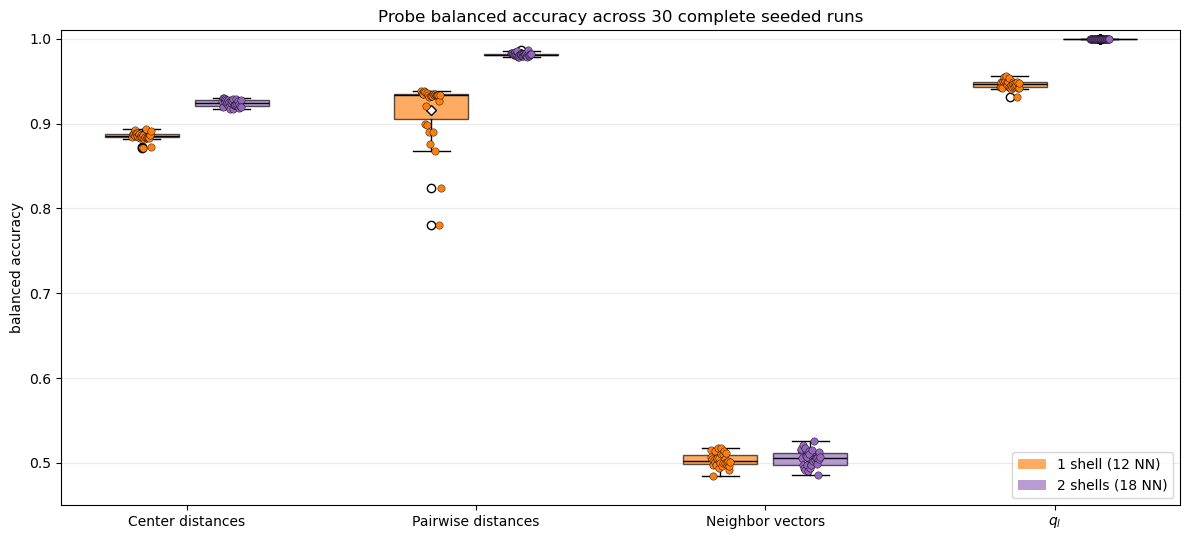

mean                              std  \
shell_label        1 shell (12 NN) 2 shells (18 NN) 1 shell (12 NN)   
feature_label                                                         
$q_l$                       0.9464           0.9999          0.0049   
Center distances            0.8853           0.9242          0.0046   
Neighbor vectors            0.5036           0.5050          0.0079   
Pairwise distances          0.9155           0.9816          0.0370   

                                     
shell_label        2 shells (18 NN)  
feature_label                        
$q_l$                        0.0001  
Center distances             0.0039  
Neighbor vectors             0.0096  
Pairwise distances           0.0019

In [66]:
def plot_robustness_boxplots(scores, metric="balanced_accuracy"):
    fig, ax = plt.subplots(figsize=(12, 5.5))
    shell_colors = {
        "first_shell": "tab:orange",
        "second_shell": "tab:purple",
    }
    offsets = {"first_shell": -0.28, "second_shell": 0.28}
    centers = np.arange(len(FEATURE_ORDER)) * 1.8
    width = 0.46

    for shell_name in SHELL_ORDER:
        values = [
            scores.loc[
                (scores["feature"] == feature_kind)
                & (scores["shell"] == shell_name),
                metric,
            ].to_numpy()
            for feature_kind in FEATURE_ORDER
        ]
        positions = centers + offsets[shell_name]
        boxes = ax.boxplot(
            values,
            positions=positions,
            widths=width,
            patch_artist=True,
            showmeans=True,
            meanprops={
                "marker": "D",
                "markerfacecolor": "white",
                "markeredgecolor": "black",
                "markersize": 5,
            },
            medianprops={"color": "black"},
        )
        for box in boxes["boxes"]:
            box.set_facecolor(shell_colors[shell_name])
            box.set_alpha(0.65)

        # Show every run, not only the box summary.
        for position, feature_values in zip(positions, values):
            jitter = np.linspace(-0.06, 0.06, len(feature_values))
            ax.scatter(
                position + jitter,
                feature_values,
                color=shell_colors[shell_name],
                edgecolor="black",
                linewidth=0.3,
                s=28,
                zorder=3,
            )

    ax.set_xticks(centers)
    ax.set_xticklabels([FEATURE_LABELS[k] for k in FEATURE_ORDER])
    ax.set_ylabel(metric.replace("_", " "))
    ax.set_ylim(0.45, 1.01)
    ax.set_title(
        f"Probe {metric.replace('_', ' ')} across "
        f"{scores['seed'].nunique()} complete seeded runs"
    )
    ax.grid(axis="y", alpha=0.25)
    ax.legend(
        handles=[
            Patch(
                facecolor=shell_colors[shell_name],
                alpha=0.65,
                label=SHELL_CONFIG[shell_name]["label"],
            )
            for shell_name in SHELL_ORDER
        ],
        loc="lower right",
    )
    plt.tight_layout()
    plt.show()


plot_robustness_boxplots(robustness_scores, metric="balanced_accuracy")

mean_std_table = robustness_scores.pivot_table(
    index="feature_label",
    columns="shell_label",
    values="balanced_accuracy",
    aggfunc=["mean", "std"],
)
display(mean_std_table.round(4))

### Liquid–FCC ranking and interpretation

Balanced accuracy is the primary comparison because it gives both phases equal weight. Macro-F1 and ROC-AUC are useful checks. Reconstruction MSE is not a phase-separation metric: a low reconstruction error can coexist with a poorly separable bottleneck.

Expected qualitative behavior:

- Center and pairwise distances have strong rotation/permutation invariance built into the input.
- Raw vectors are translation invariant but not rotation invariant; radial sorting is unstable when neighbor distances are nearly tied. A weak or variable probe score is informative rather than a pipeline failure.
- $q_l$ inputs encode rotational invariance explicitly. Interpret second-shell $q_l$ as a true 18-neighbor comparison only when `q_l_exact_requested_NN` is true in the data table.
- Seed distributions combine variation from sampling, frame splits, mini-batch ordering, and initialization. They are not uncertainty estimates over independently generated thermodynamic trajectories.

In [67]:
ranking = (
    robustness_scores
    .groupby(["feature_label", "shell_label"], as_index=False)
    .agg(
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std"),
        mean_macro_f1=("macro_f1", "mean"),
        mean_roc_auc=("roc_auc", "mean"),
        runs=("seed", "nunique"),
    )
    .sort_values("mean_balanced_accuracy", ascending=False)
    .reset_index(drop=True)
)
display(ranking.round(4))

,feature_label,shell_label,mean_balanced_accuracy,std_balanced_accuracy,mean_macro_f1,mean_roc_auc,runs
0,$q_l$,2 shells (18 NN),0.9999,0.0001,0.9999,1.0000,30
1,Pairwise distances,2 shells (18 NN),0.9816,0.0019,0.9815,0.9968,30
2,$q_l$,1 shell (12 NN),0.9464,0.0049,0.9463,0.9828,30
3,Center distances,2 shells (18 NN),0.9242,0.0039,0.9242,0.9774,30
4,Pairwise distances,1 shell (12 NN),0.9155,0.0370,0.9155,0.9652,30
5,Center distances,1 shell (12 NN),0.8853,0.0046,0.8853,0.9535,30
6,Neighbor vectors,2 shells (18 NN),0.5050,0.0096,0.5047,0.5053,30
7,Neighbor vectors,1 shell (12 NN),0.5036,0.0079,0.5031,0.5055,30


## Part II — FCC vs HCP: where the simple autoencoder reaches its limit

FCC and HCP have the same 12-fold first coordination shell and differ primarily in stacking beyond it. This makes the comparison substantially harder and makes the first-versus-second-shell contrast physically meaningful.

The vector input is removed. In its place, **triplets** are the angles $\theta_{jik}$ formed by the central particle $i$ and every unordered pair of neighbors $(j,k)$. The sorted angle signature contains $\binom{12}{2}=66$ values for the first shell and $\binom{18}{2}=153$ for the second. It is invariant to global translation, rotation, and neighbor permutation. Sorting intentionally discards which radial pair produced each angle, so this remains a compact baseline rather than a full three-body correlation representation.

In [68]:
FCC_HCP_PHASES = ("fcc", "hcp")
FCC_HCP_LABEL_MAP = {"fcc": 0, "hcp": 1}
FCC_HCP_LABEL_NAMES = {0: "fcc", 1: "hcp"}
FCC_HCP_LABEL_COLORS = {0: "tab:blue", 1: "tab:orange"}
FCC_HCP_FEATURE_ORDER = ("radii", "pairwise_distances", "triplets", "ql")
FCC_HCP_FEATURE_LABELS = {
    "radii": "Center distances",
    "pairwise_distances": "Pairwise distances",
    "triplets": "Central triplet angles",
    "ql": r"$q_l$",
}

fcc_hcp_shell_data = {shell_name: {} for shell_name in SHELL_ORDER}
fcc_hcp_summary_rows = []

for shell_name, shell_cfg in SHELL_CONFIG.items():
    # Reuse the already loaded FCC arrays and load HCP with the same conventions.
    fcc_hcp_shell_data[shell_name]["fcc"] = shell_data[shell_name]["fcc"]
    hcp_path = _resolve_shell_file("hcp", shell_name)
    hcp_data = load_particle_data(hcp_path, shell_cfg["ql_key"])
    expected_nn = shell_cfg["n_neighbors"]
    if hcp_data["dist"].shape[1] != expected_nn or hcp_data["vec_dist"].shape[1] != expected_nn:
        raise ValueError(
            f"{hcp_path}: expected {expected_nn} geometric neighbors, "
            f"got dist={hcp_data['dist'].shape[1]} and vec={hcp_data['vec_dist'].shape[1]}"
        )
    hcp_data["ql_exact"] = hcp_data["descriptor_nn"] == expected_nn
    if not hcp_data["ql_exact"]:
        warnings.warn(
            f"{hcp_path.name} (hcp): q_l used {hcp_data['descriptor_nn']} neighbors, "
            f"not the requested {expected_nn}.",
            stacklevel=2,
        )
    fcc_hcp_shell_data[shell_name]["hcp"] = hcp_data

    for phase in FCC_HCP_PHASES:
        data = fcc_hcp_shell_data[shell_name][phase]
        fcc_hcp_summary_rows.append(
            {
                "shell": shell_cfg["label"],
                "phase": phase,
                "file": data["source"].name,
                "samples": len(data["dist"]),
                "geometric_NN": data["dist"].shape[1],
                "q_l_variant": shell_cfg["ql_variant"],
                "q_l_descriptor_NN": data["descriptor_nn"],
                "q_l_exact_requested_NN": data["ql_exact"],
            }
        )

first_hcp = fcc_hcp_shell_data["first_shell"]["hcp"]
second_hcp = fcc_hcp_shell_data["second_shell"]["hcp"]
if not np.array_equal(first_hcp["picked_ids"], second_hcp["picked_ids"]):
    raise ValueError("Picked HCP particle IDs differ between shells.")
if not np.array_equal(first_hcp["frame_indices"], second_hcp["frame_indices"]):
    raise ValueError("HCP frame indices differ between shells.")

display(pd.DataFrame(fcc_hcp_summary_rows))

/home/jakob/miniconda3/envs/autoencode-statmech/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3579: UserWarning: particle_data_second_shell.npz (hcp): q_l used 12 neighbors, not the requested 18.
  exec(code_obj, self.user_global_ns, self.user_ns)


,shell,phase,file,samples,geometric_NN,q_l_variant,q_l_descriptor_NN,q_l_exact_requested_NN
0,1 shell (12 NN),fcc,particle_data.npz,180300,12,standard,12,True
1,1 shell (12 NN),hcp,particle_data.npz,180300,12,standard,12,True
2,2 shells (18 NN),fcc,particle_data_second_shell.npz,180300,18,Lechner-Dellago averaged,12,False
3,2 shells (18 NN),hcp,particle_data_second_shell.npz,180300,18,Lechner-Dellago averaged,12,False


In [69]:
def triplet_angle_features(vectors, chunk_size=PAIRWISE_CHUNK_SIZE):
    """Sorted central bond angles for all unordered neighbor pairs."""
    n_samples, n_neighbors, _ = vectors.shape
    pair_i, pair_j = np.triu_indices(n_neighbors, k=1)
    output = np.empty((n_samples, len(pair_i)), dtype=np.float32)

    for start in range(0, n_samples, chunk_size):
        stop = min(start + chunk_size, n_samples)
        chunk = vectors[start:stop]
        norms = np.linalg.norm(chunk, axis=2, keepdims=True)
        unit = chunk / np.maximum(norms, 1e-12)
        cosine = np.einsum(
            "bpc,bpc->bp",
            unit[:, pair_i, :],
            unit[:, pair_j, :],
        )
        output[start:stop] = np.arccos(np.clip(cosine, -1.0, 1.0))

    output.sort(axis=1)
    return output


def build_fcc_hcp_feature(data, feature_kind, indices):
    if feature_kind == "triplets":
        return triplet_angle_features(data["vec_dist"][indices])
    return build_feature(data, feature_kind, indices)


def build_fcc_hcp_sampling_plan(seed):
    rng = np.random.default_rng(seed)
    reference = fcc_hcp_shell_data["first_shell"]
    n_per_phase = min(
        MAX_SAMPLES_PER_PHASE,
        *(len(reference[phase]["dist"]) for phase in FCC_HCP_PHASES),
    )
    plan = {}
    for phase in FCC_HCP_PHASES:
        data = reference[phase]
        indices = np.sort(rng.choice(len(data["dist"]), size=n_per_phase, replace=False))
        split = _frame_split(data["frame_indices"][indices], rng)
        plan[phase] = {"indices": indices, "split": split}
    return plan


def prepare_fcc_hcp_experiment(shell_name, feature_kind, plan):
    X_parts, y_parts, split_parts = [], [], []
    for phase in FCC_HCP_PHASES:
        entry = plan[phase]
        X_parts.append(
            build_fcc_hcp_feature(
                fcc_hcp_shell_data[shell_name][phase],
                feature_kind,
                entry["indices"],
            )
        )
        y_parts.append(
            np.full(len(entry["indices"]), FCC_HCP_LABEL_MAP[phase], dtype=np.int64)
        )
        split_parts.append(entry["split"])
    return (
        np.concatenate(X_parts).astype(np.float32, copy=False),
        np.concatenate(y_parts),
        np.concatenate(split_parts),
    )


fcc_hcp_example_plan = build_fcc_hcp_sampling_plan(VISUAL_SEED)
fcc_hcp_plan_rows = []
for phase in FCC_HCP_PHASES:
    entry = fcc_hcp_example_plan[phase]
    frames = fcc_hcp_shell_data["first_shell"][phase]["frame_indices"][entry["indices"]]
    for partition in ("train", "val", "test"):
        mask = entry["split"] == partition
        fcc_hcp_plan_rows.append(
            {
                "phase": phase,
                "partition": partition,
                "particles": int(mask.sum()),
                "frames": int(np.unique(frames[mask]).size),
            }
        )
display(pd.DataFrame(fcc_hcp_plan_rows))

,phase,partition,particles,frames
0,fcc,train,7276,361
1,fcc,val,2416,120
2,fcc,test,2308,120
3,hcp,train,7090,361
4,hcp,val,2489,120
5,hcp,test,2421,120


In [70]:
def run_fcc_hcp_suite(seed, keep_artifacts=True, verbose=True):
    plan = build_fcc_hcp_sampling_plan(seed)
    rows = []
    artifacts = {}

    for shell_name in SHELL_ORDER:
        shell_cfg = SHELL_CONFIG[shell_name]
        ql_exact = all(
            fcc_hcp_shell_data[shell_name][phase]["ql_exact"]
            for phase in FCC_HCP_PHASES
        )
        for feature_kind in FCC_HCP_FEATURE_ORDER:
            if verbose:
                print(
                    f"seed={seed:>3} | {shell_cfg['label']:<18} | "
                    f"{FCC_HCP_FEATURE_LABELS[feature_kind]}"
                )
            X, y, split = prepare_fcc_hcp_experiment(shell_name, feature_kind, plan)
            ae = train_autoencoder(X, split, seed)
            probe = probe_latent(ae["Z"], y, split, seed)

            rows.append(
                {
                    "seed": seed,
                    "shell": shell_name,
                    "shell_label": shell_cfg["label"],
                    "n_neighbors": shell_cfg["n_neighbors"],
                    "feature": feature_kind,
                    "feature_label": FCC_HCP_FEATURE_LABELS[feature_kind],
                    "input_dim": X.shape[1],
                    "n_samples": len(X),
                    "best_epoch": ae["best_epoch"],
                    "validation_mse": ae["best_val_mse"],
                    "accuracy": probe["accuracy"],
                    "balanced_accuracy": probe["balanced_accuracy"],
                    "macro_f1": probe["macro_f1"],
                    "roc_auc": probe["roc_auc"],
                    "q_l_exact_requested_NN": ql_exact if feature_kind == "ql" else pd.NA,
                }
            )
            if keep_artifacts:
                artifacts[(shell_name, feature_kind)] = {
                    "Z": ae["Z"],
                    "y": y,
                    "split": split,
                    "history": ae["history"],
                    "model": ae["model"],
                    "scaler": ae["scaler"],
                    "probe": probe,
                }

            del X, ae
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return pd.DataFrame(rows), artifacts, plan

### FCC vs HCP main run

In [71]:
fcc_hcp_main_scores, fcc_hcp_main_artifacts, fcc_hcp_main_plan = run_fcc_hcp_suite(
    VISUAL_SEED,
    keep_artifacts=True,
    verbose=True,
)

display(
    fcc_hcp_main_scores[score_columns]
    .sort_values(["feature_label", "shell_label"])
    .reset_index(drop=True)
    .round(4)
)

seed= 42 | 1 shell (12 NN)    | Center distances
seed= 42 | 1 shell (12 NN)    | Pairwise distances
seed= 42 | 1 shell (12 NN)    | Central triplet angles
seed= 42 | 1 shell (12 NN)    | $q_l$
seed= 42 | 2 shells (18 NN)   | Center distances
seed= 42 | 2 shells (18 NN)   | Pairwise distances
seed= 42 | 2 shells (18 NN)   | Central triplet angles
seed= 42 | 2 shells (18 NN)   | $q_l$


,shell_label,feature_label,input_dim,best_epoch,validation_mse,accuracy,balanced_accuracy,macro_f1,roc_auc,q_l_exact_requested_NN
0,1 shell (12 NN),$q_l$,20,25,0.0065,0.9695,0.9692,0.9695,0.9802,True
1,2 shells (18 NN),$q_l$,20,25,0.0061,0.9987,0.9987,0.9987,1.0000,False
2,1 shell (12 NN),Center distances,12,25,0.0063,0.5100,0.5095,0.5095,0.5086,<NA>
3,2 shells (18 NN),Center distances,18,25,0.0095,0.5062,0.5055,0.5053,0.5054,<NA>
4,1 shell (12 NN),Central triplet angles,66,25,0.0016,0.6779,0.6794,0.6773,0.7468,<NA>
5,2 shells (18 NN),Central triplet angles,153,25,0.0011,0.8465,0.8447,0.8451,0.8588,<NA>
6,1 shell (12 NN),Pairwise distances,78,23,0.0014,0.5077,0.5077,0.5076,0.5142,<NA>
7,2 shells (18 NN),Pairwise distances,171,24,0.0017,0.8972,0.8971,0.8972,0.9446,<NA>


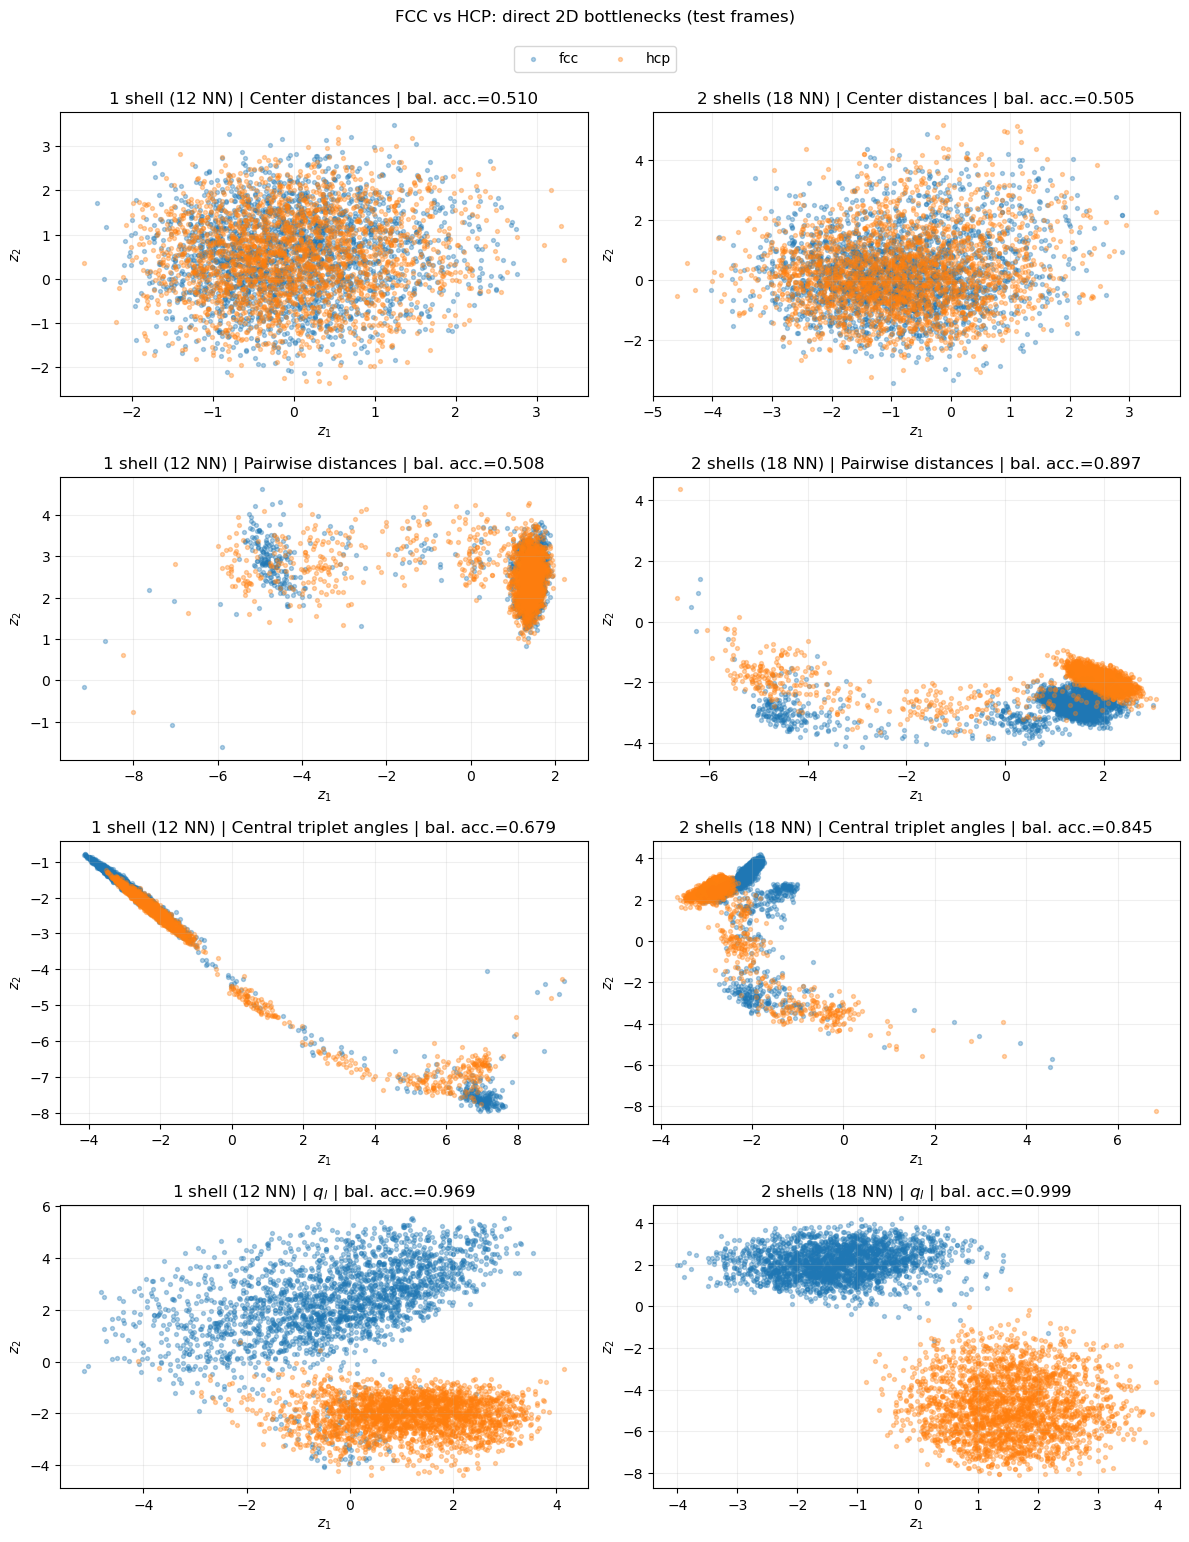

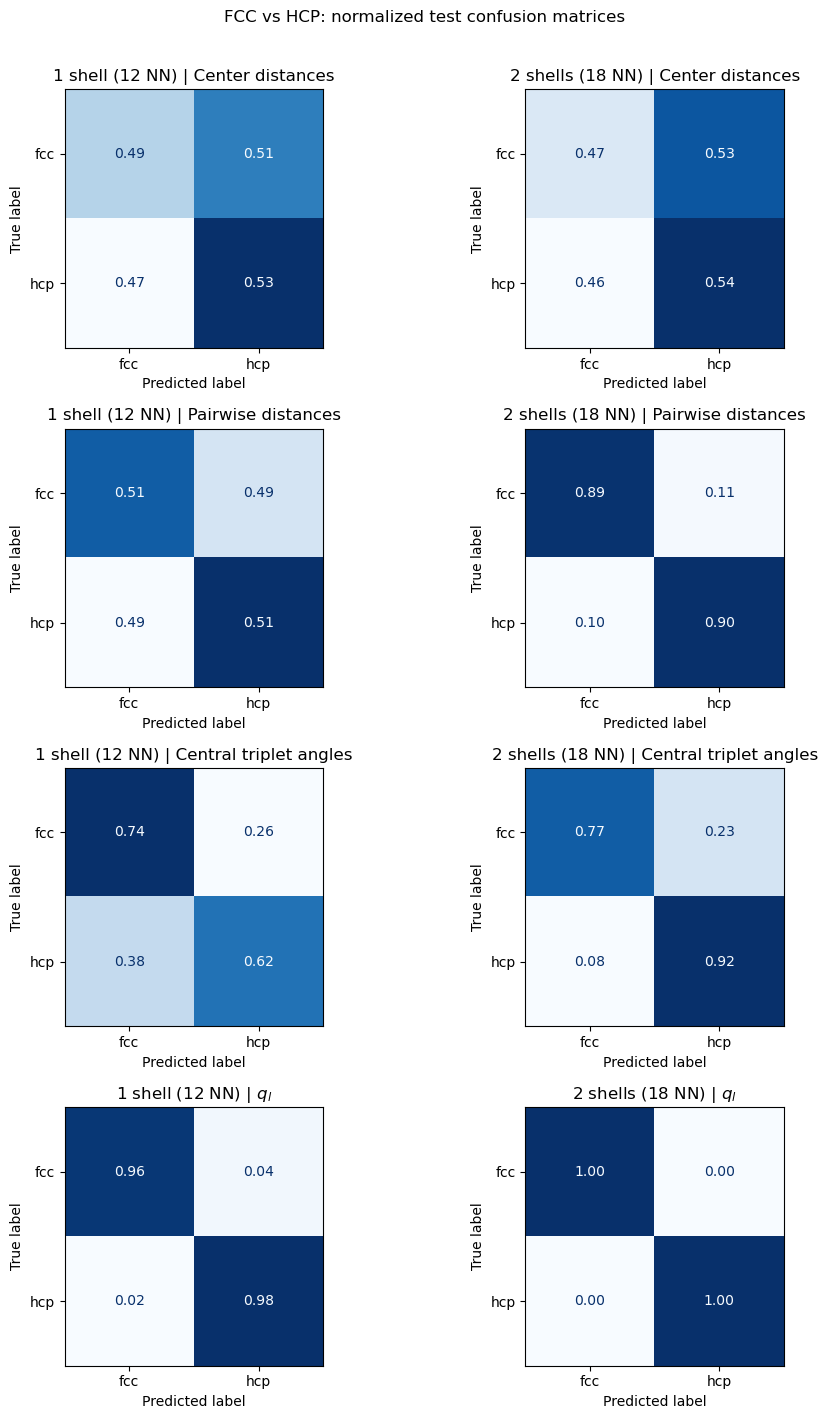

balanced_accuracy                         macro_f1  \
shell_label              1 shell (12 NN) 2 shells (18 NN) 1 shell (12 NN)   
feature_label                                                               
$q_l$                             0.9692           0.9987          0.9695   
Center distances                  0.5095           0.5055          0.5095   
Central triplet angles            0.6794           0.8447          0.6773   
Pairwise distances                0.5077           0.8971          0.5076   

                                                roc_auc                   
shell_label            2 shells (18 NN) 1 shell (12 NN) 2 shells (18 NN)  
feature_label                                                             
$q_l$                            0.9987          0.9802           1.0000  
Center distances                 0.5053          0.5086           0.5054  
Central triplet angles           0.8451          0.7468           0.8588  
Pairwise distances               0.8972          0.5142           0.9446

In [72]:
def plot_binary_latent_grid(
    artifacts,
    feature_order,
    feature_labels,
    phases,
    label_map,
    label_colors,
    comparison_title,
    split_to_plot="test",
):
    fig, axes = plt.subplots(
        len(feature_order),
        len(SHELL_ORDER),
        figsize=(12, 15),
        squeeze=False,
    )
    rng = np.random.default_rng(VISUAL_SEED)

    for row, feature_kind in enumerate(feature_order):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            artifact = artifacts[(shell_name, feature_kind)]
            Z, y, split = artifact["Z"], artifact["y"], artifact["split"]
            keep = split == split_to_plot
            for phase in phases:
                label = label_map[phase]
                indices = np.flatnonzero(keep & (y == label))
                if len(indices) > MAX_PLOT_POINTS_PER_PHASE:
                    indices = rng.choice(indices, MAX_PLOT_POINTS_PER_PHASE, replace=False)
                ax.scatter(
                    Z[indices, 0],
                    Z[indices, 1],
                    s=8,
                    alpha=0.35,
                    color=label_colors[label],
                    label=phase,
                    rasterized=True,
                )
            score = artifact["probe"]["balanced_accuracy"]
            ax.set_title(
                f"{SHELL_CONFIG[shell_name]['label']} | "
                f"{feature_labels[feature_kind]} | bal. acc.={score:.3f}"
            )
            ax.set_xlabel(r"$z_1$")
            ax.set_ylabel(r"$z_2$")
            ax.grid(alpha=0.2)

    handles, legend_labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, legend_labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.005))
    fig.suptitle(f"{comparison_title}: direct 2D bottlenecks ({split_to_plot} frames)", y=1.025)
    plt.tight_layout()
    plt.show()


def plot_binary_confusion_grid(
    artifacts,
    feature_order,
    feature_labels,
    phases,
    label_map,
    label_names,
    comparison_title,
):
    fig, axes = plt.subplots(
        len(feature_order),
        len(SHELL_ORDER),
        figsize=(10, 14),
        squeeze=False,
    )
    labels = [label_map[phase] for phase in phases]
    names = [label_names[label] for label in labels]
    for row, feature_kind in enumerate(feature_order):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            probe = artifacts[(shell_name, feature_kind)]["probe"]
            matrix = confusion_matrix(
                probe["y_test"],
                probe["y_pred"],
                labels=labels,
                normalize="true",
            )
            ConfusionMatrixDisplay(matrix, display_labels=names).plot(
                ax=ax,
                cmap="Blues",
                colorbar=False,
                values_format=".2f",
            )
            ax.set_title(
                f"{SHELL_CONFIG[shell_name]['label']} | {feature_labels[feature_kind]}"
            )
            ax.grid(False)
    fig.suptitle(f"{comparison_title}: normalized test confusion matrices", y=1.01)
    plt.tight_layout()
    plt.show()


plot_binary_latent_grid(
    fcc_hcp_main_artifacts,
    FCC_HCP_FEATURE_ORDER,
    FCC_HCP_FEATURE_LABELS,
    FCC_HCP_PHASES,
    FCC_HCP_LABEL_MAP,
    FCC_HCP_LABEL_COLORS,
    "FCC vs HCP",
)
plot_binary_confusion_grid(
    fcc_hcp_main_artifacts,
    FCC_HCP_FEATURE_ORDER,
    FCC_HCP_FEATURE_LABELS,
    FCC_HCP_PHASES,
    FCC_HCP_LABEL_MAP,
    FCC_HCP_LABEL_NAMES,
    "FCC vs HCP",
)

fcc_hcp_metric_table = fcc_hcp_main_scores.pivot(
    index="feature_label",
    columns="shell_label",
    values=["balanced_accuracy", "macro_f1", "roc_auc"],
)
display(fcc_hcp_metric_table.round(4))

### FCC vs HCP robustness across 30 random seeds

As above, the visual seed is one of the 30 complete runs and is reused. Each other seed resamples particles, constructs new frame-grouped partitions, initializes a new autoencoder, and refits the probe. No per-seed plots are created.

In [73]:
fcc_hcp_score_frames = [fcc_hcp_main_scores]
for seed in ROBUSTNESS_SEEDS:
    if seed == VISUAL_SEED:
        continue
    print(f"FCC–HCP robustness run for seed {seed}")
    seeded_scores, _, _ = run_fcc_hcp_suite(
        seed,
        keep_artifacts=False,
        verbose=False,
    )
    fcc_hcp_score_frames.append(seeded_scores)

fcc_hcp_robustness_scores = pd.concat(fcc_hcp_score_frames, ignore_index=True)
fcc_hcp_robustness_summary = (
    fcc_hcp_robustness_scores
    .groupby(["feature_label", "shell_label"], sort=False)[list(metric_names)]
    .agg(["mean", "std", "min", "max"])
)
display(fcc_hcp_robustness_summary.round(4))

FCC–HCP robustness run for seed 0
FCC–HCP robustness run for seed 1
FCC–HCP robustness run for seed 2
FCC–HCP robustness run for seed 3
FCC–HCP robustness run for seed 4
FCC–HCP robustness run for seed 5
FCC–HCP robustness run for seed 6
FCC–HCP robustness run for seed 7
FCC–HCP robustness run for seed 8
FCC–HCP robustness run for seed 9
FCC–HCP robustness run for seed 10
FCC–HCP robustness run for seed 11
FCC–HCP robustness run for seed 12
FCC–HCP robustness run for seed 13
FCC–HCP robustness run for seed 14
FCC–HCP robustness run for seed 15
FCC–HCP robustness run for seed 16
FCC–HCP robustness run for seed 17
FCC–HCP robustness run for seed 18
FCC–HCP robustness run for seed 19
FCC–HCP robustness run for seed 20
FCC–HCP robustness run for seed 21
FCC–HCP robustness run for seed 22
FCC–HCP robustness run for seed 23
FCC–HCP robustness run for seed 24
FCC–HCP robustness run for seed 25
FCC–HCP robustness run for seed 26
FCC–HCP robustness run for seed 27
FCC–HCP robustness run for see

accuracy                          \
                                            mean     std     min     max   
feature_label          shell_label                                         
Center distances       1 shell (12 NN)    0.5005  0.0078  0.4835  0.5186   
Pairwise distances     1 shell (12 NN)    0.5056  0.0081  0.4924  0.5231   
Central triplet angles 1 shell (12 NN)    0.8429  0.0518  0.6779  0.9057   
$q_l$                  1 shell (12 NN)    0.9605  0.0047  0.9486  0.9695   
Center distances       2 shells (18 NN)   0.5084  0.0071  0.4952  0.5267   
Pairwise distances     2 shells (18 NN)   0.8740  0.0437  0.7765  0.9550   
Central triplet angles 2 shells (18 NN)   0.8374  0.0113  0.8122  0.8742   
$q_l$                  2 shells (18 NN)   0.9981  0.0009  0.9956  1.0000   

                                        balanced_accuracy                  \
                                                     mean     std     min   
feature_label          shell_label                                          
Center distances       1 shell (12 NN)             0.5005  0.0078  0.4835   
Pairwise distances     1 shell (12 NN)             0.5058  0.0081  0.4924   
Central triplet angles 1 shell (12 NN)             0.8428  0.0517  0.6794   
$q_l$                  1 shell (12 NN)             0.9605  0.0047  0.9486   
Center distances       2 shells (18 NN)            0.5084  0.0072  0.4952   
Pairwise distances     2 shells (18 NN)            0.8740  0.0437  0.7764   
Central triplet angles 2 shells (18 NN)            0.8374  0.0112  0.8135   
$q_l$                  2 shells (18 NN)            0.9981  0.0009  0.9956   

                                                macro_f1                  \
                                            max     mean     std     min   
feature_label          shell_label                                         
Center distances       1 shell (12 NN)   0.5185   0.5003  0.0079  0.4830   
Pairwise distances     1 shell (12 NN)   0.5230   0.5021  0.0111  0.4760   
Central triplet angles 1 shell (12 NN)   0.9057   0.8422  0.0527  0.6773   
$q_l$                  1 shell (12 NN)   0.9692   0.9605  0.0047  0.9486   
Center distances       2 shells (18 NN)  0.5270   0.5079  0.0071  0.4952   
Pairwise distances     2 shells (18 NN)  0.9551   0.8740  0.0437  0.7764   
Central triplet angles 2 shells (18 NN)  0.8748   0.8366  0.0114  0.8115   
$q_l$                  2 shells (18 NN)  1.0000   0.9981  0.0009  0.9956   

                                                roc_auc                  \
                                            max    mean     std     min   
feature_label          shell_label                                        
Center distances       1 shell (12 NN)   0.5184  0.4989  0.0096  0.4824   
Pairwise distances     1 shell (12 NN)   0.5230  0.5109  0.0128  0.4890   
Central triplet angles 1 shell (12 NN)   0.9057  0.8846  0.0530  0.7468   
$q_l$                  1 shell (12 NN)   0.9695  0.9768  0.0080  0.9612   
Center distances       2 shells (18 NN)  0.5267  0.5106  0.0082  0.4953   
Pairwise distances     2 shells (18 NN)  0.9550  0.9259  0.0347  0.8415   
Central triplet angles 2 shells (18 NN)  0.8740  0.8557  0.0188  0.8191   
$q_l$                  2 shells (18 NN)  1.0000  0.9999  0.0001  0.9997   

                                                 
                                            max  
feature_label          shell_label               
Center distances       1 shell (12 NN)   0.5232  
Pairwise distances     1 shell (12 NN)   0.5394  
Central triplet angles 1 shell (12 NN)   0.9430  
$q_l$                  1 shell (12 NN)   0.9921  
Center distances       2 shells (18 NN)  0.5280  
Pairwise distances     2 shells (18 NN)  0.9873  
Central triplet angles 2 shells (18 NN)  0.9221  
$q_l$                  2 shells (18 NN)  1.0000

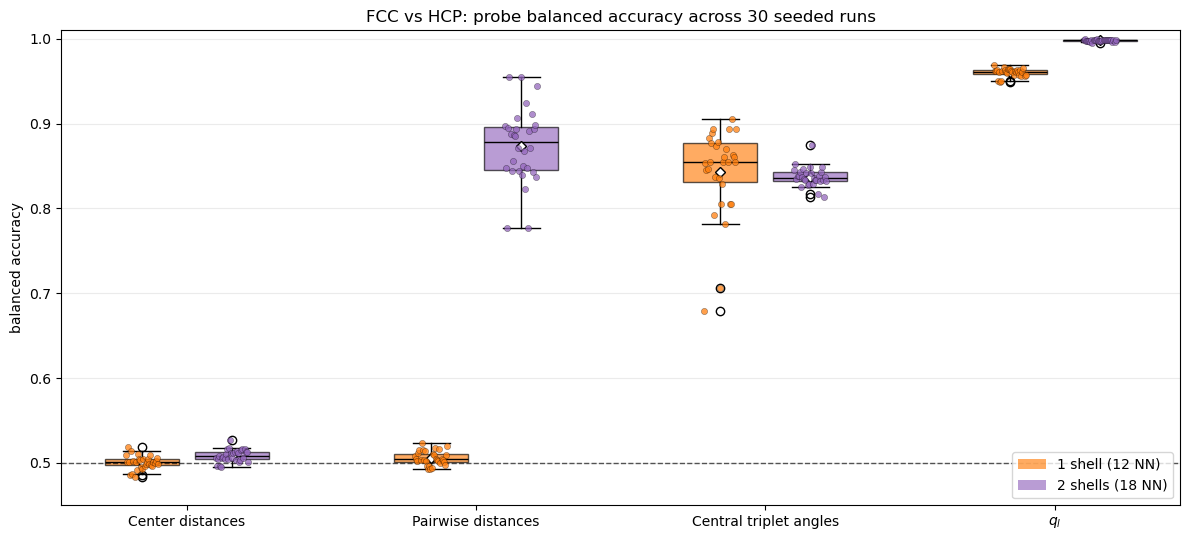

,feature_label,shell_label,mean_balanced_accuracy,std_balanced_accuracy,mean_macro_f1,mean_roc_auc,runs
0,$q_l$,2 shells (18 NN),0.9981,0.0009,0.9981,0.9999,30
1,$q_l$,1 shell (12 NN),0.9605,0.0047,0.9605,0.9768,30
2,Pairwise distances,2 shells (18 NN),0.8740,0.0437,0.8740,0.9259,30
3,Central triplet angles,1 shell (12 NN),0.8428,0.0517,0.8422,0.8846,30
4,Central triplet angles,2 shells (18 NN),0.8374,0.0112,0.8366,0.8557,30
5,Center distances,2 shells (18 NN),0.5084,0.0072,0.5079,0.5106,30
6,Pairwise distances,1 shell (12 NN),0.5058,0.0081,0.5021,0.5109,30
7,Center distances,1 shell (12 NN),0.5005,0.0078,0.5003,0.4989,30


In [74]:
def plot_seed_boxplots(
    scores,
    feature_order,
    feature_labels,
    comparison_title,
    metric="balanced_accuracy",
    chance_level=0.5,
):
    fig, ax = plt.subplots(figsize=(12, 5.5))
    shell_colors = {"first_shell": "tab:orange", "second_shell": "tab:purple"}
    offsets = {"first_shell": -0.28, "second_shell": 0.28}
    centers = np.arange(len(feature_order)) * 1.8

    for shell_name in SHELL_ORDER:
        values = [
            scores.loc[
                (scores["feature"] == feature_kind) & (scores["shell"] == shell_name),
                metric,
            ].to_numpy()
            for feature_kind in feature_order
        ]
        positions = centers + offsets[shell_name]
        boxes = ax.boxplot(
            values,
            positions=positions,
            widths=0.46,
            patch_artist=True,
            showmeans=True,
            meanprops={
                "marker": "D",
                "markerfacecolor": "white",
                "markeredgecolor": "black",
                "markersize": 5,
            },
            medianprops={"color": "black"},
        )
        for box in boxes["boxes"]:
            box.set_facecolor(shell_colors[shell_name])
            box.set_alpha(0.65)
        for position, feature_values in zip(positions, values):
            jitter = np.linspace(-0.10, 0.10, len(feature_values))
            ax.scatter(
                position + jitter,
                feature_values,
                color=shell_colors[shell_name],
                edgecolor="black",
                linewidth=0.25,
                s=20,
                alpha=0.75,
                zorder=3,
            )

    ax.set_xticks(centers)
    ax.set_xticklabels([feature_labels[k] for k in feature_order])
    ax.set_ylabel(metric.replace("_", " "))
    ax.axhline(chance_level, color="black", linestyle="--", linewidth=1, alpha=0.65, label="chance")
    ax.set_ylim(max(0.0, chance_level - 0.05), 1.01)
    ax.set_title(
        f"{comparison_title}: probe {metric.replace('_', ' ')} across "
        f"{scores['seed'].nunique()} seeded runs"
    )
    ax.grid(axis="y", alpha=0.25)
    ax.legend(
        handles=[
            Patch(
                facecolor=shell_colors[shell_name],
                alpha=0.65,
                label=SHELL_CONFIG[shell_name]["label"],
            )
            for shell_name in SHELL_ORDER
        ],
        loc="lower right",
    )
    plt.tight_layout()
    plt.show()


plot_seed_boxplots(
    fcc_hcp_robustness_scores,
    FCC_HCP_FEATURE_ORDER,
    FCC_HCP_FEATURE_LABELS,
    "FCC vs HCP",
)

fcc_hcp_ranking = (
    fcc_hcp_robustness_scores
    .groupby(["feature_label", "shell_label"], as_index=False)
    .agg(
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std"),
        mean_macro_f1=("macro_f1", "mean"),
        mean_roc_auc=("roc_auc", "mean"),
        runs=("seed", "nunique"),
    )
    .sort_values("mean_balanced_accuracy", ascending=False)
    .reset_index(drop=True)
)
display(fcc_hcp_ranking.round(4))

### Reading the FCC–HCP result

The key evidence for the simple autoencoder's limit is the **distribution**, not one favorable initialization. Compare each box with the chance level of 0.5 and compare first-shell with second-shell scores feature by feature.

- First-shell FCC and HCP environments should be intrinsically difficult because their nearest-neighbor coordination is the same.
- Second-shell inputs can expose stacking information, but a two-dimensional reconstruction bottleneck is not explicitly encouraged to retain the subtle directions useful for classification.
- Triplet angles provide three-body information with the right geometric invariances. Whether an ordinary dense autoencoder preserves that information is an empirical question answered by its probe distribution.
- $q_l$ is a strong hand-engineered angular prior. Keep the 12-neighbor metadata caveat in mind for the currently stored averaged second-shell values.

## Part III — Liquid vs FCC vs HCP

This repeats the FCC–HCP experiment without changing its feature definitions, architecture, sampling budget, or evaluation protocol; liquid is simply added as a third balanced class. The comparison shows whether an easy-to-separate liquid cluster changes how much of the 2D bottleneck is available for the subtler FCC–HCP distinction.

The primary metrics are macro balanced accuracy, macro-F1, and one-vs-rest macro ROC-AUC. Chance balanced accuracy is $1/3$. The confusion matrices remain important: a good overall score can hide FCC–HCP confusion if liquid is classified almost perfectly.

In [75]:
THREE_PHASES = ("liquid", "fcc", "hcp")
THREE_LABEL_MAP = {"liquid": 0, "fcc": 1, "hcp": 2}
THREE_LABEL_NAMES = {0: "liquid", 1: "fcc", 2: "hcp"}
THREE_LABEL_COLORS = {0: "tab:green", 1: "tab:blue", 2: "tab:orange"}
THREE_FEATURE_ORDER = FCC_HCP_FEATURE_ORDER
THREE_FEATURE_LABELS = FCC_HCP_FEATURE_LABELS

three_phase_shell_data = {
    shell_name: {
        "liquid": shell_data[shell_name]["liquid"],
        "fcc": shell_data[shell_name]["fcc"],
        "hcp": fcc_hcp_shell_data[shell_name]["hcp"],
    }
    for shell_name in SHELL_ORDER
}


def build_three_phase_sampling_plan(
    seed,
    max_samples_per_phase=MAX_SAMPLES_PER_PHASE,
):
    rng = np.random.default_rng(seed)
    reference = three_phase_shell_data["first_shell"]
    n_per_phase = min(
        max_samples_per_phase,
        *(len(reference[phase]["dist"]) for phase in THREE_PHASES),
    )
    plan = {}
    for phase in THREE_PHASES:
        data = reference[phase]
        indices = np.sort(rng.choice(len(data["dist"]), size=n_per_phase, replace=False))
        split = _frame_split(data["frame_indices"][indices], rng)
        plan[phase] = {"indices": indices, "split": split}
    return plan


def prepare_three_phase_experiment(shell_name, feature_kind, plan):
    X_parts, y_parts, split_parts = [], [], []
    for phase in THREE_PHASES:
        entry = plan[phase]
        X_parts.append(
            build_fcc_hcp_feature(
                three_phase_shell_data[shell_name][phase],
                feature_kind,
                entry["indices"],
            )
        )
        y_parts.append(
            np.full(len(entry["indices"]), THREE_LABEL_MAP[phase], dtype=np.int64)
        )
        split_parts.append(entry["split"])
    return (
        np.concatenate(X_parts).astype(np.float32, copy=False),
        np.concatenate(y_parts),
        np.concatenate(split_parts),
    )


def probe_latent_multiclass(Z, y, split, seed):
    fit_mask = split != "test"
    test_mask = split == "test"
    probe = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=5_000,
            class_weight="balanced",
            random_state=seed,
        ),
    )
    probe.fit(Z[fit_mask], y[fit_mask])
    y_test = y[test_mask]
    y_pred = probe.predict(Z[test_mask])
    y_score = probe.predict_proba(Z[test_mask])
    return {
        "probe": probe,
        "y_test": y_test,
        "y_pred": y_pred,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "roc_auc": roc_auc_score(
            y_test,
            y_score,
            labels=probe.classes_,
            multi_class="ovr",
            average="macro",
        ),
    }


three_phase_example_plan = build_three_phase_sampling_plan(VISUAL_SEED)
three_phase_plan_rows = []
for phase in THREE_PHASES:
    entry = three_phase_example_plan[phase]
    frames = three_phase_shell_data["first_shell"][phase]["frame_indices"][entry["indices"]]
    for partition in ("train", "val", "test"):
        mask = entry["split"] == partition
        three_phase_plan_rows.append(
            {
                "phase": phase,
                "partition": partition,
                "particles": int(mask.sum()),
                "frames": int(np.unique(frames[mask]).size),
            }
        )
display(pd.DataFrame(three_phase_plan_rows))

,phase,partition,particles,frames
0,liquid,train,7152,181
1,liquid,val,2409,60
2,liquid,test,2439,60
3,fcc,train,7191,361
4,fcc,val,2367,120
5,fcc,test,2442,120
6,hcp,train,7269,361
7,hcp,val,2353,120
8,hcp,test,2378,120


In [76]:
def run_three_phase_suite(seed, keep_artifacts=True, verbose=True):
    plan = build_three_phase_sampling_plan(seed)
    rows = []
    artifacts = {}

    for shell_name in SHELL_ORDER:
        shell_cfg = SHELL_CONFIG[shell_name]
        ql_exact = all(
            three_phase_shell_data[shell_name][phase]["ql_exact"]
            for phase in THREE_PHASES
        )
        for feature_kind in THREE_FEATURE_ORDER:
            if verbose:
                print(
                    f"seed={seed:>3} | {shell_cfg['label']:<18} | "
                    f"{THREE_FEATURE_LABELS[feature_kind]}"
                )
            X, y, split = prepare_three_phase_experiment(shell_name, feature_kind, plan)
            ae = train_autoencoder(X, split, seed)
            probe = probe_latent_multiclass(ae["Z"], y, split, seed)

            rows.append(
                {
                    "seed": seed,
                    "shell": shell_name,
                    "shell_label": shell_cfg["label"],
                    "n_neighbors": shell_cfg["n_neighbors"],
                    "feature": feature_kind,
                    "feature_label": THREE_FEATURE_LABELS[feature_kind],
                    "input_dim": X.shape[1],
                    "n_samples": len(X),
                    "best_epoch": ae["best_epoch"],
                    "validation_mse": ae["best_val_mse"],
                    "accuracy": probe["accuracy"],
                    "balanced_accuracy": probe["balanced_accuracy"],
                    "macro_f1": probe["macro_f1"],
                    "roc_auc": probe["roc_auc"],
                    "q_l_exact_requested_NN": ql_exact if feature_kind == "ql" else pd.NA,
                }
            )
            if keep_artifacts:
                artifacts[(shell_name, feature_kind)] = {
                    "Z": ae["Z"],
                    "y": y,
                    "split": split,
                    "history": ae["history"],
                    "model": ae["model"],
                    "scaler": ae["scaler"],
                    "probe": probe,
                }

            del X, ae
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return pd.DataFrame(rows), artifacts, plan

### Three-class main run

In [77]:
three_main_scores, three_main_artifacts, three_main_plan = run_three_phase_suite(
    VISUAL_SEED,
    keep_artifacts=True,
    verbose=True,
)

display(
    three_main_scores[score_columns]
    .sort_values(["feature_label", "shell_label"])
    .reset_index(drop=True)
    .round(4)
)

seed= 42 | 1 shell (12 NN)    | Center distances
seed= 42 | 1 shell (12 NN)    | Pairwise distances
seed= 42 | 1 shell (12 NN)    | Central triplet angles
seed= 42 | 1 shell (12 NN)    | $q_l$
seed= 42 | 2 shells (18 NN)   | Center distances
seed= 42 | 2 shells (18 NN)   | Pairwise distances
seed= 42 | 2 shells (18 NN)   | Central triplet angles
seed= 42 | 2 shells (18 NN)   | $q_l$


,shell_label,feature_label,input_dim,best_epoch,validation_mse,accuracy,balanced_accuracy,macro_f1,roc_auc,q_l_exact_requested_NN
0,1 shell (12 NN),$q_l$,20,25,0.0073,0.9074,0.9073,0.9075,0.9736,True
1,2 shells (18 NN),$q_l$,20,25,0.0064,0.9893,0.9892,0.9892,0.9994,False
2,1 shell (12 NN),Center distances,12,25,0.0044,0.5943,0.5926,0.5854,0.8020,<NA>
3,2 shells (18 NN),Center distances,18,25,0.0072,0.6252,0.6243,0.6212,0.8223,<NA>
4,1 shell (12 NN),Central triplet angles,66,25,0.0016,0.7945,0.7940,0.7940,0.8772,<NA>
5,2 shells (18 NN),Central triplet angles,153,24,0.0011,0.7361,0.7352,0.7339,0.8359,<NA>
6,1 shell (12 NN),Pairwise distances,78,23,0.0015,0.6549,0.6532,0.6502,0.8355,<NA>
7,2 shells (18 NN),Pairwise distances,171,24,0.0013,0.9103,0.9104,0.9108,0.9723,<NA>


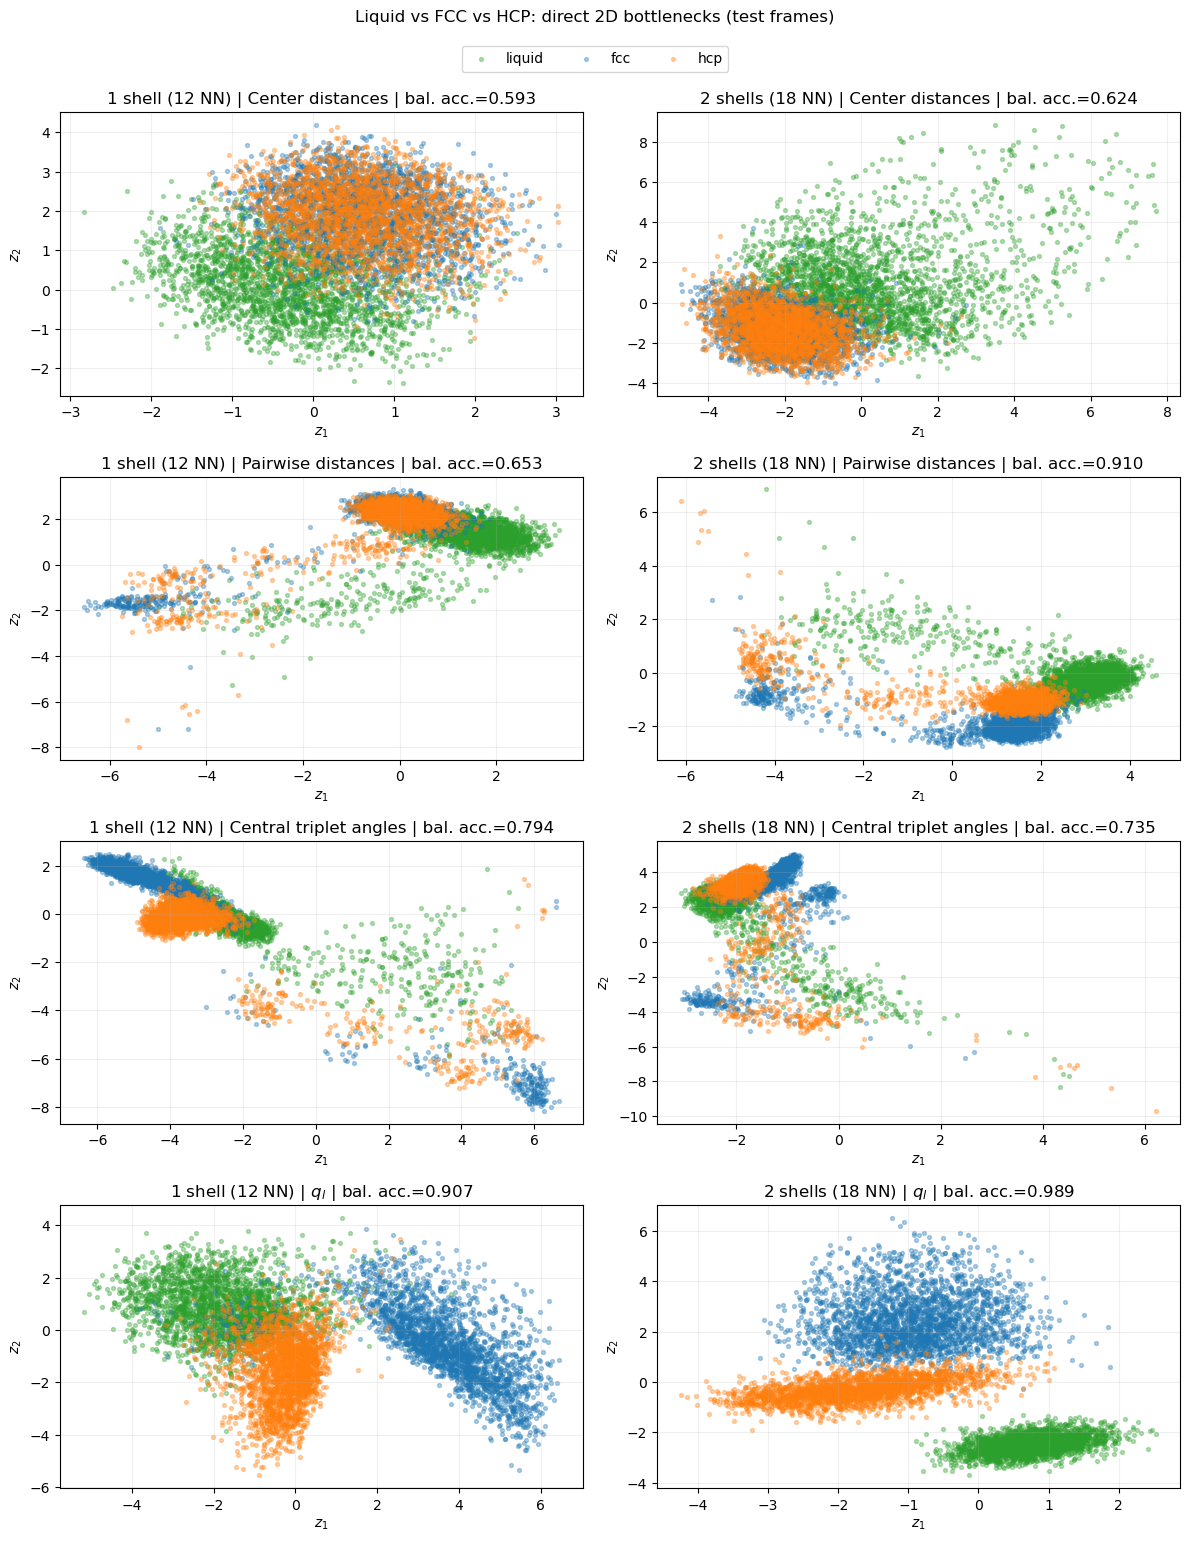

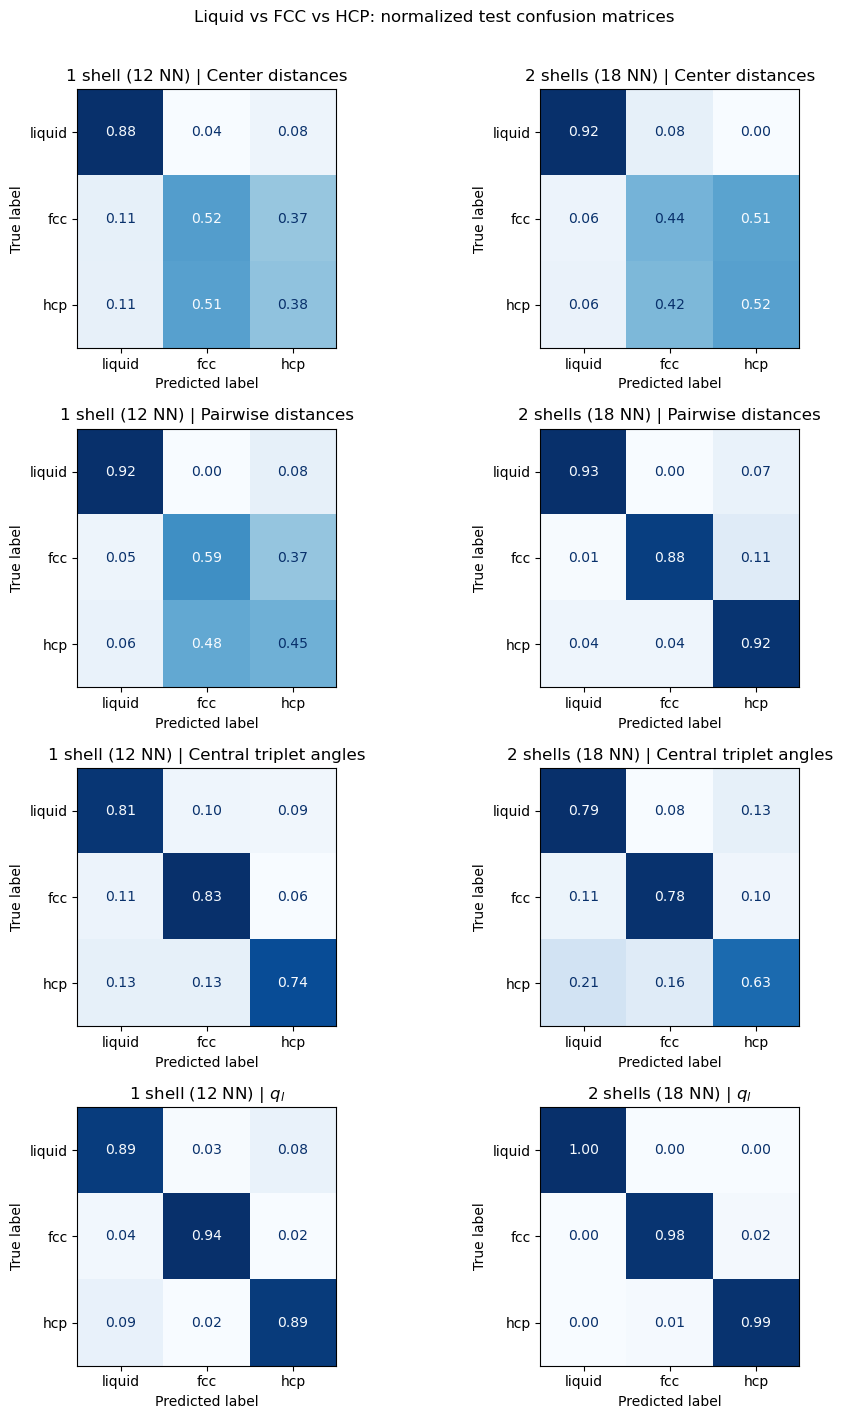

balanced_accuracy                         macro_f1  \
shell_label              1 shell (12 NN) 2 shells (18 NN) 1 shell (12 NN)   
feature_label                                                               
$q_l$                             0.9073           0.9892          0.9075   
Center distances                  0.5926           0.6243          0.5854   
Central triplet angles            0.7940           0.7352          0.7940   
Pairwise distances                0.6532           0.9104          0.6502   

                                                roc_auc                   
shell_label            2 shells (18 NN) 1 shell (12 NN) 2 shells (18 NN)  
feature_label                                                             
$q_l$                            0.9892          0.9736           0.9994  
Center distances                 0.6212          0.8020           0.8223  
Central triplet angles           0.7339          0.8772           0.8359  
Pairwise distances               0.9108          0.8355           0.9723

In [78]:
def plot_multiclass_latent_grid(
    artifacts,
    feature_order,
    feature_labels,
    comparison_title,
    split_to_plot="test",
):
    fig, axes = plt.subplots(
        len(feature_order),
        len(SHELL_ORDER),
        figsize=(12, 15),
        squeeze=False,
    )
    rng = np.random.default_rng(VISUAL_SEED)

    for row, feature_kind in enumerate(feature_order):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            artifact = artifacts[(shell_name, feature_kind)]
            Z, y, split = artifact["Z"], artifact["y"], artifact["split"]
            keep = split == split_to_plot
            for phase in THREE_PHASES:
                label = THREE_LABEL_MAP[phase]
                indices = np.flatnonzero(keep & (y == label))
                if len(indices) > MAX_PLOT_POINTS_PER_PHASE:
                    indices = rng.choice(indices, MAX_PLOT_POINTS_PER_PHASE, replace=False)
                ax.scatter(
                    Z[indices, 0],
                    Z[indices, 1],
                    s=8,
                    alpha=0.35,
                    color=THREE_LABEL_COLORS[label],
                    label=phase,
                    rasterized=True,
                )
            score = artifact["probe"]["balanced_accuracy"]
            ax.set_title(
                f"{SHELL_CONFIG[shell_name]['label']} | "
                f"{feature_labels[feature_kind]} | bal. acc.={score:.3f}"
            )
            ax.set_xlabel(r"$z_1$")
            ax.set_ylabel(r"$z_2$")
            ax.grid(alpha=0.2)

    handles, legend_labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        legend_labels,
        loc="upper center",
        ncol=3,
        bbox_to_anchor=(0.5, 1.005),
    )
    fig.suptitle(
        f"{comparison_title}: direct 2D bottlenecks ({split_to_plot} frames)",
        y=1.025,
    )
    plt.tight_layout()
    plt.show()


def plot_multiclass_confusion_grid(
    artifacts,
    feature_order,
    feature_labels,
    comparison_title,
):
    fig, axes = plt.subplots(
        len(feature_order),
        len(SHELL_ORDER),
        figsize=(10, 14),
        squeeze=False,
    )
    labels = [THREE_LABEL_MAP[phase] for phase in THREE_PHASES]
    names = [THREE_LABEL_NAMES[label] for label in labels]
    for row, feature_kind in enumerate(feature_order):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            probe = artifacts[(shell_name, feature_kind)]["probe"]
            matrix = confusion_matrix(
                probe["y_test"],
                probe["y_pred"],
                labels=labels,
                normalize="true",
            )
            ConfusionMatrixDisplay(matrix, display_labels=names).plot(
                ax=ax,
                cmap="Blues",
                colorbar=False,
                values_format=".2f",
            )
            ax.set_title(
                f"{SHELL_CONFIG[shell_name]['label']} | {feature_labels[feature_kind]}"
            )
            ax.grid(False)
    fig.suptitle(f"{comparison_title}: normalized test confusion matrices", y=1.01)
    plt.tight_layout()
    plt.show()


plot_multiclass_latent_grid(
    three_main_artifacts,
    THREE_FEATURE_ORDER,
    THREE_FEATURE_LABELS,
    "Liquid vs FCC vs HCP",
)
plot_multiclass_confusion_grid(
    three_main_artifacts,
    THREE_FEATURE_ORDER,
    THREE_FEATURE_LABELS,
    "Liquid vs FCC vs HCP",
)

three_metric_table = three_main_scores.pivot(
    index="feature_label",
    columns="shell_label",
    values=["balanced_accuracy", "macro_f1", "roc_auc"],
)
display(three_metric_table.round(4))

### Three-class robustness across 30 random seeds

This is the same full seeded pipeline used in both binary sections. The dashed reference in the boxplot is the three-class chance level, $1/3$.

Three-class robustness run for seed 0
Three-class robustness run for seed 1
Three-class robustness run for seed 2
Three-class robustness run for seed 3
Three-class robustness run for seed 4
Three-class robustness run for seed 5
Three-class robustness run for seed 6
Three-class robustness run for seed 7
Three-class robustness run for seed 8
Three-class robustness run for seed 9
Three-class robustness run for seed 10
Three-class robustness run for seed 11
Three-class robustness run for seed 12
Three-class robustness run for seed 13
Three-class robustness run for seed 14
Three-class robustness run for seed 15
Three-class robustness run for seed 16
Three-class robustness run for seed 17
Three-class robustness run for seed 18
Three-class robustness run for seed 19
Three-class robustness run for seed 20
Three-class robustness run for seed 21
Three-class robustness run for seed 22
Three-class robustness run for seed 23
Three-class robustness run for seed 24
Three-class robustness run for seed

accuracy                          \
                                            mean     std     min     max   
feature_label          shell_label                                         
Center distances       1 shell (12 NN)    0.5889  0.0049  0.5794  0.5986   
Pairwise distances     1 shell (12 NN)    0.6316  0.0233  0.5482  0.6558   
Central triplet angles 1 shell (12 NN)    0.6803  0.0550  0.5969  0.7945   
$q_l$                  1 shell (12 NN)    0.9035  0.0053  0.8911  0.9134   
Center distances       2 shells (18 NN)   0.6280  0.0067  0.6128  0.6418   
Pairwise distances     2 shells (18 NN)   0.8984  0.0179  0.8486  0.9239   
Central triplet angles 2 shells (18 NN)   0.7250  0.0182  0.6905  0.7933   
$q_l$                  2 shells (18 NN)   0.9891  0.0087  0.9579  0.9978   

                                        balanced_accuracy                  \
                                                     mean     std     min   
feature_label          shell_label                                          
Center distances       1 shell (12 NN)             0.5892  0.0045  0.5790   
Pairwise distances     1 shell (12 NN)             0.6318  0.0237  0.5456   
Central triplet angles 1 shell (12 NN)             0.6801  0.0554  0.5964   
$q_l$                  1 shell (12 NN)             0.9035  0.0053  0.8910   
Center distances       2 shells (18 NN)            0.6282  0.0060  0.6132   
Pairwise distances     2 shells (18 NN)            0.8985  0.0177  0.8483   
Central triplet angles 2 shells (18 NN)            0.7251  0.0180  0.6917   
$q_l$                  2 shells (18 NN)            0.9891  0.0086  0.9581   

                                                macro_f1                  \
                                            max     mean     std     min   
feature_label          shell_label                                         
Center distances       1 shell (12 NN)   0.5979   0.5819  0.0047  0.5726   
Pairwise distances     1 shell (12 NN)   0.6548   0.6270  0.0277  0.5165   
Central triplet angles 1 shell (12 NN)   0.7945   0.6661  0.0664  0.5518   
$q_l$                  1 shell (12 NN)   0.9134   0.9038  0.0053  0.8914   
Center distances       2 shells (18 NN)  0.6403   0.6236  0.0065  0.6089   
Pairwise distances     2 shells (18 NN)  0.9237   0.8993  0.0178  0.8490   
Central triplet angles 2 shells (18 NN)  0.7930   0.7241  0.0191  0.6868   
$q_l$                  2 shells (18 NN)  0.9978   0.9891  0.0086  0.9581   

                                                roc_auc                  \
                                            max    mean     std     min   
feature_label          shell_label                                        
Center distances       1 shell (12 NN)   0.5905  0.8018  0.0027  0.7976   
Pairwise distances     1 shell (12 NN)   0.6516  0.8202  0.0212  0.7391   
Central triplet angles 1 shell (12 NN)   0.7955  0.8191  0.0365  0.7589   
$q_l$                  1 shell (12 NN)   0.9137  0.9742  0.0026  0.9688   
Center distances       2 shells (18 NN)  0.6352  0.8216  0.0024  0.8159   
Pairwise distances     2 shells (18 NN)  0.9245  0.9705  0.0072  0.9484   
Central triplet angles 2 shells (18 NN)  0.7944  0.8403  0.0187  0.8118   
$q_l$                  2 shells (18 NN)  0.9978  0.9993  0.0011  0.9946   

                                                 
                                            max  
feature_label          shell_label               
Center distances       1 shell (12 NN)   0.8071  
Pairwise distances     1 shell (12 NN)   0.8364  
Central triplet angles 1 shell (12 NN)   0.9137  
$q_l$                  1 shell (12 NN)   0.9785  
Center distances       2 shells (18 NN)  0.8263  
Pairwise distances     2 shells (18 NN)  0.9790  
Central triplet angles 2 shells (18 NN)  0.9173  
$q_l$                  2 shells (18 NN)  1.0000

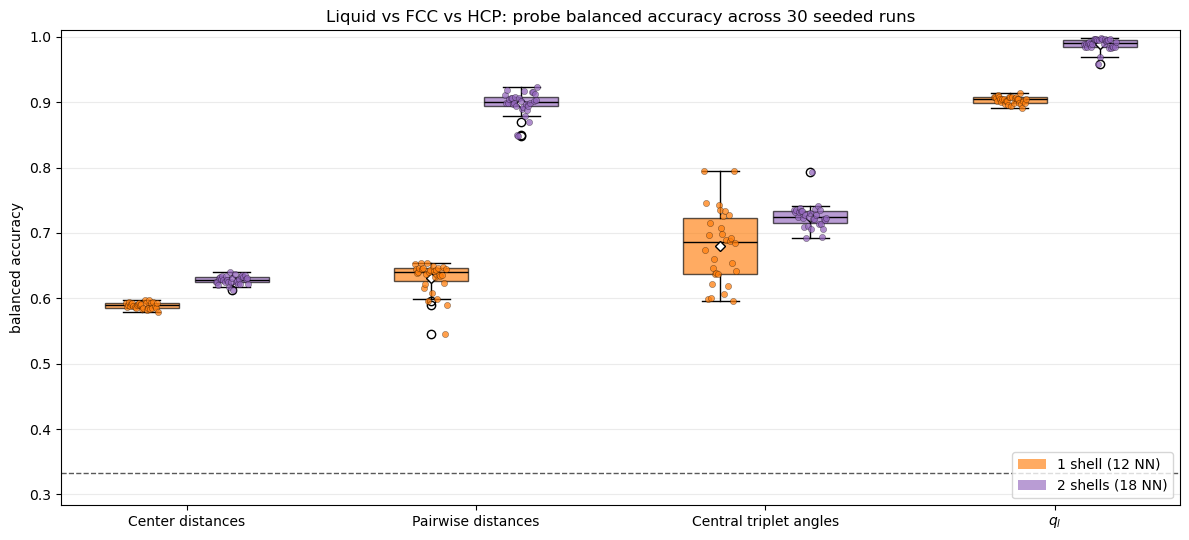

,feature_label,shell_label,mean_balanced_accuracy,std_balanced_accuracy,mean_macro_f1,mean_roc_auc,runs
0,$q_l$,2 shells (18 NN),0.9891,0.0086,0.9891,0.9993,30
1,$q_l$,1 shell (12 NN),0.9035,0.0053,0.9038,0.9742,30
2,Pairwise distances,2 shells (18 NN),0.8985,0.0177,0.8993,0.9705,30
3,Central triplet angles,2 shells (18 NN),0.7251,0.0180,0.7241,0.8403,30
4,Central triplet angles,1 shell (12 NN),0.6801,0.0554,0.6661,0.8191,30
5,Pairwise distances,1 shell (12 NN),0.6318,0.0237,0.6270,0.8202,30
6,Center distances,2 shells (18 NN),0.6282,0.0060,0.6236,0.8216,30
7,Center distances,1 shell (12 NN),0.5892,0.0045,0.5819,0.8018,30


In [79]:
three_score_frames = [three_main_scores]
for seed in ROBUSTNESS_SEEDS:
    if seed == VISUAL_SEED:
        continue
    print(f"Three-class robustness run for seed {seed}")
    seeded_scores, _, _ = run_three_phase_suite(
        seed,
        keep_artifacts=False,
        verbose=False,
    )
    three_score_frames.append(seeded_scores)

three_robustness_scores = pd.concat(three_score_frames, ignore_index=True)
three_robustness_summary = (
    three_robustness_scores
    .groupby(["feature_label", "shell_label"], sort=False)[list(metric_names)]
    .agg(["mean", "std", "min", "max"])
)
display(three_robustness_summary.round(4))

plot_seed_boxplots(
    three_robustness_scores,
    THREE_FEATURE_ORDER,
    THREE_FEATURE_LABELS,
    "Liquid vs FCC vs HCP",
    chance_level=1 / 3,
)

three_ranking = (
    three_robustness_scores
    .groupby(["feature_label", "shell_label"], as_index=False)
    .agg(
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std"),
        mean_macro_f1=("macro_f1", "mean"),
        mean_roc_auc=("roc_auc", "mean"),
        runs=("seed", "nunique"),
    )
    .sort_values("mean_balanced_accuracy", ascending=False)
    .reset_index(drop=True)
)
display(three_ranking.round(4))

In [80]:
comparison_summary = pd.concat(
    [
        robustness_scores.assign(comparison="liquid vs fcc"),
        fcc_hcp_robustness_scores.assign(comparison="fcc vs hcp"),
        three_robustness_scores.assign(comparison="liquid vs fcc vs hcp"),
    ],
    ignore_index=True,
)

comparison_table = (
    comparison_summary
    .groupby(["comparison", "feature_label", "shell_label"])["balanced_accuracy"]
    .agg(["mean", "std"])
)
display(comparison_table.round(4))

mean     std
comparison           feature_label          shell_label                     
fcc vs hcp           $q_l$                  1 shell (12 NN)   0.9605  0.0047
                                            2 shells (18 NN)  0.9981  0.0009
                     Center distances       1 shell (12 NN)   0.5005  0.0078
                                            2 shells (18 NN)  0.5084  0.0072
                     Central triplet angles 1 shell (12 NN)   0.8428  0.0517
                                            2 shells (18 NN)  0.8374  0.0112
                     Pairwise distances     1 shell (12 NN)   0.5058  0.0081
                                            2 shells (18 NN)  0.8740  0.0437
liquid vs fcc        $q_l$                  1 shell (12 NN)   0.9464  0.0049
                                            2 shells (18 NN)  0.9999  0.0001
                     Center distances       1 shell (12 NN)   0.8853  0.0046
                                            2 shells (18 NN)  0.9242  0.0039
                     Neighbor vectors       1 shell (12 NN)   0.5036  0.0079
                                            2 shells (18 NN)  0.5050  0.0096
                     Pairwise distances     1 shell (12 NN)   0.9155  0.0370
                                            2 shells (18 NN)  0.9816  0.0019
liquid vs fcc vs hcp $q_l$                  1 shell (12 NN)   0.9035  0.0053
                                            2 shells (18 NN)  0.9891  0.0086
                     Center distances       1 shell (12 NN)   0.5892  0.0045
                                            2 shells (18 NN)  0.6282  0.0060
                     Central triplet angles 1 shell (12 NN)   0.6801  0.0554
                                            2 shells (18 NN)  0.7251  0.0180
                     Pairwise distances     1 shell (12 NN)   0.6318  0.0237
                                            2 shells (18 NN)  0.8985  0.0177

## Part IV — EGNN with a two-dimensional graph bottleneck

The input is always the complete local neighborhood graph: one center node plus 12 or 18 neighbor nodes. Directed edges connect every pair of distinct nodes. Edge messages depend on scalar node features and squared interparticle distance; coordinate updates are parallel to relative displacement vectors. This gives E(3)-equivariant message passing. Mean/max pooling of scalar node states is permutation invariant, after which a dense network maps the graph embedding to the **two-dimensional latent**.

Four separate graph autoencoders share this encoder design but use target-specific MLP decoders:

1. sorted distances from the center;
2. sorted pairwise distances among center + neighbors;
3. sorted central triplet angles;
4. $q_l$, using standard/non-averaged values for one shell and Lechner–Dellago averaged values for two shells.

All targets are invariant, so an ordinary MLP decoder is symmetry compatible. The phase labels remain probe-only. This first EGNN chapter runs the three-class visual benchmark once; the 30-seed EGNN robustness sweep is deliberately optional because it is much more expensive than the dense-AE sweeps.

In [81]:
# EGNN configuration
RUN_EGNN = True
RUN_EGNN_ROBUSTNESS = False
EGNN_MAX_SAMPLES_PER_PHASE = 3_000
EGNN_EPOCHS = 20
EGNN_BATCH_SIZE = 256
EGNN_LEARNING_RATE = 1e-3
EGNN_WEIGHT_DECAY = 1e-4
EGNN_EARLY_STOPPING_PATIENCE = 5
EGNN_FEATURE_DIM = 48
EGNN_MESSAGE_DIM = 48
EGNN_N_LAYERS = 4
EGNN_COORD_UPDATE_SCALE = 0.05
EGNN_GRAD_CLIP = 5.0
EGNN_LATENT_DIM = 2
EGNN_TARGET_ORDER = THREE_FEATURE_ORDER
EGNN_TARGET_LABELS = THREE_FEATURE_LABELS

if os.environ.get("AE_SMOKE_TEST") == "1":
    EGNN_MAX_SAMPLES_PER_PHASE = 256
    EGNN_EPOCHS = 2
    EGNN_EARLY_STOPPING_PATIENCE = 2

print("EGNN enabled:", RUN_EGNN)
print("EGNN latent dimension:", EGNN_LATENT_DIM)
print("EGNN samples per phase:", EGNN_MAX_SAMPLES_PER_PHASE)

EGNN enabled: True
EGNN latent dimension: 2
EGNN samples per phase: 3000


In [82]:
class EGNNMLP(nn.Module):
    def __init__(self, dimensions, activation=nn.SiLU, final_activation=False):
        super().__init__()
        layers = []
        for index in range(len(dimensions) - 1):
            layers.append(nn.Linear(dimensions[index], dimensions[index + 1]))
            if index < len(dimensions) - 2 or final_activation:
                layers.append(activation())
        self.network = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.network(inputs)


class EGNNLayer(nn.Module):
    """E(n)-equivariant message and coordinate update for a fixed batched graph."""
    def __init__(
        self,
        feature_dim=EGNN_FEATURE_DIM,
        message_dim=EGNN_MESSAGE_DIM,
        coordinate_scale=EGNN_COORD_UPDATE_SCALE,
    ):
        super().__init__()
        self.edge_mlp = EGNNMLP(
            [2 * feature_dim + 1, message_dim, message_dim, message_dim]
        )
        self.coordinate_mlp = EGNNMLP([message_dim, message_dim, 1])
        self.node_mlp = EGNNMLP(
            [feature_dim + message_dim, message_dim, feature_dim]
        )
        self.norm = nn.LayerNorm(feature_dim)
        self.coordinate_scale = coordinate_scale

    def forward(self, node_features, coordinates, edge_index):
        receivers, senders = edge_index
        receiver_features = node_features[:, receivers, :]
        sender_features = node_features[:, senders, :]
        relative = coordinates[:, receivers, :] - coordinates[:, senders, :]
        squared_distance = relative.square().sum(dim=-1, keepdim=True)

        messages = self.edge_mlp(
            torch.cat(
                [receiver_features, sender_features, squared_distance],
                dim=-1,
            )
        )
        coordinate_weight = torch.tanh(self.coordinate_mlp(messages))

        node_count = coordinates.shape[1]
        degrees = torch.bincount(receivers, minlength=node_count).clamp_min(1)
        degree_scale = degrees.to(coordinates.dtype).view(1, node_count, 1)

        coordinate_updates = torch.zeros_like(coordinates)
        coordinate_updates.index_add_(1, receivers, relative * coordinate_weight)
        coordinates = (
            coordinates
            + self.coordinate_scale * coordinate_updates / degree_scale
        )

        aggregated = torch.zeros(
            node_features.shape[0],
            node_count,
            messages.shape[-1],
            device=node_features.device,
            dtype=node_features.dtype,
        )
        aggregated.index_add_(1, receivers, messages)
        aggregated = aggregated / degree_scale
        update = self.node_mlp(torch.cat([node_features, aggregated], dim=-1))
        node_features = self.norm(node_features + update)
        return node_features, coordinates


class EGNNGraphEncoder(nn.Module):
    def __init__(
        self,
        feature_dim=EGNN_FEATURE_DIM,
        n_layers=EGNN_N_LAYERS,
        latent_dim=EGNN_LATENT_DIM,
    ):
        super().__init__()
        # Invariant node inputs: central-node marker and radius from the center.
        self.node_embedding = EGNNMLP([2, feature_dim, feature_dim])
        self.layers = nn.ModuleList(
            [EGNNLayer(feature_dim=feature_dim) for _ in range(n_layers)]
        )
        # This dense graph-level head is the requested squeeze to two dimensions.
        self.to_latent = EGNNMLP(
            [2 * feature_dim, feature_dim, feature_dim, latent_dim]
        )

    def forward(self, coordinates, edge_index):
        relative_to_center = coordinates - coordinates[:, :1, :]
        radii = torch.linalg.norm(relative_to_center, dim=-1, keepdim=True)
        center_marker = torch.zeros_like(radii)
        center_marker[:, 0, 0] = 1.0
        node_features = self.node_embedding(
            torch.cat([center_marker, radii], dim=-1)
        )

        updated_coordinates = coordinates
        for layer in self.layers:
            node_features, updated_coordinates = layer(
                node_features,
                updated_coordinates,
                edge_index,
            )

        pooled = torch.cat(
            [
                node_features.mean(dim=1),
                node_features.max(dim=1).values,
            ],
            dim=-1,
        )
        return self.to_latent(pooled)


class EGNNTargetDecoder(nn.Module):
    def __init__(self, output_dim, hidden_dim=EGNN_FEATURE_DIM):
        super().__init__()
        self.network = nn.Sequential(
            EGNNMLP(
                [EGNN_LATENT_DIM, hidden_dim, hidden_dim, hidden_dim, output_dim]
            ),
            nn.Sigmoid(),
        )

    def forward(self, latent):
        return self.network(latent)


class EGNNReconstructionAutoencoder(nn.Module):
    def __init__(self, output_dim):
        super().__init__()
        self.encoder = EGNNGraphEncoder()
        self.decoder = EGNNTargetDecoder(output_dim)

    def encode(self, coordinates, edge_index):
        return self.encoder(coordinates, edge_index)

    def forward(self, coordinates, edge_index):
        latent = self.encode(coordinates, edge_index)
        return self.decoder(latent), latent


def fully_connected_edge_index(n_nodes):
    receivers, senders = [], []
    for receiver in range(n_nodes):
        for sender in range(n_nodes):
            if receiver != sender:
                receivers.append(receiver)
                senders.append(sender)
    return torch.tensor([receivers, senders], dtype=torch.long)

In [83]:
def coordinates_with_center(vectors):
    center = np.zeros((len(vectors), 1, 3), dtype=np.float32)
    return np.concatenate([center, vectors.astype(np.float32)], axis=1)


def egnn_target_array(data, target_kind, indices):
    if target_kind == "radii":
        return data["dist"][indices].copy()
    if target_kind == "pairwise_distances":
        return pairwise_distance_features(data["vec_dist"][indices])
    if target_kind == "triplets":
        return triplet_angle_features(data["vec_dist"][indices])
    if target_kind == "ql":
        return data["ql"][indices].copy()
    raise KeyError(target_kind)


def prepare_egnn_experiment(shell_name, target_kind, plan):
    coordinate_parts, target_parts, label_parts, split_parts = [], [], [], []
    for phase in THREE_PHASES:
        entry = plan[phase]
        data = three_phase_shell_data[shell_name][phase]
        coordinate_parts.append(
            coordinates_with_center(data["vec_dist"][entry["indices"]])
        )
        target_parts.append(
            egnn_target_array(data, target_kind, entry["indices"])
        )
        label_parts.append(
            np.full(len(entry["indices"]), THREE_LABEL_MAP[phase], dtype=np.int64)
        )
        split_parts.append(entry["split"])

    return (
        np.concatenate(coordinate_parts).astype(np.float32, copy=False),
        np.concatenate(target_parts).astype(np.float32, copy=False),
        np.concatenate(label_parts),
        np.concatenate(split_parts),
    )


def train_egnn_reconstructor(coordinates, targets, split, seed):
    set_seed(seed)
    train_mask = split == "train"
    val_mask = split == "val"
    test_mask = split == "test"

    # Coordinates are relative to the center. Fit one physical scale on train only.
    training_radii = np.linalg.norm(coordinates[train_mask, 1:, :], axis=-1)
    coordinate_scale = float(np.median(training_radii))
    if not np.isfinite(coordinate_scale) or coordinate_scale <= 0:
        coordinate_scale = 1.0
    scaled_coordinates = (coordinates / coordinate_scale).astype(np.float32)

    target_scaler = MinMaxScaler()
    target_scaler.fit(targets[train_mask])
    scaled_targets = target_scaler.transform(targets).astype(np.float32)

    train_coordinates = torch.from_numpy(scaled_coordinates[train_mask])
    train_targets = torch.from_numpy(scaled_targets[train_mask])
    val_coordinates = torch.from_numpy(scaled_coordinates[val_mask])
    val_targets = torch.from_numpy(scaled_targets[val_mask])
    generator = torch.Generator().manual_seed(seed)

    train_loader = DataLoader(
        TensorDataset(train_coordinates, train_targets),
        batch_size=EGNN_BATCH_SIZE,
        shuffle=True,
        generator=generator,
        num_workers=0,
    )
    val_loader = DataLoader(
        TensorDataset(val_coordinates, val_targets),
        batch_size=EGNN_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )

    edge_index = fully_connected_edge_index(scaled_coordinates.shape[1]).to(DEVICE)
    model = EGNNReconstructionAutoencoder(scaled_targets.shape[1]).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=EGNN_LEARNING_RATE,
        weight_decay=EGNN_WEIGHT_DECAY,
    )
    criterion = nn.MSELoss()
    history = {"train_mse": [], "val_mse": []}
    best_state = None
    best_val = np.inf
    best_epoch = -1
    stale_epochs = 0

    for epoch in range(EGNN_EPOCHS):
        model.train()
        running = 0.0
        for coordinate_batch, target_batch in train_loader:
            coordinate_batch = coordinate_batch.to(DEVICE)
            target_batch = target_batch.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            prediction, _ = model(coordinate_batch, edge_index)
            loss = criterion(prediction, target_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), EGNN_GRAD_CLIP)
            optimizer.step()
            running += loss.item() * len(coordinate_batch)
        train_mse = running / len(train_coordinates)

        model.eval()
        running = 0.0
        with torch.no_grad():
            for coordinate_batch, target_batch in val_loader:
                coordinate_batch = coordinate_batch.to(DEVICE)
                target_batch = target_batch.to(DEVICE)
                prediction, _ = model(coordinate_batch, edge_index)
                running += criterion(prediction, target_batch).item() * len(coordinate_batch)
        val_mse = running / len(val_coordinates)
        history["train_mse"].append(train_mse)
        history["val_mse"].append(val_mse)

        if val_mse < best_val - 1e-8:
            best_val = val_mse
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= EGNN_EARLY_STOPPING_PATIENCE:
                break

    model.load_state_dict(best_state)
    model.eval()
    latent_chunks = []
    test_squared_error = 0.0
    test_count = 0
    with torch.no_grad():
        for start in range(0, len(scaled_coordinates), EGNN_BATCH_SIZE):
            stop = min(start + EGNN_BATCH_SIZE, len(scaled_coordinates))
            coordinate_batch = torch.from_numpy(
                scaled_coordinates[start:stop]
            ).to(DEVICE)
            prediction, latent = model(coordinate_batch, edge_index)
            latent_chunks.append(latent.cpu().numpy())
            local_test = test_mask[start:stop]
            if np.any(local_test):
                target_batch = torch.from_numpy(
                    scaled_targets[start:stop][local_test]
                ).to(DEVICE)
                test_squared_error += nn.functional.mse_loss(
                    prediction[local_test],
                    target_batch,
                    reduction="sum",
                ).item()
                test_count += int(local_test.sum()) * scaled_targets.shape[1]

    return {
        "model": model,
        "target_scaler": target_scaler,
        "coordinate_scale": coordinate_scale,
        "edge_index": edge_index,
        "history": history,
        "Z": np.concatenate(latent_chunks),
        "best_epoch": best_epoch + 1,
        "best_val_mse": float(best_val),
        "test_mse": test_squared_error / test_count,
    }

In [84]:
def run_egnn_suite(seed=VISUAL_SEED, keep_artifacts=True, verbose=True):
    plan = build_three_phase_sampling_plan(
        seed,
        max_samples_per_phase=EGNN_MAX_SAMPLES_PER_PHASE,
    )
    rows = []
    artifacts = {}

    for shell_name in SHELL_ORDER:
        shell_cfg = SHELL_CONFIG[shell_name]
        ql_exact = all(
            three_phase_shell_data[shell_name][phase]["ql_exact"]
            for phase in THREE_PHASES
        )
        for target_kind in EGNN_TARGET_ORDER:
            if verbose:
                print(
                    f"EGNN seed={seed:>3} | {shell_cfg['label']:<18} | "
                    f"decode {EGNN_TARGET_LABELS[target_kind]}"
                )
            coordinates, targets, y, split = prepare_egnn_experiment(
                shell_name,
                target_kind,
                plan,
            )
            trained = train_egnn_reconstructor(coordinates, targets, split, seed)
            probe = probe_latent_multiclass(trained["Z"], y, split, seed)

            rows.append(
                {
                    "seed": seed,
                    "shell": shell_name,
                    "shell_label": shell_cfg["label"],
                    "n_neighbors": shell_cfg["n_neighbors"],
                    "n_graph_nodes": coordinates.shape[1],
                    "target": target_kind,
                    "target_label": EGNN_TARGET_LABELS[target_kind],
                    "target_dim": targets.shape[1],
                    "latent_dim": trained["Z"].shape[1],
                    "n_samples": len(y),
                    "best_epoch": trained["best_epoch"],
                    "validation_mse": trained["best_val_mse"],
                    "test_reconstruction_mse": trained["test_mse"],
                    "accuracy": probe["accuracy"],
                    "balanced_accuracy": probe["balanced_accuracy"],
                    "macro_f1": probe["macro_f1"],
                    "roc_auc": probe["roc_auc"],
                    "q_l_variant": shell_cfg["ql_variant"] if target_kind == "ql" else pd.NA,
                    "q_l_exact_requested_NN": ql_exact if target_kind == "ql" else pd.NA,
                }
            )
            if keep_artifacts:
                artifacts[(shell_name, target_kind)] = {
                    "Z": trained["Z"],
                    "y": y,
                    "split": split,
                    "history": trained["history"],
                    "model": trained["model"],
                    "target_scaler": trained["target_scaler"],
                    "coordinate_scale": trained["coordinate_scale"],
                    "edge_index": trained["edge_index"],
                    "probe": probe,
                }

            del coordinates, targets, trained
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return pd.DataFrame(rows), artifacts, plan

### EGNN main run and latent probes

In [85]:
if RUN_EGNN:
    egnn_scores, egnn_artifacts, egnn_plan = run_egnn_suite(
        VISUAL_SEED,
        keep_artifacts=True,
        verbose=True,
    )
    display(
        egnn_scores.sort_values(["target_label", "shell_label"])
        .reset_index(drop=True)
        .round(4)
    )

EGNN seed= 42 | 1 shell (12 NN)    | decode Center distances
EGNN seed= 42 | 1 shell (12 NN)    | decode Pairwise distances
EGNN seed= 42 | 1 shell (12 NN)    | decode Central triplet angles
EGNN seed= 42 | 1 shell (12 NN)    | decode $q_l$
EGNN seed= 42 | 2 shells (18 NN)   | decode Center distances
EGNN seed= 42 | 2 shells (18 NN)   | decode Pairwise distances
EGNN seed= 42 | 2 shells (18 NN)   | decode Central triplet angles
EGNN seed= 42 | 2 shells (18 NN)   | decode $q_l$


,seed,shell,shell_label,n_neighbors,n_graph_nodes,target,target_label,target_dim,latent_dim,n_samples,best_epoch,validation_mse,test_reconstruction_mse,accuracy,balanced_accuracy,macro_f1,roc_auc,q_l_variant,q_l_exact_requested_NN
0,42,first_shell,1 shell (12 NN),12,13,ql,$q_l$,20,2,9000,20,0.0166,0.0177,0.5816,0.5857,0.5426,0.7999,standard,True
1,42,second_shell,2 shells (18 NN),18,19,ql,$q_l$,20,2,9000,20,0.0179,0.0182,0.6241,0.6265,0.6187,0.8105,Lechner-Dellago averaged,False
2,42,first_shell,1 shell (12 NN),12,13,radii,Center distances,12,2,9000,18,0.0057,0.0058,0.5720,0.5737,0.5688,0.7954,<NA>,<NA>
3,42,second_shell,2 shells (18 NN),18,19,radii,Center distances,18,2,9000,16,0.0128,0.0133,0.5869,0.5889,0.5828,0.8018,<NA>,<NA>
4,42,first_shell,1 shell (12 NN),12,13,triplets,Central triplet angles,66,2,9000,20,0.0045,0.0045,0.5300,0.5297,0.5083,0.7471,<NA>,<NA>
5,42,second_shell,2 shells (18 NN),18,19,triplets,Central triplet angles,153,2,9000,19,0.0036,0.0036,0.4397,0.4409,0.4361,0.6376,<NA>,<NA>
6,42,first_shell,1 shell (12 NN),12,13,pairwise_distances,Pairwise distances,78,2,9000,20,0.0028,0.0028,0.5651,0.5627,0.5114,0.7868,<NA>,<NA>
7,42,second_shell,2 shells (18 NN),18,19,pairwise_distances,Pairwise distances,171,2,9000,20,0.0031,0.0030,0.5779,0.5808,0.5672,0.7617,<NA>,<NA>


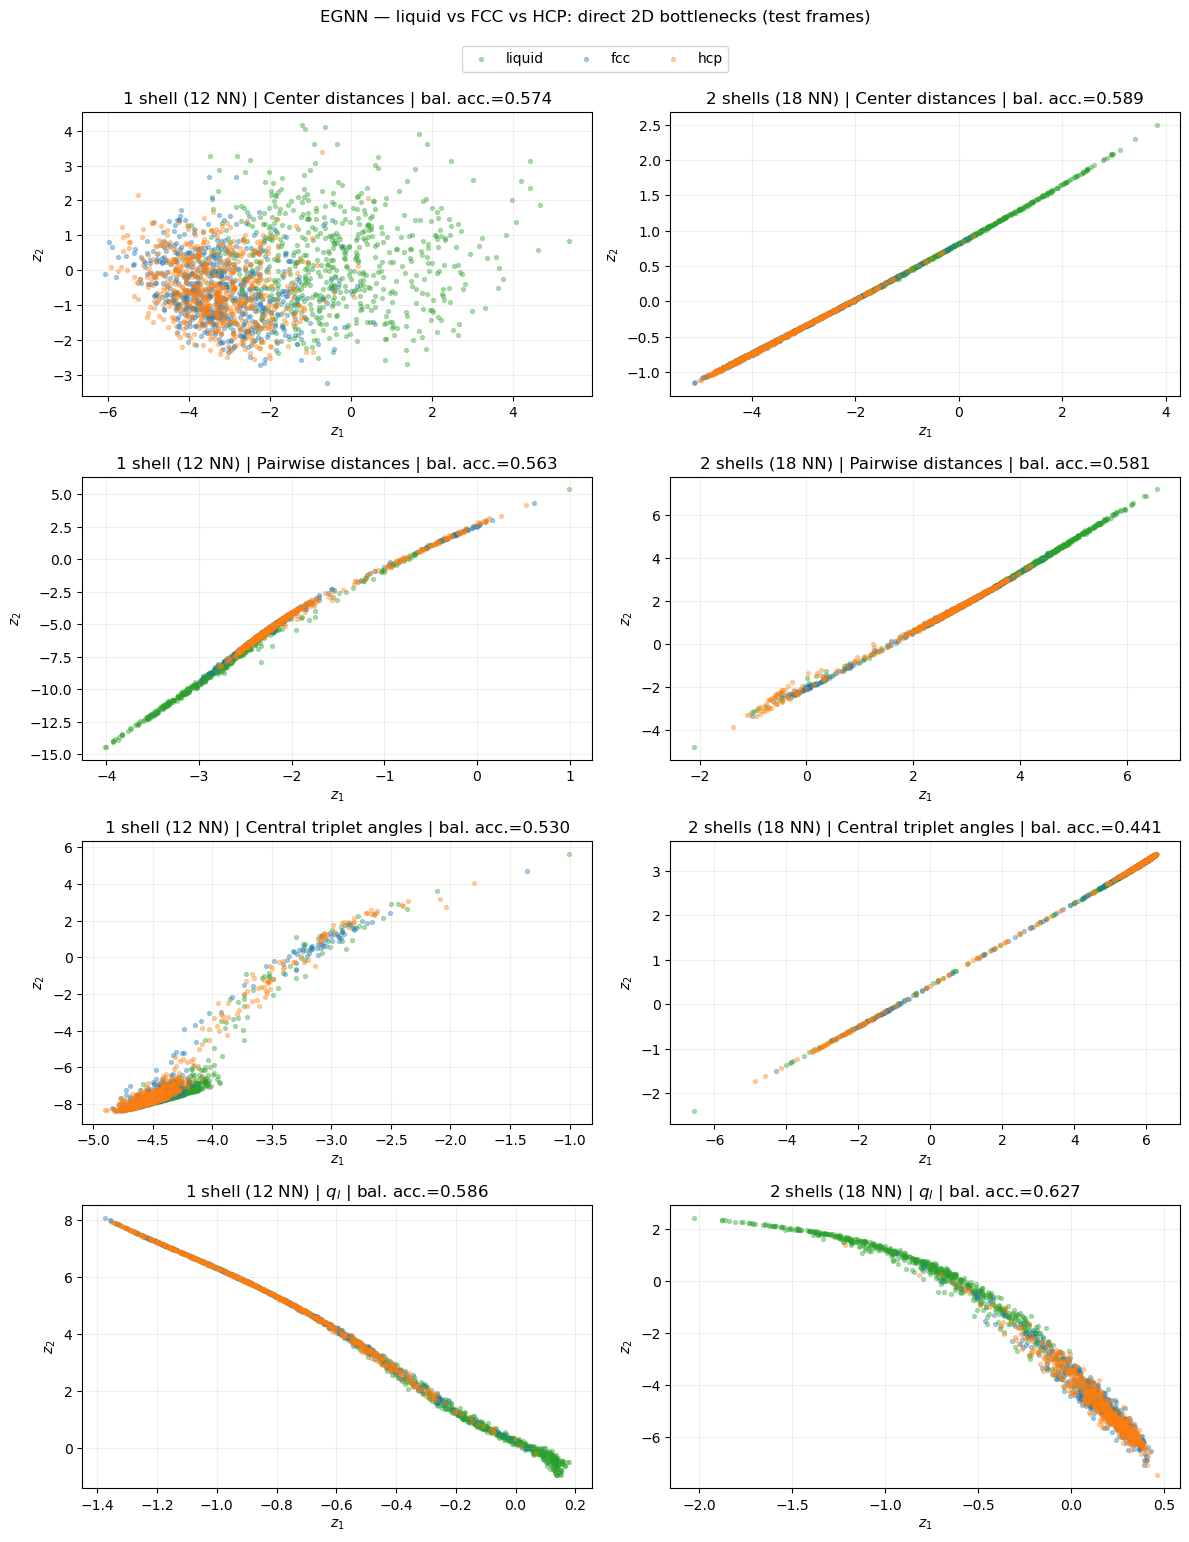

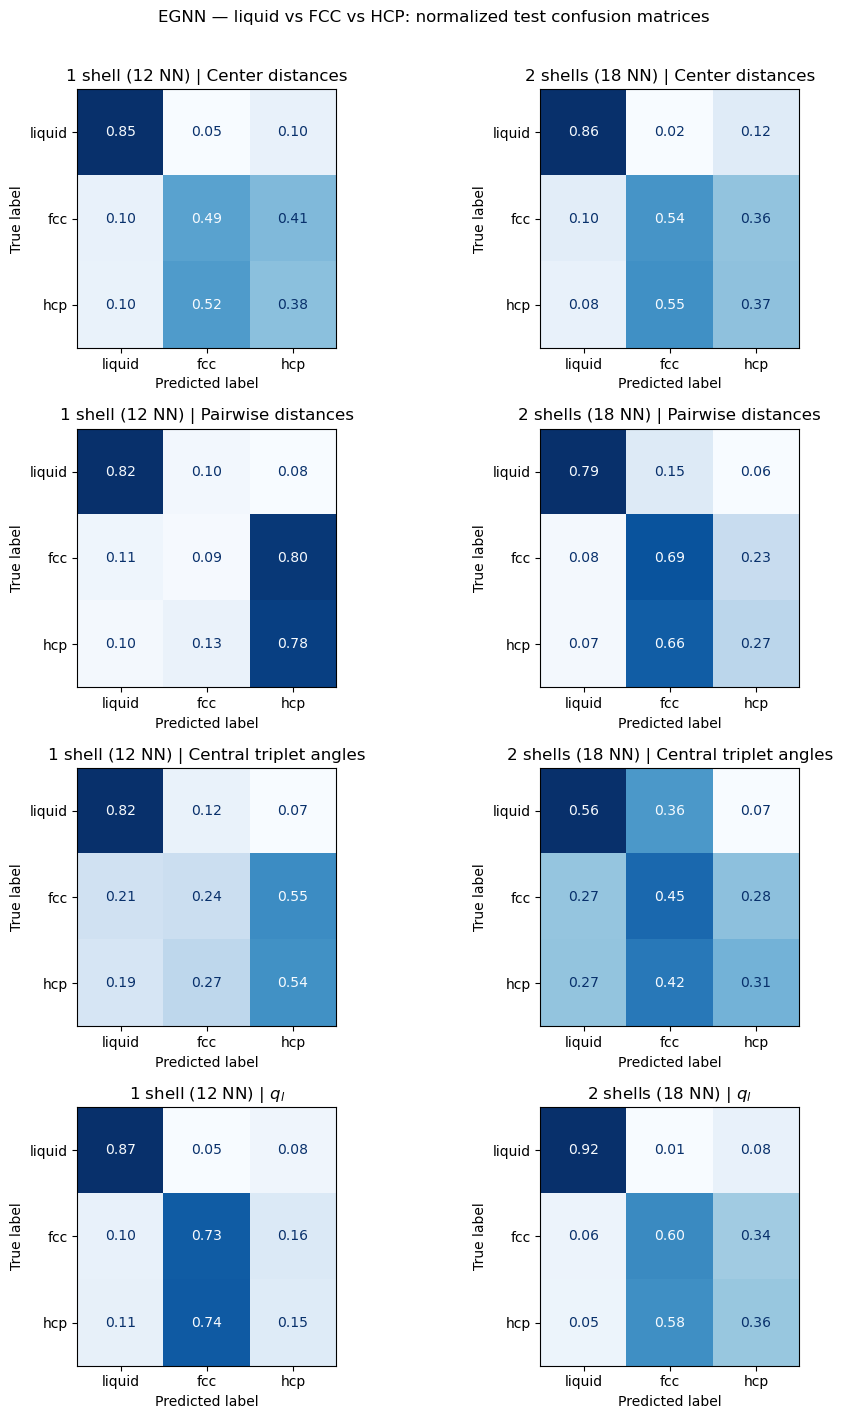

balanced_accuracy                         macro_f1  \
shell_label              1 shell (12 NN) 2 shells (18 NN) 1 shell (12 NN)   
target_label                                                                
$q_l$                             0.5857           0.6265          0.5426   
Center distances                  0.5737           0.5889          0.5688   
Central triplet angles            0.5297           0.4409          0.5083   
Pairwise distances                0.5627           0.5808          0.5114   

                                                roc_auc                   
shell_label            2 shells (18 NN) 1 shell (12 NN) 2 shells (18 NN)  
target_label                                                              
$q_l$                            0.6187          0.7999           0.8105  
Center distances                 0.5828          0.7954           0.8018  
Central triplet angles           0.4361          0.7471           0.6376  
Pairwise distances               0.5672          0.7868           0.7617

model                                    EGNN AE  simple AE
target_label           shell_label                         
$q_l$                  1 shell (12 NN)    0.5857     0.9073
                       2 shells (18 NN)   0.6265     0.9892
Center distances       1 shell (12 NN)    0.5737     0.5926
                       2 shells (18 NN)   0.5889     0.6243
Central triplet angles 1 shell (12 NN)    0.5297     0.7940
                       2 shells (18 NN)   0.4409     0.7352
Pairwise distances     1 shell (12 NN)    0.5627     0.6532
                       2 shells (18 NN)   0.5808     0.9104

In [86]:
if RUN_EGNN:
    plot_multiclass_latent_grid(
        egnn_artifacts,
        EGNN_TARGET_ORDER,
        EGNN_TARGET_LABELS,
        "EGNN — liquid vs FCC vs HCP",
    )
    plot_multiclass_confusion_grid(
        egnn_artifacts,
        EGNN_TARGET_ORDER,
        EGNN_TARGET_LABELS,
        "EGNN — liquid vs FCC vs HCP",
    )

    egnn_probe_table = egnn_scores.pivot(
        index="target_label",
        columns="shell_label",
        values=["balanced_accuracy", "macro_f1", "roc_auc"],
    )
    display(egnn_probe_table.round(4))

    matched_comparison = pd.concat(
        [
            three_main_scores[
                ["shell_label", "feature_label", "balanced_accuracy"]
            ].rename(columns={"feature_label": "target_label"}).assign(model="simple AE"),
            egnn_scores[
                ["shell_label", "target_label", "balanced_accuracy"]
            ].assign(model="EGNN AE"),
        ],
        ignore_index=True,
    )
    display(
        matched_comparison.pivot_table(
            index=["target_label", "shell_label"],
            columns="model",
            values="balanced_accuracy",
        ).round(4)
    )

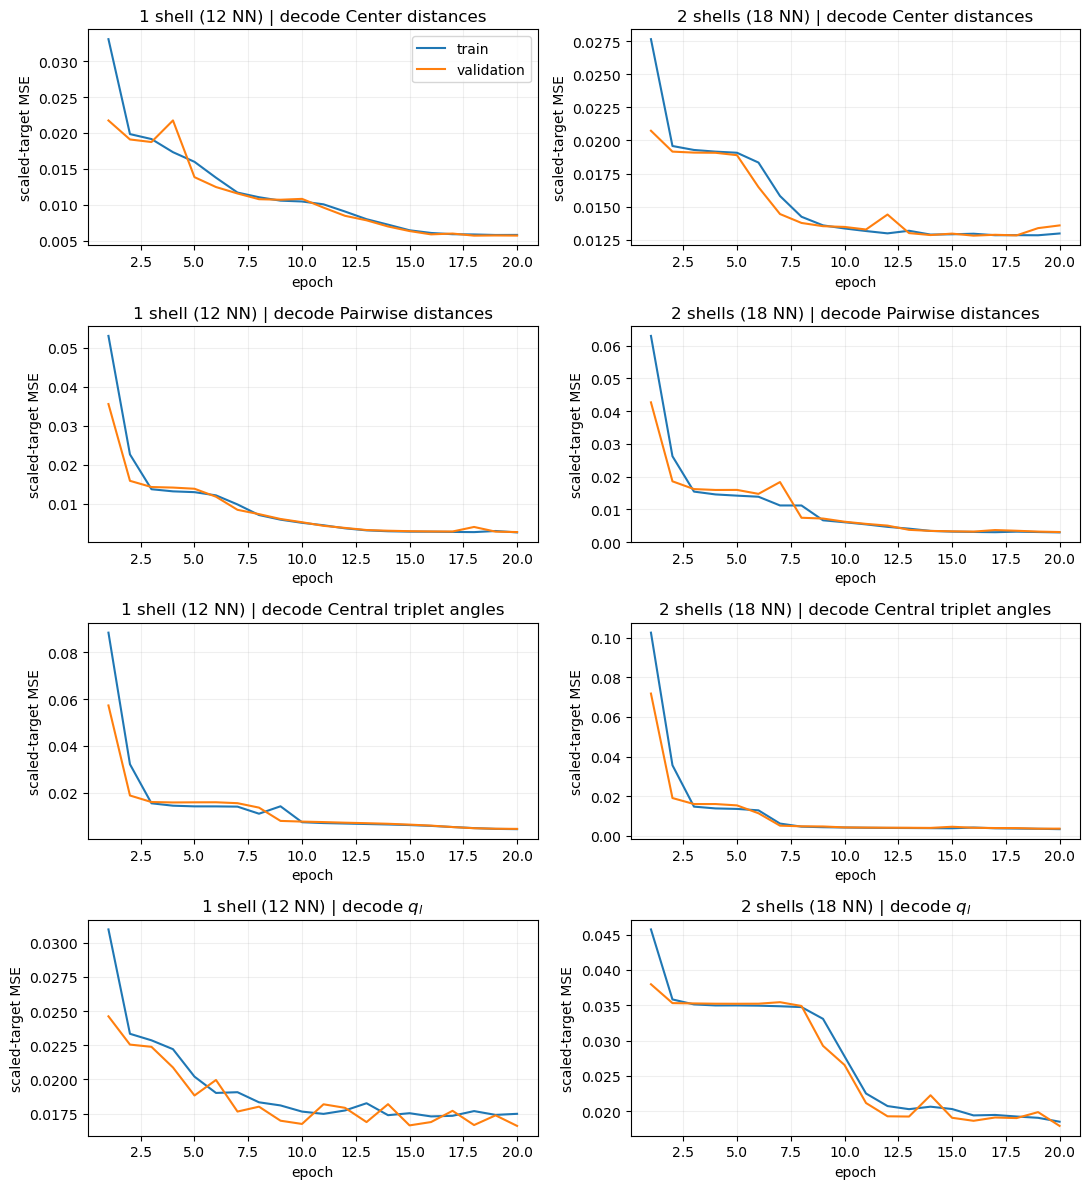

In [87]:
if RUN_EGNN:
    fig, axes = plt.subplots(
        len(EGNN_TARGET_ORDER),
        len(SHELL_ORDER),
        figsize=(11, 12),
        squeeze=False,
    )
    for row, target_kind in enumerate(EGNN_TARGET_ORDER):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            history = egnn_artifacts[(shell_name, target_kind)]["history"]
            epochs = np.arange(1, len(history["train_mse"]) + 1)
            ax.plot(epochs, history["train_mse"], label="train")
            ax.plot(epochs, history["val_mse"], label="validation")
            ax.set_title(
                f"{SHELL_CONFIG[shell_name]['label']} | "
                f"decode {EGNN_TARGET_LABELS[target_kind]}"
            )
            ax.set_xlabel("epoch")
            ax.set_ylabel("scaled-target MSE")
            ax.grid(alpha=0.2)
    axes[0, 0].legend()
    plt.tight_layout()
    plt.show()

### Optional EGNN robustness hook

Setting `RUN_EGNN_ROBUSTNESS=True` repeats the complete EGNN suite over the same 30 seeds. This means 240 graph-autoencoder fits (30 seeds × 2 shells × 4 targets), so it is off by default. The output schema matches the simple-AE robustness tables and uses the same three-class chance level.

In [88]:
if RUN_EGNN and RUN_EGNN_ROBUSTNESS:
    egnn_score_frames = [egnn_scores]
    for seed in ROBUSTNESS_SEEDS:
        if seed == VISUAL_SEED:
            continue
        print(f"EGNN robustness run for seed {seed}")
        seeded_scores, _, _ = run_egnn_suite(
            seed,
            keep_artifacts=False,
            verbose=False,
        )
        egnn_score_frames.append(seeded_scores)

    egnn_robustness_scores = pd.concat(egnn_score_frames, ignore_index=True)
    display(
        egnn_robustness_scores
        .groupby(["target_label", "shell_label"])[list(metric_names)]
        .agg(["mean", "std", "min", "max"])
        .round(4)
    )
    plot_seed_boxplots(
        egnn_robustness_scores.rename(
            columns={"target": "feature", "target_label": "feature_label"}
        ),
        EGNN_TARGET_ORDER,
        EGNN_TARGET_LABELS,
        "EGNN — liquid vs FCC vs HCP",
        chance_level=1 / 3,
    )

### EGNN interpretation notes

- The graph encoder has access to the same local coordinates for every decoder target; only the unsupervised reconstruction pressure changes.
- A two-dimensional latent is intentionally severe. If reconstruction and probing both fail, a later latent-width ablation can distinguish an information bottleneck from an architectural problem.
- Radius and pairwise targets emphasize radial geometry; triplets and $q_l$ place progressively stronger pressure on angular order.
- The decoder never reconstructs raw coordinates, avoiding the need to align orientations or construct an equivariant coordinate decoder.
- The current second-shell $q_l$ target is Lechner–Dellago averaged but was generated with 12 descriptor neighbors. Regenerate the exact 18-neighbor files before treating that row as a strict second-shell $q_l$ result.

## Part V — EGNN minimal-upgrade follow-up

This is a matched follow-up to Part IV, not a replacement. It keeps the complete neighborhood graph, four separate reconstruction targets, three-class probe, both shells, and an exactly two-dimensional latent. Only the smallest changes suggested by the preceding diagnosis are introduced:

1. coordinate updates are disabled because every target is invariant;
2. the readout concatenates the center state with mean/max neighbor states;
3. targets are standardized and decoded without a sigmoid using Smooth-L1 loss;
4. small variance and covariance penalties discourage an effectively one-dimensional latent;
5. the run uses more graphs and a minimum optimizer-step budget.

This preserves a POC architecture: three message-passing layers, one dense 2D bottleneck, and one ordinary MLP decoder per target. The frame-grouped split and all probe metrics are unchanged, so Part IV and Part V can be compared directly. The upgraded run remains a single design seed; robustness should only be enabled after it demonstrates a useful improvement.

In [89]:
# Minimal-upgrade configuration
RUN_EGNN_MINIMAL_UPGRADE = True
EGNN_V2_MAX_SAMPLES_PER_PHASE = 10_000
EGNN_V2_MAX_EPOCHS = 45
EGNN_V2_MIN_OPTIMIZER_STEPS = 1_500
EGNN_V2_BATCH_SIZE = 256
EGNN_V2_LEARNING_RATE = 5e-4
EGNN_V2_WEIGHT_DECAY = 1e-5
EGNN_V2_EARLY_STOPPING_PATIENCE = 8
EGNN_V2_FEATURE_DIM = 48
EGNN_V2_MESSAGE_DIM = 48
EGNN_V2_N_LAYERS = 3
EGNN_V2_GRAD_CLIP = 2.0
EGNN_V2_VARIANCE_TARGET = 0.5
EGNN_V2_VARIANCE_WEIGHT = 5e-2
EGNN_V2_COVARIANCE_WEIGHT = 1e-2

if os.environ.get("AE_SMOKE_TEST") == "1":
    EGNN_V2_MAX_SAMPLES_PER_PHASE = 256
    EGNN_V2_MAX_EPOCHS = 2
    EGNN_V2_MIN_OPTIMIZER_STEPS = 0
    EGNN_V2_EARLY_STOPPING_PATIENCE = 2

print("Minimal-upgrade EGNN enabled:", RUN_EGNN_MINIMAL_UPGRADE)
print("Samples per phase:", EGNN_V2_MAX_SAMPLES_PER_PHASE)
print("Minimum optimizer steps:", EGNN_V2_MIN_OPTIMIZER_STEPS)

Minimal-upgrade EGNN enabled: True
Samples per phase: 10000
Minimum optimizer steps: 1500


In [90]:
class EGNNInvariantLayerV2(nn.Module):
    """Distance-message EGNN layer with the unnecessary coordinate update removed."""
    def __init__(
        self,
        feature_dim=EGNN_V2_FEATURE_DIM,
        message_dim=EGNN_V2_MESSAGE_DIM,
    ):
        super().__init__()
        self.edge_mlp = EGNNMLP(
            [2 * feature_dim + 1, message_dim, message_dim, message_dim]
        )
        self.node_mlp = EGNNMLP(
            [feature_dim + message_dim, message_dim, feature_dim]
        )
        self.norm = nn.LayerNorm(feature_dim)

    def forward(self, node_features, coordinates, edge_index):
        receivers, senders = edge_index
        relative = coordinates[:, receivers, :] - coordinates[:, senders, :]
        squared_distance = relative.square().sum(dim=-1, keepdim=True)
        messages = self.edge_mlp(
            torch.cat(
                [
                    node_features[:, receivers, :],
                    node_features[:, senders, :],
                    squared_distance,
                ],
                dim=-1,
            )
        )

        n_nodes = node_features.shape[1]
        aggregated = torch.zeros(
            node_features.shape[0],
            n_nodes,
            messages.shape[-1],
            device=node_features.device,
            dtype=node_features.dtype,
        )
        aggregated.index_add_(1, receivers, messages)
        degree = torch.bincount(receivers, minlength=n_nodes).clamp_min(1)
        aggregated = aggregated / degree.to(node_features.dtype).view(1, n_nodes, 1)

        update = self.node_mlp(torch.cat([node_features, aggregated], dim=-1))
        return self.norm(node_features + update)


class EGNNGraphEncoderV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.node_embedding = EGNNMLP(
            [2, EGNN_V2_FEATURE_DIM, EGNN_V2_FEATURE_DIM]
        )
        self.layers = nn.ModuleList(
            [EGNNInvariantLayerV2() for _ in range(EGNN_V2_N_LAYERS)]
        )
        # Explicit center-aware graph readout followed by the exact 2D squeeze.
        self.to_latent = EGNNMLP(
            [
                3 * EGNN_V2_FEATURE_DIM,
                EGNN_V2_FEATURE_DIM,
                EGNN_V2_FEATURE_DIM,
                2,
            ]
        )

    def forward(self, coordinates, edge_index):
        relative_to_center = coordinates - coordinates[:, :1, :]
        radii = torch.linalg.norm(relative_to_center, dim=-1, keepdim=True)
        center_marker = torch.zeros_like(radii)
        center_marker[:, 0, 0] = 1.0
        node_features = self.node_embedding(
            torch.cat([center_marker, radii], dim=-1)
        )

        for layer in self.layers:
            node_features = layer(node_features, coordinates, edge_index)

        center_state = node_features[:, 0, :]
        neighbor_states = node_features[:, 1:, :]
        graph_state = torch.cat(
            [
                center_state,
                neighbor_states.mean(dim=1),
                neighbor_states.max(dim=1).values,
            ],
            dim=-1,
        )
        return self.to_latent(graph_state)


class EGNNDecoderV2(nn.Module):
    def __init__(self, output_dim):
        super().__init__()
        # No sigmoid: StandardScaler targets naturally span the real line.
        self.network = EGNNMLP(
            [2, EGNN_V2_FEATURE_DIM, EGNN_V2_FEATURE_DIM, output_dim]
        )

    def forward(self, latent):
        return self.network(latent)


class EGNNReconstructionAutoencoderV2(nn.Module):
    def __init__(self, output_dim):
        super().__init__()
        self.encoder = EGNNGraphEncoderV2()
        self.decoder = EGNNDecoderV2(output_dim)

    def encode(self, coordinates, edge_index):
        return self.encoder(coordinates, edge_index)

    def forward(self, coordinates, edge_index):
        latent = self.encode(coordinates, edge_index)
        return self.decoder(latent), latent


def latent_usage_penalty(latent):
    """Small label-free penalty that keeps both latent coordinates active."""
    centered = latent - latent.mean(dim=0, keepdim=True)
    std = torch.sqrt(centered.var(dim=0, unbiased=False) + 1e-4)
    variance_loss = torch.relu(EGNN_V2_VARIANCE_TARGET - std).square().mean()
    normalized = centered / std.clamp_min(1e-4)
    correlation = (normalized[:, 0] * normalized[:, 1]).mean()
    covariance_loss = correlation.square()
    return variance_loss, covariance_loss


def latent_usage_diagnostics(latent):
    centered = latent - latent.mean(axis=0, keepdims=True)
    covariance = np.cov(centered, rowvar=False)
    eigenvalues = np.maximum(np.linalg.eigvalsh(covariance), 0.0)
    effective_rank = (
        float(eigenvalues.sum() ** 2 / np.square(eigenvalues).sum())
        if np.square(eigenvalues).sum() > 0
        else 0.0
    )
    correlation = float(np.corrcoef(centered, rowvar=False)[0, 1])
    return {
        "latent_std_1": float(centered[:, 0].std()),
        "latent_std_2": float(centered[:, 1].std()),
        "latent_abs_correlation": abs(correlation),
        "latent_effective_rank": effective_rank,
    }

In [91]:
def train_egnn_reconstructor_v2(coordinates, targets, split, seed):
    set_seed(seed)
    train_mask = split == "train"
    val_mask = split == "val"
    test_mask = split == "test"

    training_radii = np.linalg.norm(coordinates[train_mask, 1:, :], axis=-1)
    coordinate_scale = float(np.median(training_radii))
    if not np.isfinite(coordinate_scale) or coordinate_scale <= 0:
        coordinate_scale = 1.0
    scaled_coordinates = (coordinates / coordinate_scale).astype(np.float32)

    target_scaler = StandardScaler()
    target_scaler.fit(targets[train_mask])
    scaled_targets = target_scaler.transform(targets).astype(np.float32)

    train_coordinates = torch.from_numpy(scaled_coordinates[train_mask])
    train_targets = torch.from_numpy(scaled_targets[train_mask])
    val_coordinates = torch.from_numpy(scaled_coordinates[val_mask])
    val_targets = torch.from_numpy(scaled_targets[val_mask])
    generator = torch.Generator().manual_seed(seed)

    train_loader = DataLoader(
        TensorDataset(train_coordinates, train_targets),
        batch_size=EGNN_V2_BATCH_SIZE,
        shuffle=True,
        generator=generator,
        num_workers=0,
    )
    val_loader = DataLoader(
        TensorDataset(val_coordinates, val_targets),
        batch_size=EGNN_V2_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )

    edge_index = fully_connected_edge_index(scaled_coordinates.shape[1]).to(DEVICE)
    model = EGNNReconstructionAutoencoderV2(scaled_targets.shape[1]).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=EGNN_V2_LEARNING_RATE,
        weight_decay=EGNN_V2_WEIGHT_DECAY,
    )
    reconstruction_loss = nn.SmoothL1Loss()
    history = {
        "train_reconstruction": [],
        "train_variance": [],
        "train_covariance": [],
        "val_reconstruction": [],
        "val_objective": [],
        "optimizer_steps": [],
    }
    best_state = None
    best_val = np.inf
    best_epoch = -1
    stale_epochs = 0
    optimizer_steps = 0

    for epoch in range(EGNN_V2_MAX_EPOCHS):
        model.train()
        reconstruction_total = 0.0
        variance_total = 0.0
        covariance_total = 0.0
        for coordinate_batch, target_batch in train_loader:
            coordinate_batch = coordinate_batch.to(DEVICE)
            target_batch = target_batch.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            prediction, latent = model(coordinate_batch, edge_index)
            recon = reconstruction_loss(prediction, target_batch)
            variance, covariance = latent_usage_penalty(latent)
            loss = (
                recon
                + EGNN_V2_VARIANCE_WEIGHT * variance
                + EGNN_V2_COVARIANCE_WEIGHT * covariance
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), EGNN_V2_GRAD_CLIP)
            optimizer.step()
            optimizer_steps += 1
            batch_size = len(coordinate_batch)
            reconstruction_total += recon.item() * batch_size
            variance_total += variance.item() * batch_size
            covariance_total += covariance.item() * batch_size

        model.eval()
        validation_total = 0.0
        validation_variance_total = 0.0
        validation_covariance_total = 0.0
        with torch.no_grad():
            for coordinate_batch, target_batch in val_loader:
                coordinate_batch = coordinate_batch.to(DEVICE)
                target_batch = target_batch.to(DEVICE)
                prediction, latent = model(coordinate_batch, edge_index)
                val_variance, val_covariance = latent_usage_penalty(latent)
                batch_size = len(coordinate_batch)
                validation_total += (
                    reconstruction_loss(prediction, target_batch).item()
                    * batch_size
                )
                validation_variance_total += val_variance.item() * batch_size
                validation_covariance_total += val_covariance.item() * batch_size

        train_count = len(train_coordinates)
        validation_count = len(val_coordinates)
        val_reconstruction = validation_total / validation_count
        val_objective = (
            val_reconstruction
            + EGNN_V2_VARIANCE_WEIGHT
            * validation_variance_total / validation_count
            + EGNN_V2_COVARIANCE_WEIGHT
            * validation_covariance_total / validation_count
        )
        history["train_reconstruction"].append(reconstruction_total / train_count)
        history["train_variance"].append(variance_total / train_count)
        history["train_covariance"].append(covariance_total / train_count)
        history["val_reconstruction"].append(val_reconstruction)
        history["val_objective"].append(val_objective)
        history["optimizer_steps"].append(optimizer_steps)

        if val_objective < best_val - 1e-6:
            best_val = val_objective
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1

        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(
                f"epoch={epoch + 1:02d} steps={optimizer_steps:04d} "
                f"train={history['train_reconstruction'][-1]:.5f} "
                f"val_recon={val_reconstruction:.5f} "
                f"val_total={val_objective:.5f}"
            )
        if (
            optimizer_steps >= EGNN_V2_MIN_OPTIMIZER_STEPS
            and stale_epochs >= EGNN_V2_EARLY_STOPPING_PATIENCE
        ):
            break

    model.load_state_dict(best_state)
    model.eval()
    latent_chunks = []
    test_loss_sum = 0.0
    test_element_count = 0
    with torch.no_grad():
        for start in range(0, len(scaled_coordinates), EGNN_V2_BATCH_SIZE):
            stop = min(start + EGNN_V2_BATCH_SIZE, len(scaled_coordinates))
            coordinate_batch = torch.from_numpy(scaled_coordinates[start:stop]).to(DEVICE)
            prediction, latent = model(coordinate_batch, edge_index)
            latent_chunks.append(latent.cpu().numpy())

            local_test = test_mask[start:stop]
            if np.any(local_test):
                torch_mask = torch.from_numpy(local_test).to(DEVICE)
                target_batch = torch.from_numpy(scaled_targets[start:stop]).to(DEVICE)
                test_loss_sum += nn.functional.smooth_l1_loss(
                    prediction[torch_mask],
                    target_batch[torch_mask],
                    reduction="sum",
                ).item()
                test_element_count += int(local_test.sum()) * scaled_targets.shape[1]

    return {
        "model": model,
        "target_scaler": target_scaler,
        "coordinate_scale": coordinate_scale,
        "edge_index": edge_index,
        "history": history,
        "Z": np.concatenate(latent_chunks),
        "best_epoch": best_epoch + 1,
        "best_val_loss": float(best_val),
        "test_reconstruction_loss": test_loss_sum / test_element_count,
        "optimizer_steps": optimizer_steps,
    }

In [92]:
def run_egnn_minimal_upgrade_suite(
    seed=VISUAL_SEED,
    keep_artifacts=True,
    verbose=True,
):
    plan = build_three_phase_sampling_plan(
        seed,
        max_samples_per_phase=EGNN_V2_MAX_SAMPLES_PER_PHASE,
    )
    rows = []
    artifacts = {}

    for shell_name in SHELL_ORDER:
        shell_cfg = SHELL_CONFIG[shell_name]
        ql_exact = all(
            three_phase_shell_data[shell_name][phase]["ql_exact"]
            for phase in THREE_PHASES
        )
        for target_kind in EGNN_TARGET_ORDER:
            if verbose:
                print(
                    f"EGNN-v2 seed={seed:>3} | {shell_cfg['label']:<18} | "
                    f"decode {EGNN_TARGET_LABELS[target_kind]}"
                )
            coordinates, targets, y, split = prepare_egnn_experiment(
                shell_name,
                target_kind,
                plan,
            )
            trained = train_egnn_reconstructor_v2(
                coordinates,
                targets,
                split,
                seed,
            )
            probe = probe_latent_multiclass(trained["Z"], y, split, seed)
            usage = latent_usage_diagnostics(trained["Z"])

            rows.append(
                {
                    "seed": seed,
                    "shell": shell_name,
                    "shell_label": shell_cfg["label"],
                    "n_neighbors": shell_cfg["n_neighbors"],
                    "n_graph_nodes": coordinates.shape[1],
                    "target": target_kind,
                    "target_label": EGNN_TARGET_LABELS[target_kind],
                    "target_dim": targets.shape[1],
                    "latent_dim": trained["Z"].shape[1],
                    "n_samples": len(y),
                    "best_epoch": trained["best_epoch"],
                    "optimizer_steps": trained["optimizer_steps"],
                    "validation_loss": trained["best_val_loss"],
                    "test_reconstruction_loss": trained["test_reconstruction_loss"],
                    "accuracy": probe["accuracy"],
                    "balanced_accuracy": probe["balanced_accuracy"],
                    "macro_f1": probe["macro_f1"],
                    "roc_auc": probe["roc_auc"],
                    "q_l_variant": shell_cfg["ql_variant"] if target_kind == "ql" else pd.NA,
                    "q_l_exact_requested_NN": ql_exact if target_kind == "ql" else pd.NA,
                    **usage,
                }
            )
            if keep_artifacts:
                artifacts[(shell_name, target_kind)] = {
                    "Z": trained["Z"],
                    "y": y,
                    "split": split,
                    "history": trained["history"],
                    "model": trained["model"],
                    "target_scaler": trained["target_scaler"],
                    "coordinate_scale": trained["coordinate_scale"],
                    "edge_index": trained["edge_index"],
                    "probe": probe,
                    "usage": usage,
                }

            del coordinates, targets, trained
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return pd.DataFrame(rows), artifacts, plan

### Minimal-upgrade run and comparison

In [93]:
if RUN_EGNN_MINIMAL_UPGRADE:
    egnn_v2_scores, egnn_v2_artifacts, egnn_v2_plan = run_egnn_minimal_upgrade_suite(
        VISUAL_SEED,
        keep_artifacts=True,
        verbose=True,
    )
    display(
        egnn_v2_scores
        .sort_values(["target_label", "shell_label"])
        .reset_index(drop=True)
        .round(4)
    )

EGNN-v2 seed= 42 | 1 shell (12 NN)    | decode Center distances
epoch=01 steps=0071 train=0.39533 val_recon=0.31254 val_total=0.31993
epoch=05 steps=0355 train=0.16875 val_recon=0.16243 val_total=0.16298
epoch=10 steps=0710 train=0.15103 val_recon=0.14843 val_total=0.14893
epoch=15 steps=1065 train=0.14154 val_recon=0.14178 val_total=0.14243
epoch=20 steps=1420 train=0.14007 val_recon=0.14051 val_total=0.14123
epoch=25 steps=1775 train=0.13912 val_recon=0.14029 val_total=0.14109
epoch=30 steps=2130 train=0.13830 val_recon=0.13935 val_total=0.14033
epoch=35 steps=2485 train=0.13640 val_recon=0.13804 val_total=0.13926
epoch=40 steps=2840 train=0.13592 val_recon=0.13776 val_total=0.13899
epoch=45 steps=3195 train=0.13694 val_recon=0.13793 val_total=0.13947
EGNN-v2 seed= 42 | 1 shell (12 NN)    | decode Pairwise distances
epoch=01 steps=0071 train=0.34839 val_recon=0.32309 val_total=0.32820
epoch=05 steps=0355 train=0.13721 val_recon=0.14041 val_total=0.14236
epoch=10 steps=0710 train=0.08

,seed,shell,shell_label,n_neighbors,n_graph_nodes,target,target_label,target_dim,latent_dim,n_samples,...,accuracy,balanced_accuracy,macro_f1,roc_auc,q_l_variant,q_l_exact_requested_NN,latent_std_1,latent_std_2,latent_abs_correlation,latent_effective_rank
0,42,first_shell,1 shell (12 NN),12,13,ql,$q_l$,20,2,30000,...,0.6300,0.6284,0.6106,0.8249,standard,True,2.3119,1.1213,0.0749,1.4422
1,42,second_shell,2 shells (18 NN),18,19,ql,$q_l$,20,2,30000,...,0.6624,0.6597,0.6577,0.8509,Lechner-Dellago averaged,False,2.0126,0.7381,0.1081,1.2604
2,42,first_shell,1 shell (12 NN),12,13,radii,Center distances,12,2,30000,...,0.5842,0.5812,0.5767,0.7953,<NA>,<NA>,1.4402,1.4052,0.0099,1.9986
3,42,second_shell,2 shells (18 NN),18,19,radii,Center distances,18,2,30000,...,0.6215,0.6184,0.6144,0.8174,<NA>,<NA>,1.5635,1.1993,0.0213,1.8734
4,42,first_shell,1 shell (12 NN),12,13,triplets,Central triplet angles,66,2,30000,...,0.6181,0.6158,0.6106,0.8179,<NA>,<NA>,2.1670,2.3496,0.0136,1.9867
5,42,second_shell,2 shells (18 NN),18,19,triplets,Central triplet angles,153,2,30000,...,0.6351,0.6327,0.6231,0.8249,<NA>,<NA>,2.1695,1.4930,0.0242,1.7728
6,42,first_shell,1 shell (12 NN),12,13,pairwise_distances,Pairwise distances,78,2,30000,...,0.6113,0.6086,0.6038,0.8164,<NA>,<NA>,1.8484,2.0508,0.0044,1.9787
7,42,second_shell,2 shells (18 NN),18,19,pairwise_distances,Pairwise distances,171,2,30000,...,0.6090,0.6076,0.5647,0.8161,<NA>,<NA>,1.5383,1.2565,0.0060,1.9233


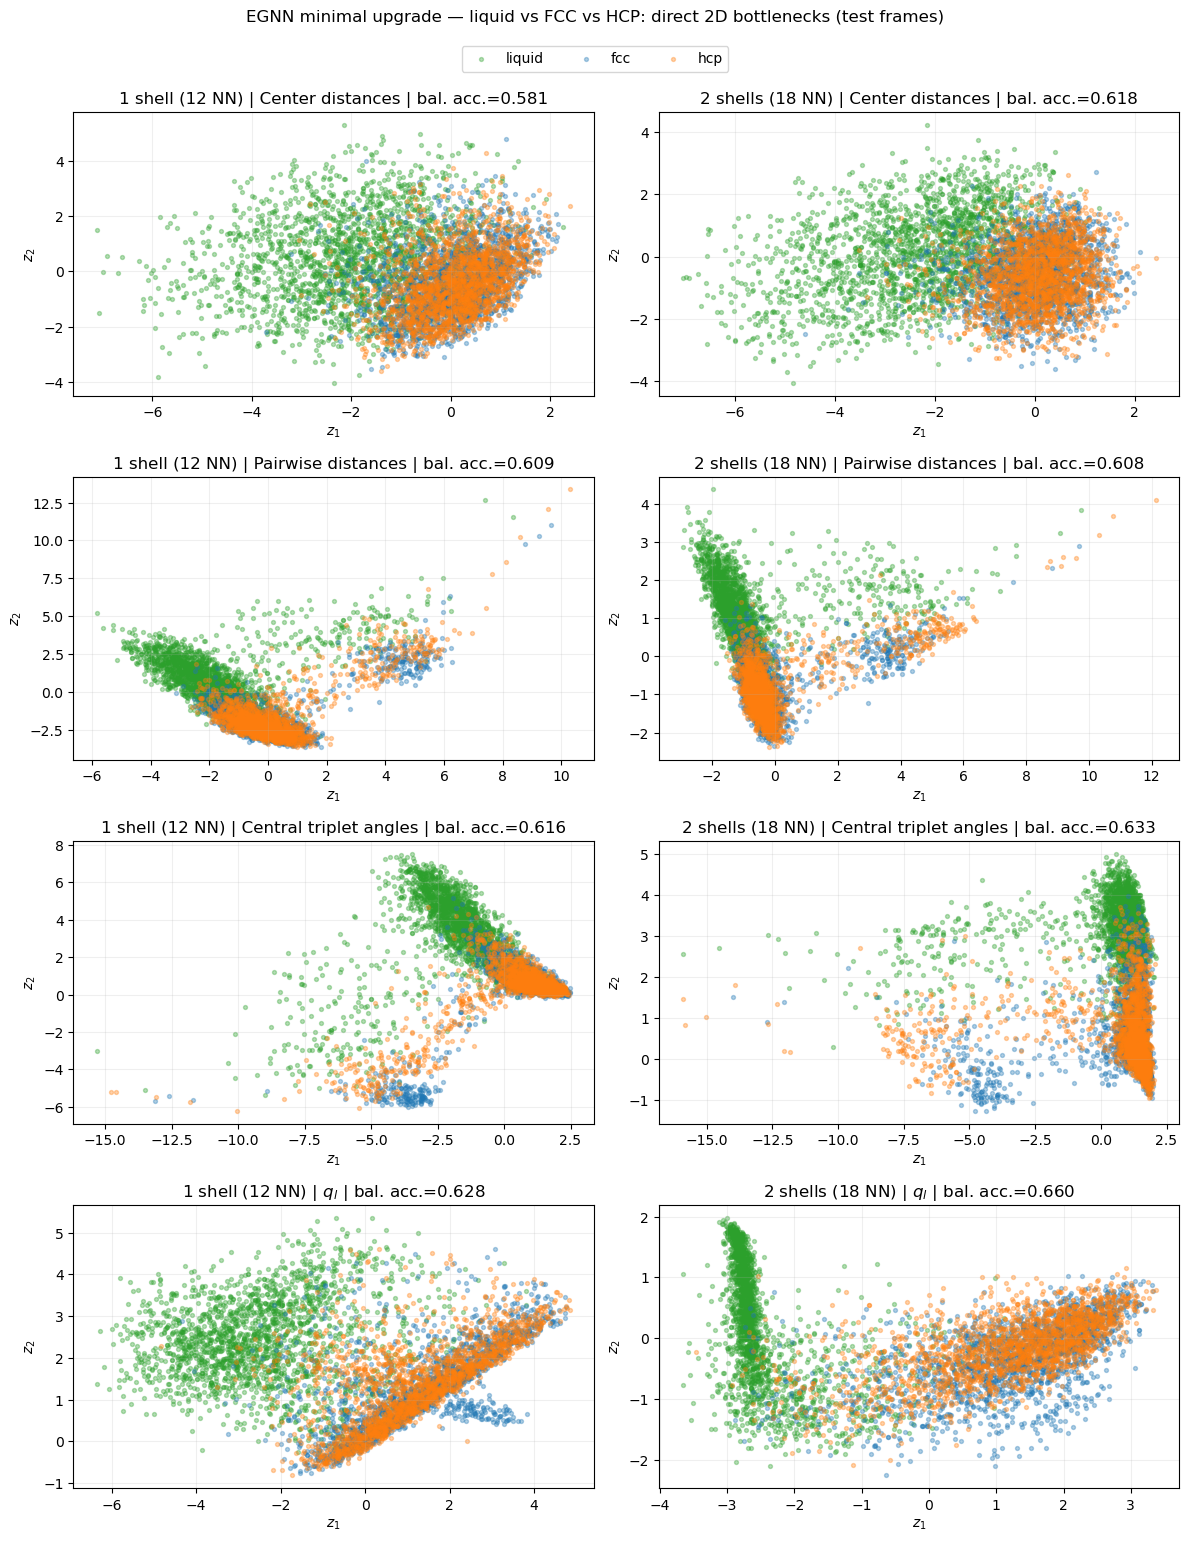

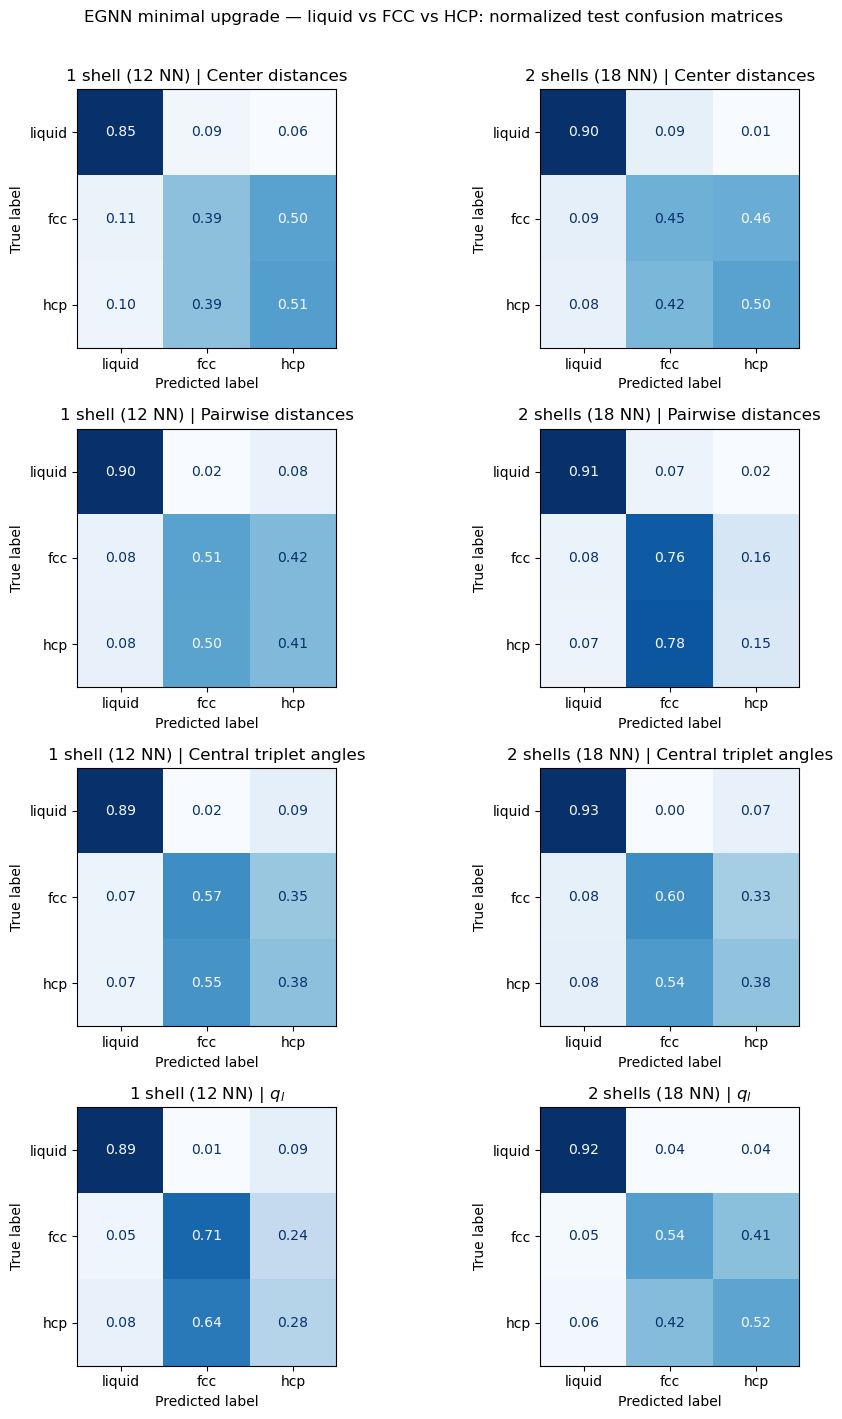

,model,shell_label,target_label,balanced_accuracy,latent_std_1,latent_std_2,latent_abs_correlation,latent_effective_rank
0,minimal upgrade,1 shell (12 NN),$q_l$,0.6284,2.3119,1.1213,0.0749,1.4422
1,original EGNN,1 shell (12 NN),$q_l$,0.5857,0.4193,2.5363,0.9972,1.0003
2,minimal upgrade,2 shells (18 NN),$q_l$,0.6597,2.0126,0.7381,0.1081,1.2604
3,original EGNN,2 shells (18 NN),$q_l$,0.6265,0.5211,2.6752,0.9752,1.0035
4,minimal upgrade,1 shell (12 NN),Center distances,0.5812,1.4402,1.4052,0.0099,1.9986
5,original EGNN,1 shell (12 NN),Center distances,0.5737,1.8953,1.1042,0.1540,1.5858
6,minimal upgrade,2 shells (18 NN),Center distances,0.6184,1.5635,1.1993,0.0213,1.8734
7,original EGNN,2 shells (18 NN),Center distances,0.5889,1.7691,0.6952,0.9997,1.0001
8,minimal upgrade,1 shell (12 NN),Central triplet angles,0.6158,2.1670,2.3496,0.0136,1.9867
9,original EGNN,1 shell (12 NN),Central triplet angles,0.5297,0.4376,2.4168,0.9551,1.0054


balanced_accuracy                \
model                                     minimal upgrade original EGNN   
target_label           shell_label                                        
$q_l$                  1 shell (12 NN)             0.6284        0.5857   
                       2 shells (18 NN)            0.6597        0.6265   
Center distances       1 shell (12 NN)             0.5812        0.5737   
                       2 shells (18 NN)            0.6184        0.5889   
Central triplet angles 1 shell (12 NN)             0.6158        0.5297   
                       2 shells (18 NN)            0.6327        0.4409   
Pairwise distances     1 shell (12 NN)             0.6086        0.5627   
                       2 shells (18 NN)            0.6076        0.5808   

                                        latent_effective_rank                
model                                         minimal upgrade original EGNN  
target_label           shell_label                                           
$q_l$                  1 shell (12 NN)                 1.4422        1.0003  
                       2 shells (18 NN)                1.2604        1.0035  
Center distances       1 shell (12 NN)                 1.9986        1.5858  
                       2 shells (18 NN)                1.8734        1.0001  
Central triplet angles 1 shell (12 NN)                 1.9867        1.0054  
                       2 shells (18 NN)                1.7728        1.0001  
Pairwise distances     1 shell (12 NN)                 1.9787        1.0025  
                       2 shells (18 NN)                1.9233        1.0016

In [94]:
if RUN_EGNN_MINIMAL_UPGRADE:
    plot_multiclass_latent_grid(
        egnn_v2_artifacts,
        EGNN_TARGET_ORDER,
        EGNN_TARGET_LABELS,
        "EGNN minimal upgrade — liquid vs FCC vs HCP",
    )
    plot_multiclass_confusion_grid(
        egnn_v2_artifacts,
        EGNN_TARGET_ORDER,
        EGNN_TARGET_LABELS,
        "EGNN minimal upgrade — liquid vs FCC vs HCP",
    )

    baseline_usage = {
        key: latent_usage_diagnostics(artifact["Z"])
        for key, artifact in egnn_artifacts.items()
    }
    baseline_rows = []
    for _, row in egnn_scores.iterrows():
        usage = baseline_usage[(row["shell"], row["target"])]
        baseline_rows.append(
            {
                "model": "original EGNN",
                "shell_label": row["shell_label"],
                "target_label": row["target_label"],
                "balanced_accuracy": row["balanced_accuracy"],
                **usage,
            }
        )
    upgraded_rows = [
        {
            "model": "minimal upgrade",
            "shell_label": row["shell_label"],
            "target_label": row["target_label"],
            "balanced_accuracy": row["balanced_accuracy"],
            "latent_std_1": row["latent_std_1"],
            "latent_std_2": row["latent_std_2"],
            "latent_abs_correlation": row["latent_abs_correlation"],
            "latent_effective_rank": row["latent_effective_rank"],
        }
        for _, row in egnn_v2_scores.iterrows()
    ]
    egnn_upgrade_comparison = pd.DataFrame(baseline_rows + upgraded_rows)
    display(
        egnn_upgrade_comparison
        .sort_values(["target_label", "shell_label", "model"])
        .reset_index(drop=True)
        .round(4)
    )

    display(
        egnn_upgrade_comparison.pivot_table(
            index=["target_label", "shell_label"],
            columns="model",
            values=["balanced_accuracy", "latent_effective_rank"],
        ).round(4)
    )

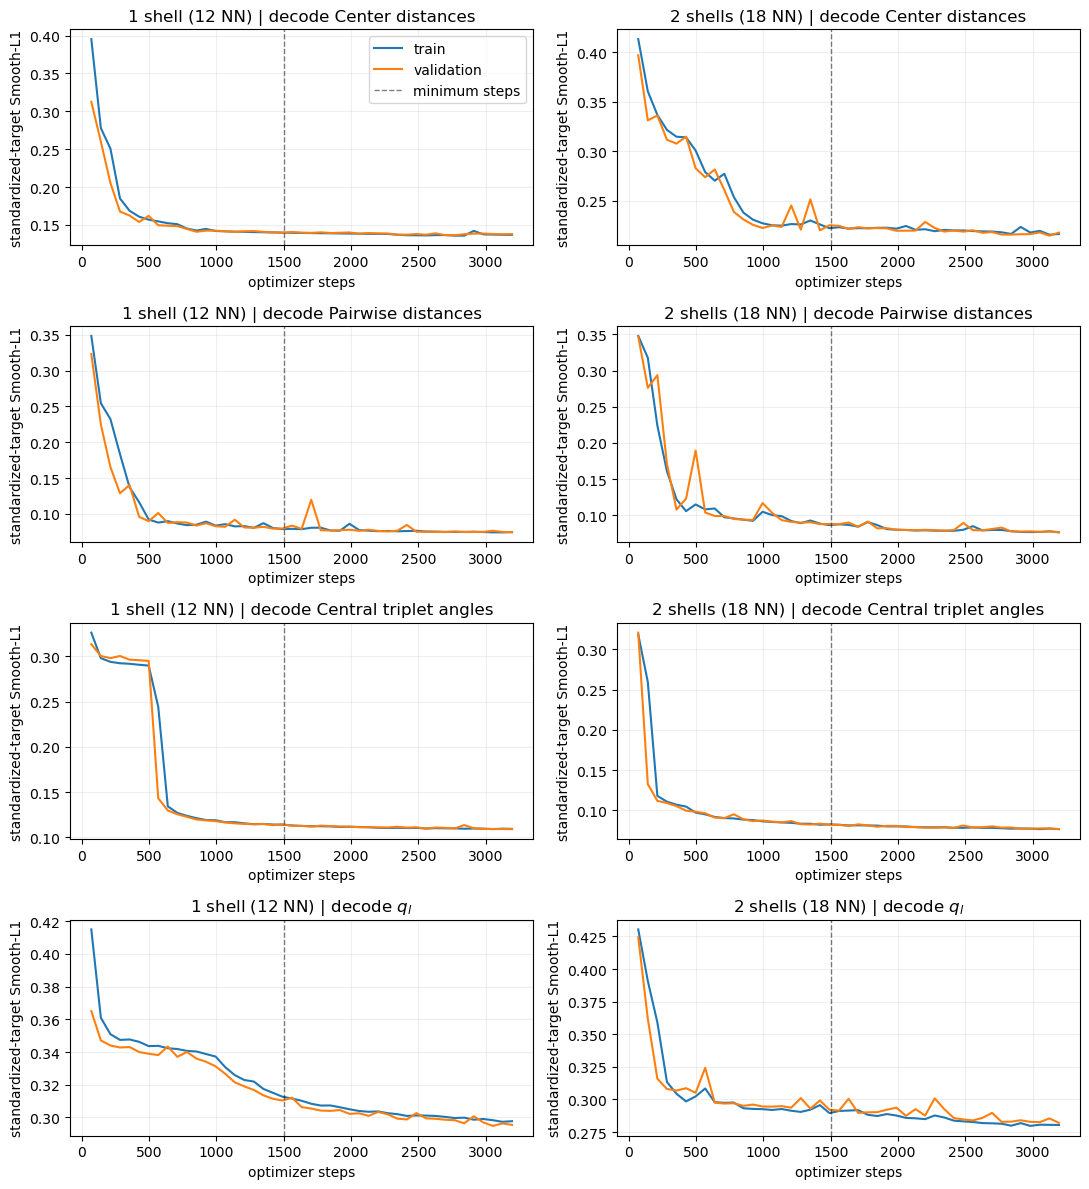

In [95]:
if RUN_EGNN_MINIMAL_UPGRADE:
    fig, axes = plt.subplots(
        len(EGNN_TARGET_ORDER),
        len(SHELL_ORDER),
        figsize=(11, 12),
        squeeze=False,
    )
    for row, target_kind in enumerate(EGNN_TARGET_ORDER):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            history = egnn_v2_artifacts[(shell_name, target_kind)]["history"]
            ax.plot(
                history["optimizer_steps"],
                history["train_reconstruction"],
                label="train",
            )
            ax.plot(
                history["optimizer_steps"],
                history["val_reconstruction"],
                label="validation",
            )
            ax.axvline(
                EGNN_V2_MIN_OPTIMIZER_STEPS,
                color="black",
                linestyle="--",
                linewidth=1,
                alpha=0.5,
                label="minimum steps" if (row, col) == (0, 0) else None,
            )
            ax.set_title(
                f"{SHELL_CONFIG[shell_name]['label']} | "
                f"decode {EGNN_TARGET_LABELS[target_kind]}"
            )
            ax.set_xlabel("optimizer steps")
            ax.set_ylabel("standardized-target Smooth-L1")
            ax.grid(alpha=0.2)
    axes[0, 0].legend()
    plt.tight_layout()
    plt.show()

### How to judge this follow-up

The upgrade succeeds only if it improves held-out balanced accuracy **and** raises the latent effective rank away from 1 without creating a large train/validation gap. A prettier scatter plot alone is not sufficient.

The FCC–HCP first-shell limit remains physical and should not be treated as an implementation bug. The second-shell rows are the more meaningful test. The averaged $q_l$ metadata/input mismatch also remains unchanged; Part V cannot recover information absent from the graph.

## Part VI — Liquid vs FCC with the working EGNN recipe

This is a binary follow-up using the stable recipe from `egnn.ipynb`, while keeping this benchmark's matched one-shell/two-shell data and leakage-safe evaluation. The graph always contains the **neighbor particles only** (12 or 18 fully connected nodes), as in the standalone notebook. Separate decoders reconstruct center distances, center-inclusive pairwise distances, flattened neighbor vectors, or $q_l$.

The port keeps the standalone recipe: constant scalar node inputs, two coordinate-updating EGNN layers, mean pooling, an exact two-dimensional invariant latent, a real-valued MLP decoder, Smooth-L1 reconstruction, rotation-consistency weight $0.1$, Adam at $2\times10^{-4}$, and gradient clipping at 1. The standalone notebook references an undefined `N_LAYERS`; here we use the encoder's intended default of two layers.

Only the evaluation protocol is upgraded: whole simulation frames stay together, the visual seed is followed by the same 30-seed robustness loop used above, and scaling is fitted on training frames only. Geometric targets are divided by the training coordinate scale; $q_l$ is already dimensionless. The vector target is deliberately retained as a negative control: an invariant two-number latent cannot uniquely reconstruct orientation-dependent vectors.

In [96]:
# Working-EGNN liquid-vs-FCC configuration
RUN_WORKING_EGNN_LIQUID_FCC = True
RUN_WORKING_EGNN_LIQUID_FCC_ROBUSTNESS = True

WORKING_EGNN_MAX_SAMPLES_PER_PHASE = 3_000
WORKING_EGNN_EPOCHS = 30
WORKING_EGNN_BATCH_SIZE = 256
WORKING_EGNN_LEARNING_RATE = 2e-4
WORKING_EGNN_WEIGHT_DECAY = 1e-6
WORKING_EGNN_ROTATION_WEIGHT = 0.1
WORKING_EGNN_FEATURE_DIM = 48
WORKING_EGNN_N_LAYERS = 2
WORKING_EGNN_COORD_UPDATE_SCALE = 0.05
WORKING_EGNN_GRAD_CLIP = 1.0
WORKING_EGNN_LATENT_DIM = 2
WORKING_EGNN_TARGET_ORDER = FEATURE_ORDER
WORKING_EGNN_TARGET_LABELS = FEATURE_LABELS

if os.environ.get("AE_SMOKE_TEST") == "1":
    WORKING_EGNN_MAX_SAMPLES_PER_PHASE = 256
    WORKING_EGNN_EPOCHS = 2

print("Working-EGNN liquid/FCC enabled:", RUN_WORKING_EGNN_LIQUID_FCC)
print("Working-EGNN robustness enabled:", RUN_WORKING_EGNN_LIQUID_FCC_ROBUSTNESS)
print("Working-EGNN samples per phase:", WORKING_EGNN_MAX_SAMPLES_PER_PHASE)
print("Working-EGNN robustness seeds:", len(ROBUSTNESS_SEEDS))

Working-EGNN liquid/FCC enabled: True
Working-EGNN robustness enabled: True
Working-EGNN samples per phase: 3000
Working-EGNN robustness seeds: 30


In [97]:
def working_egnn_random_rotation_matrix(batch_size, device, dtype):
    """Uniform random proper rotations, matching the standalone EGNN notebook."""
    u1 = torch.rand(batch_size, device=device, dtype=dtype)
    u2 = torch.rand(batch_size, device=device, dtype=dtype)
    u3 = torch.rand(batch_size, device=device, dtype=dtype)

    q1 = torch.sqrt(1 - u1) * torch.sin(2 * torch.pi * u2)
    q2 = torch.sqrt(1 - u1) * torch.cos(2 * torch.pi * u2)
    q3 = torch.sqrt(u1) * torch.sin(2 * torch.pi * u3)
    q4 = torch.sqrt(u1) * torch.cos(2 * torch.pi * u3)

    rotations = torch.zeros(
        batch_size, 3, 3, device=device, dtype=dtype
    )
    rotations[:, 0, 0] = 1 - 2 * (q3.square() + q4.square())
    rotations[:, 0, 1] = 2 * (q2 * q3 - q1 * q4)
    rotations[:, 0, 2] = 2 * (q2 * q4 + q1 * q3)
    rotations[:, 1, 0] = 2 * (q2 * q3 + q1 * q4)
    rotations[:, 1, 1] = 1 - 2 * (q2.square() + q4.square())
    rotations[:, 1, 2] = 2 * (q3 * q4 - q1 * q2)
    rotations[:, 2, 0] = 2 * (q2 * q4 - q1 * q3)
    rotations[:, 2, 1] = 2 * (q3 * q4 + q1 * q2)
    rotations[:, 2, 2] = 1 - 2 * (q2.square() + q3.square())
    return rotations


def working_egnn_random_rotate(coordinates):
    rotations = working_egnn_random_rotation_matrix(
        len(coordinates), coordinates.device, coordinates.dtype
    )
    return torch.einsum("bij,bnj->bni", rotations, coordinates)


class WorkingEGNNLayer(nn.Module):
    """The coordinate-updating layer used by the standalone working EGNN."""
    def __init__(self):
        super().__init__()
        width = WORKING_EGNN_FEATURE_DIM
        self.edge_mlp = EGNNMLP([2 * width + 1, width, width, width])
        self.coordinate_mlp = EGNNMLP([width, width, 1])
        self.node_mlp = EGNNMLP([2 * width, width, width])

    def forward(self, node_features, coordinates, edge_index):
        row, col = edge_index
        relative = coordinates[:, row, :] - coordinates[:, col, :]
        squared_distance = relative.square().sum(dim=-1, keepdim=True)
        messages = self.edge_mlp(
            torch.cat(
                [
                    node_features[:, row, :],
                    node_features[:, col, :],
                    squared_distance,
                ],
                dim=-1,
            )
        )

        coordinate_coefficients = torch.tanh(self.coordinate_mlp(messages))
        coordinate_updates = torch.zeros_like(coordinates)
        coordinate_updates.index_add_(
            1, row, relative * coordinate_coefficients
        )
        coordinates = (
            coordinates
            + WORKING_EGNN_COORD_UPDATE_SCALE
            * coordinate_updates
            / max(1, coordinates.shape[1] - 1)
        )

        aggregated = torch.zeros(
            node_features.shape[0],
            node_features.shape[1],
            messages.shape[-1],
            device=node_features.device,
            dtype=node_features.dtype,
        )
        aggregated.index_add_(1, row, messages)
        node_features = node_features + self.node_mlp(
            torch.cat([node_features, aggregated], dim=-1)
        )
        return node_features, coordinates


class WorkingEGNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        width = WORKING_EGNN_FEATURE_DIM
        self.node_embedding = nn.Linear(1, width)
        self.layers = nn.ModuleList(
            [WorkingEGNNLayer() for _ in range(WORKING_EGNN_N_LAYERS)]
        )
        self.to_latent = EGNNMLP(
            [width, width, width, WORKING_EGNN_LATENT_DIM]
        )

    def forward(self, coordinates, edge_index):
        node_features = self.node_embedding(
            torch.ones(
                coordinates.shape[0],
                coordinates.shape[1],
                1,
                device=coordinates.device,
                dtype=coordinates.dtype,
            )
        )
        updated_coordinates = coordinates
        for layer in self.layers:
            node_features, updated_coordinates = layer(
                node_features, updated_coordinates, edge_index
            )
        return self.to_latent(node_features.mean(dim=1))


class WorkingEGNNDecoder(nn.Module):
    def __init__(self, output_dim):
        super().__init__()
        width = WORKING_EGNN_FEATURE_DIM
        self.network = EGNNMLP(
            [WORKING_EGNN_LATENT_DIM, width, width, width, output_dim]
        )

    def forward(self, latent):
        return self.network(latent)


class WorkingEGNNAutoencoder(nn.Module):
    def __init__(self, output_dim):
        super().__init__()
        self.encoder = WorkingEGNNEncoder()
        self.decoder = WorkingEGNNDecoder(output_dim)

    def encode(self, coordinates, edge_index):
        return self.encoder(coordinates, edge_index)

    def forward(self, coordinates, edge_index):
        latent = self.encode(coordinates, edge_index)
        return self.decoder(latent), latent

In [98]:
def build_working_egnn_liquid_fcc_plan(seed):
    """Balanced sampling with the benchmark's whole-frame split."""
    rng = np.random.default_rng(seed)
    n_per_phase = min(
        WORKING_EGNN_MAX_SAMPLES_PER_PHASE,
        *(len(shell_data["first_shell"][phase]["dist"]) for phase in PHASES),
    )
    plan = {}
    for phase in PHASES:
        reference = shell_data["first_shell"][phase]
        indices = np.sort(
            rng.choice(len(reference["dist"]), size=n_per_phase, replace=False)
        )
        plan[phase] = {
            "indices": indices,
            "split": _frame_split(reference["frame_indices"][indices], rng),
        }
    return plan


def prepare_working_egnn_liquid_fcc(shell_name, target_kind, plan):
    coordinate_parts, target_parts, label_parts, split_parts = [], [], [], []
    for phase in PHASES:
        entry = plan[phase]
        data = shell_data[shell_name][phase]
        coordinate_parts.append(data["vec_dist"][entry["indices"]].copy())
        target_parts.append(build_feature(data, target_kind, entry["indices"]))
        label_parts.append(
            np.full(len(entry["indices"]), LABEL_MAP[phase], dtype=np.int64)
        )
        split_parts.append(entry["split"])
    return (
        np.concatenate(coordinate_parts).astype(np.float32, copy=False),
        np.concatenate(target_parts).astype(np.float32, copy=False),
        np.concatenate(label_parts),
        np.concatenate(split_parts),
    )


def working_egnn_validation_stats(model, loader, edge_index):
    model.eval()
    totals = {"total": 0.0, "reconstruction": 0.0, "invariance": 0.0}
    count = 0
    with torch.no_grad():
        for coordinate_batch, target_batch in loader:
            coordinate_batch = coordinate_batch.to(DEVICE)
            target_batch = target_batch.to(DEVICE)
            prediction, latent = model(coordinate_batch, edge_index)
            rotated_latent = model.encode(
                working_egnn_random_rotate(coordinate_batch), edge_index
            )
            reconstruction = nn.functional.smooth_l1_loss(
                prediction, target_batch
            )
            invariance = nn.functional.mse_loss(latent, rotated_latent)
            total = (
                reconstruction
                + WORKING_EGNN_ROTATION_WEIGHT * invariance
            )
            batch_size = len(coordinate_batch)
            totals["total"] += total.item() * batch_size
            totals["reconstruction"] += reconstruction.item() * batch_size
            totals["invariance"] += invariance.item() * batch_size
            count += batch_size
    return {key: value / count for key, value in totals.items()}


def train_working_egnn_liquid_fcc(
    coordinates, targets, split, target_kind, seed
):
    set_seed(seed)
    train_mask = split == "train"
    val_mask = split == "val"
    test_mask = split == "test"

    training_radii = np.linalg.norm(coordinates[train_mask], axis=-1)
    coordinate_scale = float(np.median(training_radii))
    if not np.isfinite(coordinate_scale) or coordinate_scale <= 0:
        coordinate_scale = 1.0
    scaled_coordinates = (coordinates / coordinate_scale).astype(np.float32)

    # Match the standalone setup: geometric targets use the coordinate units;
    # dimensionless q_l values are reconstructed without an additional scaler.
    if target_kind in ("radii", "pairwise_distances", "vectors"):
        scaled_targets = (targets / coordinate_scale).astype(np.float32)
    else:
        scaled_targets = targets.astype(np.float32, copy=True)

    train_coordinates = torch.from_numpy(scaled_coordinates[train_mask])
    train_targets = torch.from_numpy(scaled_targets[train_mask])
    val_coordinates = torch.from_numpy(scaled_coordinates[val_mask])
    val_targets = torch.from_numpy(scaled_targets[val_mask])
    generator = torch.Generator().manual_seed(seed)

    train_loader = DataLoader(
        TensorDataset(train_coordinates, train_targets),
        batch_size=WORKING_EGNN_BATCH_SIZE,
        shuffle=True,
        generator=generator,
        num_workers=0,
    )
    val_loader = DataLoader(
        TensorDataset(val_coordinates, val_targets),
        batch_size=WORKING_EGNN_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )

    edge_index = fully_connected_edge_index(scaled_coordinates.shape[1]).to(DEVICE)
    model = WorkingEGNNAutoencoder(scaled_targets.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=WORKING_EGNN_LEARNING_RATE,
        weight_decay=WORKING_EGNN_WEIGHT_DECAY,
    )
    history = {
        "train_total": [],
        "train_reconstruction": [],
        "train_invariance": [],
        "val_total": [],
        "val_reconstruction": [],
        "val_invariance": [],
    }
    best_state = None
    best_val = np.inf
    best_epoch = -1

    for epoch in range(WORKING_EGNN_EPOCHS):
        model.train()
        totals = {"total": 0.0, "reconstruction": 0.0, "invariance": 0.0}
        count = 0
        for coordinate_batch, target_batch in train_loader:
            coordinate_batch = coordinate_batch.to(DEVICE)
            target_batch = target_batch.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            prediction, latent = model(coordinate_batch, edge_index)
            rotated_latent = model.encode(
                working_egnn_random_rotate(coordinate_batch), edge_index
            )
            reconstruction = nn.functional.smooth_l1_loss(
                prediction, target_batch
            )
            invariance = nn.functional.mse_loss(latent, rotated_latent)
            loss = (
                reconstruction
                + WORKING_EGNN_ROTATION_WEIGHT * invariance
            )
            if not torch.isfinite(loss):
                raise FloatingPointError("Non-finite working-EGNN loss")
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), WORKING_EGNN_GRAD_CLIP
            )
            optimizer.step()

            batch_size = len(coordinate_batch)
            totals["total"] += loss.item() * batch_size
            totals["reconstruction"] += reconstruction.item() * batch_size
            totals["invariance"] += invariance.item() * batch_size
            count += batch_size

        train_stats = {key: value / count for key, value in totals.items()}
        val_stats = working_egnn_validation_stats(model, val_loader, edge_index)
        for key in ("total", "reconstruction", "invariance"):
            history[f"train_{key}"].append(train_stats[key])
            history[f"val_{key}"].append(val_stats[key])

        if val_stats["total"] < best_val:
            best_val = val_stats["total"]
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())

        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(
                f"epoch={epoch + 1:02d} "
                f"train={train_stats['total']:.5f} "
                f"val={val_stats['total']:.5f}"
            )

    model.load_state_dict(best_state)
    model.eval()
    latent_chunks = []
    test_reconstruction_sum = 0.0
    test_sample_count = 0
    with torch.no_grad():
        for start in range(0, len(scaled_coordinates), WORKING_EGNN_BATCH_SIZE):
            stop = min(start + WORKING_EGNN_BATCH_SIZE, len(scaled_coordinates))
            coordinate_batch = torch.from_numpy(
                scaled_coordinates[start:stop]
            ).to(DEVICE)
            target_batch = torch.from_numpy(scaled_targets[start:stop]).to(DEVICE)
            prediction, latent = model(coordinate_batch, edge_index)
            latent_chunks.append(latent.cpu().numpy())

            local_test = test_mask[start:stop]
            if np.any(local_test):
                torch_mask = torch.from_numpy(local_test).to(DEVICE)
                test_reconstruction_sum += nn.functional.smooth_l1_loss(
                    prediction[torch_mask],
                    target_batch[torch_mask],
                ).item() * int(local_test.sum())
                test_sample_count += int(local_test.sum())

        audit_indices = np.flatnonzero(test_mask)[:512]
        audit_coordinates = torch.from_numpy(
            scaled_coordinates[audit_indices]
        ).to(DEVICE)
        audit_latent = model.encode(audit_coordinates, edge_index)
        audit_rotated_latent = model.encode(
            working_egnn_random_rotate(audit_coordinates), edge_index
        )
        rotation_delta = torch.linalg.norm(
            audit_latent - audit_rotated_latent, dim=1
        ).mean().item()

    return {
        "model": model,
        "coordinate_scale": coordinate_scale,
        "edge_index": edge_index,
        "history": history,
        "Z": np.concatenate(latent_chunks),
        "best_epoch": best_epoch + 1,
        "best_val_loss": float(best_val),
        "test_reconstruction_loss": test_reconstruction_sum / test_sample_count,
        "mean_rotation_delta": rotation_delta,
    }

In [99]:
def run_working_egnn_liquid_fcc_suite(
    seed=VISUAL_SEED,
    keep_artifacts=True,
    verbose=True,
):
    plan = build_working_egnn_liquid_fcc_plan(seed)
    rows = []
    artifacts = {}

    for shell_name in SHELL_ORDER:
        shell_cfg = SHELL_CONFIG[shell_name]
        ql_exact = all(
            shell_data[shell_name][phase]["ql_exact"] for phase in PHASES
        )
        for target_kind in WORKING_EGNN_TARGET_ORDER:
            if verbose:
                print(
                    f"working EGNN seed={seed:>3} | "
                    f"{shell_cfg['label']:<18} | "
                    f"decode {WORKING_EGNN_TARGET_LABELS[target_kind]}"
                )
            coordinates, targets, y, split = prepare_working_egnn_liquid_fcc(
                shell_name, target_kind, plan
            )
            trained = train_working_egnn_liquid_fcc(
                coordinates, targets, split, target_kind, seed
            )
            probe = probe_latent(trained["Z"], y, split, seed)

            rows.append(
                {
                    "seed": seed,
                    "shell": shell_name,
                    "shell_label": shell_cfg["label"],
                    "n_neighbors": shell_cfg["n_neighbors"],
                    "n_graph_nodes": coordinates.shape[1],
                    "feature": target_kind,
                    "feature_label": WORKING_EGNN_TARGET_LABELS[target_kind],
                    "target_dim": targets.shape[1],
                    "latent_dim": trained["Z"].shape[1],
                    "n_samples": len(y),
                    "best_epoch": trained["best_epoch"],
                    "validation_loss": trained["best_val_loss"],
                    "test_reconstruction_loss": trained[
                        "test_reconstruction_loss"
                    ],
                    "mean_rotation_delta": trained["mean_rotation_delta"],
                    "accuracy": probe["accuracy"],
                    "balanced_accuracy": probe["balanced_accuracy"],
                    "macro_f1": probe["macro_f1"],
                    "roc_auc": probe["roc_auc"],
                    "q_l_variant": (
                        shell_cfg["ql_variant"] if target_kind == "ql" else pd.NA
                    ),
                    "q_l_exact_requested_NN": (
                        ql_exact if target_kind == "ql" else pd.NA
                    ),
                }
            )
            if keep_artifacts:
                artifacts[(shell_name, target_kind)] = {
                    "Z": trained["Z"],
                    "y": y,
                    "split": split,
                    "history": trained["history"],
                    "model": trained["model"],
                    "coordinate_scale": trained["coordinate_scale"],
                    "edge_index": trained["edge_index"],
                    "probe": probe,
                }

            del coordinates, targets, trained
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return pd.DataFrame(rows), artifacts, plan

### Main two-dimensional run

The visual run shows the raw two-dimensional test latent, its held-out confusion matrix, and training curves for every target/shell combination.

In [100]:
if RUN_WORKING_EGNN_LIQUID_FCC:
    working_egnn_lf_scores, working_egnn_lf_artifacts, working_egnn_lf_plan = (
        run_working_egnn_liquid_fcc_suite(
            VISUAL_SEED,
            keep_artifacts=True,
            verbose=True,
        )
    )
    display(summarize_plan(working_egnn_lf_plan))
    display(
        working_egnn_lf_scores[
            [
                "shell_label",
                "feature_label",
                "target_dim",
                "best_epoch",
                "test_reconstruction_loss",
                "mean_rotation_delta",
                "balanced_accuracy",
                "macro_f1",
                "roc_auc",
                "q_l_exact_requested_NN",
            ]
        ]
        .sort_values(["feature_label", "shell_label"])
        .reset_index(drop=True)
        .round(4)
    )

working EGNN seed= 42 | 1 shell (12 NN)    | decode Center distances
epoch=01 train=0.49147 val=0.47967
epoch=05 train=0.07222 val=0.03123
epoch=10 train=0.00100 val=0.00099
epoch=15 train=0.00097 val=0.00098
epoch=20 train=0.00097 val=0.00097
epoch=25 train=0.00097 val=0.00100
epoch=30 train=0.00096 val=0.00097
working EGNN seed= 42 | 1 shell (12 NN)    | decode Pairwise distances
epoch=01 train=0.89605 val=0.88551
epoch=05 train=0.45340 val=0.31285
epoch=10 train=0.00409 val=0.00375
epoch=15 train=0.00311 val=0.00339
epoch=20 train=0.00295 val=0.00339
epoch=25 train=0.00280 val=0.00302
epoch=30 train=0.00260 val=0.00284
working EGNN seed= 42 | 1 shell (12 NN)    | decode Neighbor vectors
epoch=01 train=0.17742 val=0.17629
epoch=05 train=0.17449 val=0.17376
epoch=10 train=0.17373 val=0.17338
epoch=15 train=0.17371 val=0.17337
epoch=20 train=0.17371 val=0.17337
epoch=25 train=0.17371 val=0.17338
epoch=30 train=0.17371 val=0.17337
working EGNN seed= 42 | 1 shell (12 NN)    | decode $q_l

,phase,partition,particles,frames
0,liquid,train,1808,181
1,liquid,val,570,60
2,liquid,test,622,60
3,fcc,train,1795,359
4,fcc,val,585,120
5,fcc,test,620,120


,shell_label,feature_label,target_dim,best_epoch,test_reconstruction_loss,mean_rotation_delta,balanced_accuracy,macro_f1,roc_auc,q_l_exact_requested_NN
0,1 shell (12 NN),$q_l$,20,28,0.0013,0.0,0.8043,0.8043,0.8571,True
1,2 shells (18 NN),$q_l$,20,30,0.0015,0.0,0.8196,0.8196,0.8622,False
2,1 shell (12 NN),Center distances,12,28,0.0010,0.0,0.8035,0.8035,0.8570,<NA>
3,2 shells (18 NN),Center distances,18,26,0.0009,0.0,0.8124,0.8122,0.8610,<NA>
4,1 shell (12 NN),Neighbor vectors,36,26,0.1738,0.0,0.8051,0.8051,0.8577,<NA>
5,2 shells (18 NN),Neighbor vectors,54,26,0.1958,0.0,0.8124,0.8124,0.8618,<NA>
6,1 shell (12 NN),Pairwise distances,78,30,0.0026,0.0,0.7987,0.7986,0.8550,<NA>
7,2 shells (18 NN),Pairwise distances,171,30,0.0021,0.0,0.8197,0.8195,0.8644,<NA>


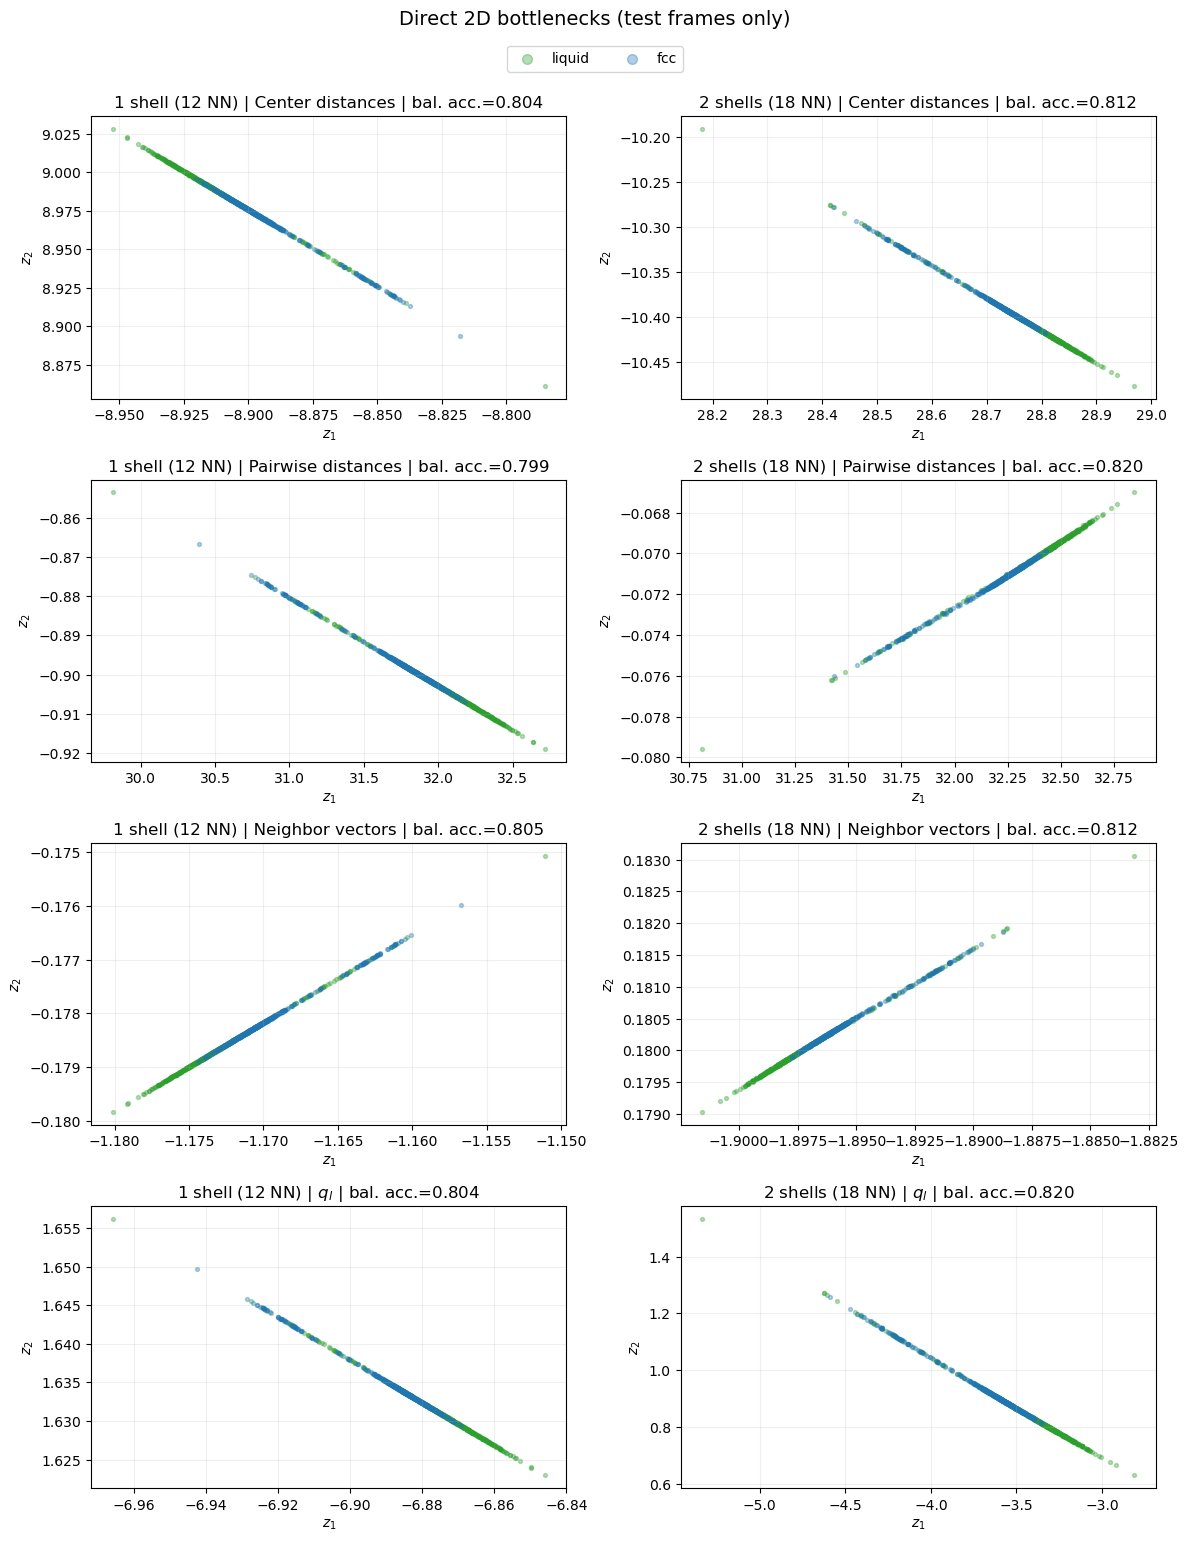

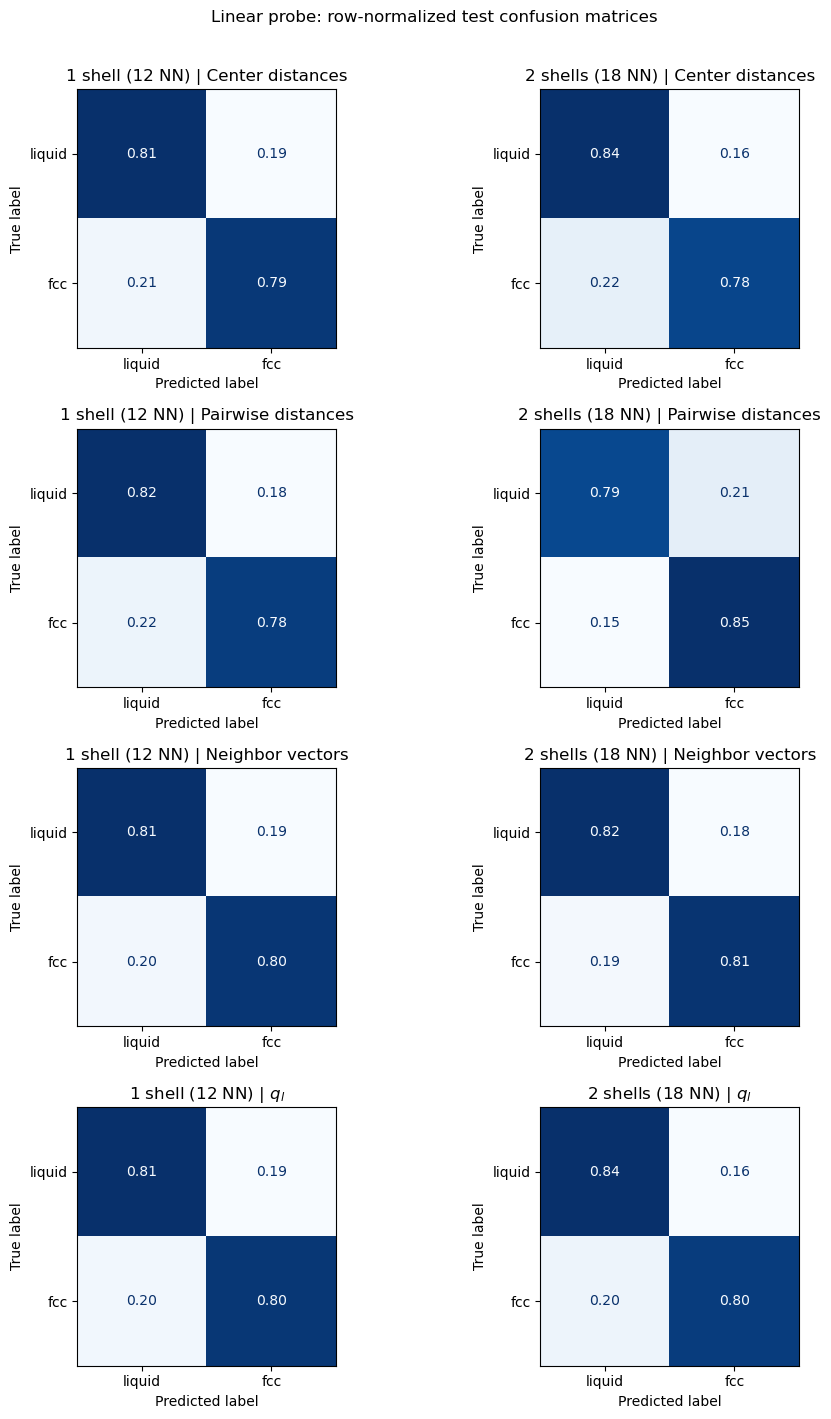

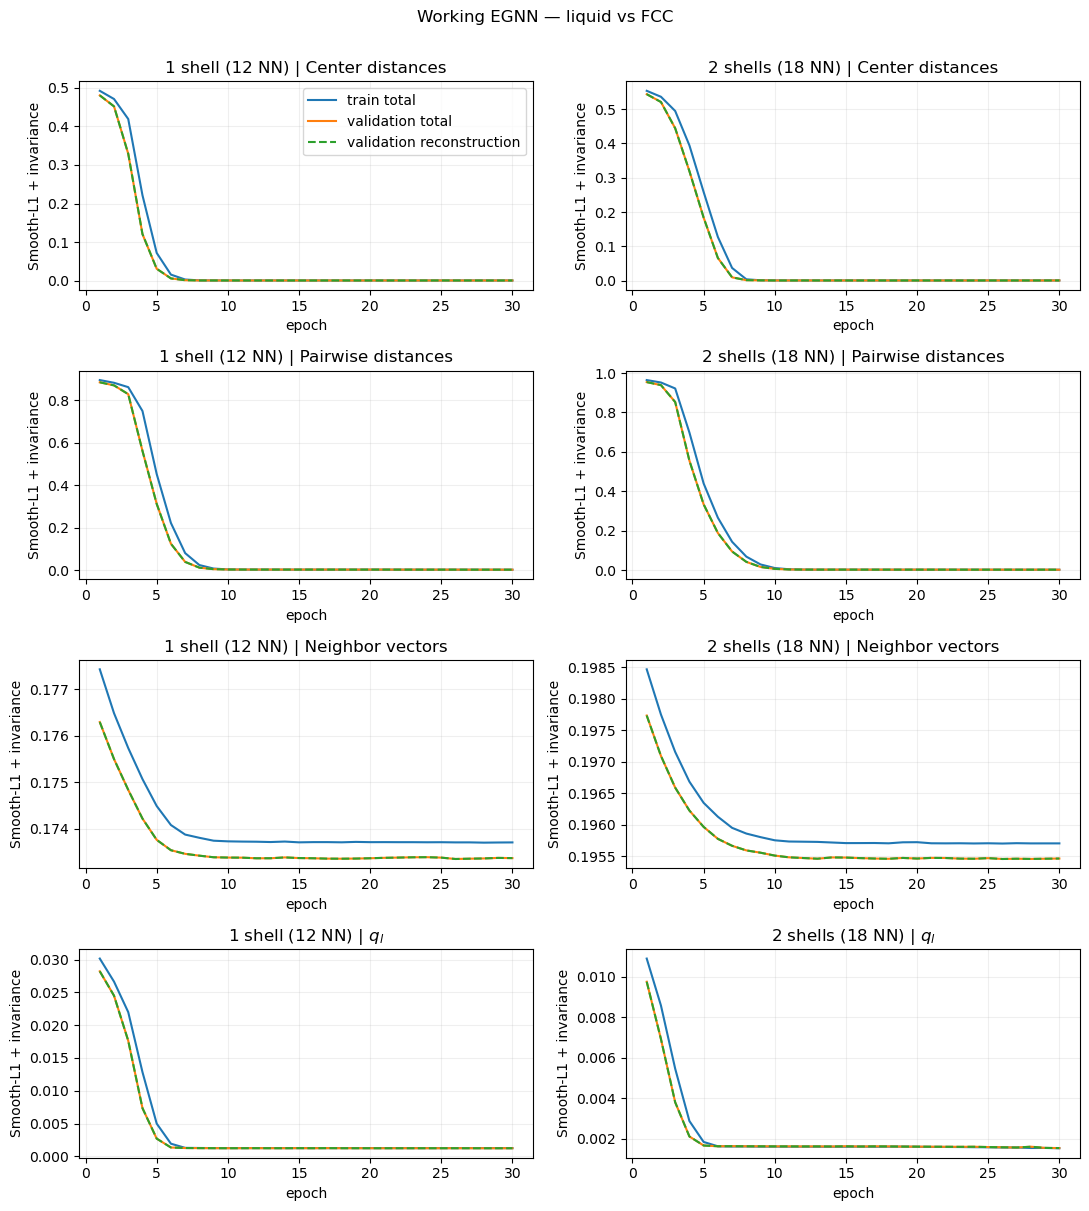

In [101]:
if RUN_WORKING_EGNN_LIQUID_FCC:
    plot_latent_grid(working_egnn_lf_artifacts, split_to_plot="test")
    plot_confusion_grid(working_egnn_lf_artifacts)

    fig, axes = plt.subplots(
        len(WORKING_EGNN_TARGET_ORDER),
        len(SHELL_ORDER),
        figsize=(11, 12),
        squeeze=False,
    )
    for row, target_kind in enumerate(WORKING_EGNN_TARGET_ORDER):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            history = working_egnn_lf_artifacts[
                (shell_name, target_kind)
            ]["history"]
            epochs = np.arange(1, len(history["train_total"]) + 1)
            ax.plot(epochs, history["train_total"], label="train total")
            ax.plot(epochs, history["val_total"], label="validation total")
            ax.plot(
                epochs,
                history["val_reconstruction"],
                linestyle="--",
                label="validation reconstruction",
            )
            ax.set_title(
                f"{SHELL_CONFIG[shell_name]['label']} | "
                f"{WORKING_EGNN_TARGET_LABELS[target_kind]}"
            )
            ax.set_xlabel("epoch")
            ax.set_ylabel("Smooth-L1 + invariance")
            ax.grid(alpha=0.2)
    axes[0, 0].legend()
    fig.suptitle("Working EGNN — liquid vs FCC", y=1.005)
    plt.tight_layout()
    plt.show()

### Probe robustness across 30 seeds

This is the same robustness protocol as the earlier simple-autoencoder experiments: one complete run for every seed, with all eight target/shell combinations retrained from scratch. At full settings this is **240 EGNN fits**, so it is intentionally expensive. `AE_SMOKE_TEST=1` reduces it to two seeds and two epochs for code validation.

Working-EGNN liquid/FCC robustness run for seed 0
epoch=01 train=0.50750 val=0.49860
epoch=05 train=0.21085 val=0.12020
epoch=10 train=0.00109 val=0.00101
epoch=15 train=0.00100 val=0.00098
epoch=20 train=0.00100 val=0.00097
epoch=25 train=0.00099 val=0.00097
epoch=30 train=0.00099 val=0.00097
epoch=01 train=0.86757 val=0.86258
epoch=05 train=0.72129 val=0.51780
epoch=10 train=0.01119 val=0.00676
epoch=15 train=0.00297 val=0.00280
epoch=20 train=0.00292 val=0.00275
epoch=25 train=0.00286 val=0.00281
epoch=30 train=0.00280 val=0.00270
epoch=01 train=0.17783 val=0.17754
epoch=05 train=0.17395 val=0.17404
epoch=10 train=0.17364 val=0.17385
epoch=15 train=0.17364 val=0.17384
epoch=20 train=0.17364 val=0.17385
epoch=25 train=0.17365 val=0.17383
epoch=30 train=0.17365 val=0.17386
epoch=01 train=0.04485 val=0.04238
epoch=05 train=0.00436 val=0.00251
epoch=10 train=0.00127 val=0.00125
epoch=15 train=0.00127 val=0.00125
epoch=20 train=0.00127 val=0.00125
epoch=25 train=0.00127 val=0.00125
epoch

,,mean,std,median,min,max
feature_label,shell_label,,,,,
Center distances,1 shell (12 NN),0.8185,0.0101,0.8191,0.8017,0.8376
Pairwise distances,1 shell (12 NN),0.8183,0.0106,0.8193,0.7987,0.8367
Neighbor vectors,1 shell (12 NN),0.8238,0.0189,0.8219,0.8045,0.9086
$q_l$,1 shell (12 NN),0.8219,0.0155,0.8208,0.7985,0.8753
Center distances,2 shells (18 NN),0.8108,0.0123,0.8110,0.7792,0.8398
Pairwise distances,2 shells (18 NN),0.8109,0.0126,0.8114,0.7792,0.8398
Neighbor vectors,2 shells (18 NN),0.8110,0.0115,0.8123,0.7808,0.8390
$q_l$,2 shells (18 NN),0.8126,0.0129,0.8122,0.7783,0.8399


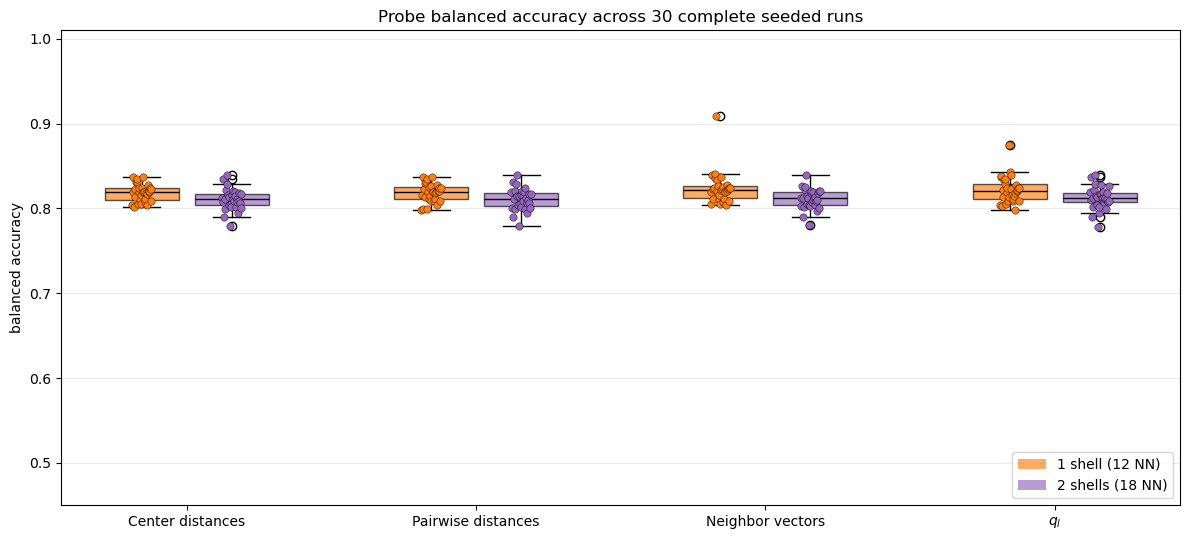

mean                              std  \
shell_label        1 shell (12 NN) 2 shells (18 NN) 1 shell (12 NN)   
feature_label                                                         
$q_l$                       0.8219           0.8126          0.0155   
Center distances            0.8185           0.8108          0.0101   
Neighbor vectors            0.8238           0.8110          0.0189   
Pairwise distances          0.8183           0.8109          0.0106   

                                     
shell_label        2 shells (18 NN)  
feature_label                        
$q_l$                        0.0129  
Center distances             0.0123  
Neighbor vectors             0.0115  
Pairwise distances           0.0126

In [102]:
if (
    RUN_WORKING_EGNN_LIQUID_FCC
    and RUN_WORKING_EGNN_LIQUID_FCC_ROBUSTNESS
):
    working_egnn_lf_score_frames = [working_egnn_lf_scores]
    for seed in ROBUSTNESS_SEEDS:
        if seed == VISUAL_SEED:
            continue
        print(f"Working-EGNN liquid/FCC robustness run for seed {seed}")
        seeded_scores, _, _ = run_working_egnn_liquid_fcc_suite(
            seed,
            keep_artifacts=False,
            verbose=False,
        )
        working_egnn_lf_score_frames.append(seeded_scores)

    working_egnn_lf_robustness_scores = pd.concat(
        working_egnn_lf_score_frames,
        ignore_index=True,
    )
    expected_seed_count = len(set(ROBUSTNESS_SEEDS))
    actual_seed_count = working_egnn_lf_robustness_scores["seed"].nunique()
    if actual_seed_count != expected_seed_count:
        raise RuntimeError(
            f"Expected {expected_seed_count} seeds, got {actual_seed_count}."
        )

    working_egnn_lf_robustness_summary = (
        working_egnn_lf_robustness_scores
        .groupby(["feature_label", "shell_label"], sort=False)[
            "balanced_accuracy"
        ]
        .agg(["mean", "std", "median", "min", "max"])
    )
    display(working_egnn_lf_robustness_summary.round(4))
    plot_robustness_boxplots(
        working_egnn_lf_robustness_scores,
        metric="balanced_accuracy",
    )
    display(
        working_egnn_lf_robustness_scores.pivot_table(
            index="feature_label",
            columns="shell_label",
            values="balanced_accuracy",
            aggfunc=["mean", "std"],
        ).round(4)
    )

### Reading the result

The probe distribution is the primary comparison; reconstruction loss is target-dependent and should not be ranked across descriptor types. Compare shells within each target and compare the 30-seed spread with the earlier simple-AE boxplots. Expect the vector reconstruction to be the weakest or least stable row because rotation consistency removes precisely the orientation information its decoder requests.

## Part VII — Reconstruction-driven coordinate EGNN

### What was tried, what happened, and why this experiment replaces V4

The first liquid–FCC EGNN produced a strongly line-like two-dimensional latent space: one coordinate carried nearly all of the variation while the other was barely used. Four small anti-collapse variants were then screened. V1 and V2 retained mean pooling and added weak or stronger variance/correlation penalties; neither reliably opened the latent into two dimensions. V3 changed the graph readout to mean plus maximum, and V4 changed it to mean plus nodewise standard deviation. Both also retained the latent-shape penalties.

V3 and V4 sometimes made the scatter plot look more cloud-like, but this did not resolve the scientific problem. Their liquid–FCC probe accuracies were almost identical for center distances, pairwise distances, vectors, and $q_l$, even though these are different reconstruction tasks. In the completed V4 runs, the weighted variance/correlation contribution was also commonly larger than the scalar reconstruction loss for the invariant targets. The encoder was therefore being directed substantially by the chosen pooling statistics and by the instruction to occupy a two-dimensional cloud, rather than primarily by the information needed by the decoder. The poor and unstable two-shell result made this especially visible. A large vector loss does not contradict this conclusion: absolute vectors cannot be reconstructed uniquely from an invariant latent, so the decoder can remain poor without providing a useful orientation-resolving signal to the encoder.

V1–V4 are consequently recorded here as a failed anti-collapse investigation rather than retained as benchmark models. They answered “can an auxiliary loss force both latent coordinates to spread?” but not the intended question “which reconstruction target induces a phase-informative representation?” A line-like latent is not automatically a model failure: if reconstruction only needs one dominant scalar factor, using one direction is the honest solution.

This replacement returns to the simple coordinate-updating architecture from `egnn.ipynb`: constant scalar node features, two EGNN message-passing layers, mean pooling, a native two-dimensional invariant bottleneck, and a target-specific MLP decoder. The central particle is added as a graph node here, giving 13 or 19 nodes in total; the standalone pairwise-only experiment did not need it, but without the center node the requested center distances would not be observable by a translation-invariant EGNN. It deliberately makes reconstruction the **only optimized loss**. Rotation invariance is audited but not optimized because the distance-message/mean-pooling architecture already provides it by construction. Two small controls make the shell comparison fairer than the standalone notebook: messages are divided by node degree so that 12- and 18-neighbor graphs have comparable scales, and every decoder target is standardized using training frames only. Model checkpoints are selected solely by validation reconstruction loss. The frame-grouped split remains unchanged.

The four targets are still trained separately. Center distances, pairwise distances, and $q_l$ test different invariant reconstruction pressures. Raw neighbor vectors remain an intentional negative control: an invariant two-number code cannot determine their absolute orientation. Probe labels are never used during representation learning.

In [103]:
# Reconstruction-driven EGNN configuration
RUN_RECONSTRUCTION_EGNN_LIQUID_FCC = True
RUN_RECONSTRUCTION_EGNN_LIQUID_FCC_ROBUSTNESS = True

RECONSTRUCTION_EGNN_MAX_SAMPLES_PER_PHASE = WORKING_EGNN_MAX_SAMPLES_PER_PHASE
RECONSTRUCTION_EGNN_EPOCHS = WORKING_EGNN_EPOCHS
RECONSTRUCTION_EGNN_BATCH_SIZE = WORKING_EGNN_BATCH_SIZE
RECONSTRUCTION_EGNN_LEARNING_RATE = WORKING_EGNN_LEARNING_RATE
RECONSTRUCTION_EGNN_WEIGHT_DECAY = WORKING_EGNN_WEIGHT_DECAY
RECONSTRUCTION_EGNN_GRAD_CLIP = WORKING_EGNN_GRAD_CLIP


class ReconstructionDrivenEGNNLayer(WorkingEGNNLayer):
    """Coordinate-updating EGNN layer with degree-normalized aggregation."""
    def forward(self, node_features, coordinates, edge_index):
        receivers, senders = edge_index
        relative = coordinates[:, receivers, :] - coordinates[:, senders, :]
        squared_distance = relative.square().sum(dim=-1, keepdim=True)
        messages = self.edge_mlp(
            torch.cat(
                [
                    node_features[:, receivers, :],
                    node_features[:, senders, :],
                    squared_distance,
                ],
                dim=-1,
            )
        )

        n_nodes = coordinates.shape[1]
        degree = torch.bincount(receivers, minlength=n_nodes).clamp_min(1)
        degree = degree.to(coordinates.dtype).view(1, n_nodes, 1)

        coordinate_coefficients = torch.tanh(self.coordinate_mlp(messages))
        coordinate_updates = torch.zeros_like(coordinates)
        coordinate_updates.index_add_(
            1, receivers, relative * coordinate_coefficients
        )
        coordinates = (
            coordinates
            + WORKING_EGNN_COORD_UPDATE_SCALE * coordinate_updates / degree
        )

        aggregated = torch.zeros(
            node_features.shape[0],
            n_nodes,
            messages.shape[-1],
            device=node_features.device,
            dtype=node_features.dtype,
        )
        aggregated.index_add_(1, receivers, messages)
        aggregated = aggregated / degree
        node_features = node_features + self.node_mlp(
            torch.cat([node_features, aggregated], dim=-1)
        )
        return node_features, coordinates


class ReconstructionDrivenEGNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        width = WORKING_EGNN_FEATURE_DIM
        self.node_embedding = nn.Linear(1, width)
        self.layers = nn.ModuleList(
            [
                ReconstructionDrivenEGNNLayer()
                for _ in range(WORKING_EGNN_N_LAYERS)
            ]
        )
        self.to_latent = EGNNMLP(
            [width, width, width, WORKING_EGNN_LATENT_DIM]
        )

    def forward(self, coordinates, edge_index):
        node_features = self.node_embedding(
            torch.ones(
                coordinates.shape[0],
                coordinates.shape[1],
                1,
                device=coordinates.device,
                dtype=coordinates.dtype,
            )
        )
        updated_coordinates = coordinates
        for layer in self.layers:
            node_features, updated_coordinates = layer(
                node_features, updated_coordinates, edge_index
            )
        return self.to_latent(node_features.mean(dim=1))


class ReconstructionDrivenEGNNAutoencoder(nn.Module):
    def __init__(self, output_dim):
        super().__init__()
        self.encoder = ReconstructionDrivenEGNNEncoder()
        self.decoder = WorkingEGNNDecoder(output_dim)

    def encode(self, coordinates, edge_index):
        return self.encoder(coordinates, edge_index)

    def forward(self, coordinates, edge_index):
        latent = self.encode(coordinates, edge_index)
        return self.decoder(latent), latent


print("Reconstruction-driven EGNN enabled:", RUN_RECONSTRUCTION_EGNN_LIQUID_FCC)
print(
    "Reconstruction-driven robustness enabled:",
    RUN_RECONSTRUCTION_EGNN_LIQUID_FCC_ROBUSTNESS,
)
print("Optimized objective: standardized reconstruction only")

Reconstruction-driven EGNN enabled: True
Reconstruction-driven robustness enabled: True
Optimized objective: standardized reconstruction only


In [104]:
def reconstruction_egnn_validation_loss(model, loader, edge_index):
    model.eval()
    total = 0.0
    count = 0
    with torch.no_grad():
        for coordinate_batch, target_batch in loader:
            coordinate_batch = coordinate_batch.to(DEVICE)
            target_batch = target_batch.to(DEVICE)
            prediction, _ = model(coordinate_batch, edge_index)
            loss = nn.functional.smooth_l1_loss(prediction, target_batch)
            total += loss.item() * len(coordinate_batch)
            count += len(coordinate_batch)
    return total / count


def train_reconstruction_driven_egnn(
    coordinates,
    targets,
    split,
    seed,
    verbose=True,
):
    set_seed(seed)
    train_mask = split == "train"
    val_mask = split == "val"
    test_mask = split == "test"

    training_radii = np.linalg.norm(coordinates[train_mask, 1:, :], axis=-1)
    coordinate_scale = float(np.median(training_radii))
    if not np.isfinite(coordinate_scale) or coordinate_scale <= 0:
        coordinate_scale = 1.0
    scaled_coordinates = (coordinates / coordinate_scale).astype(np.float32)

    # Fit every statistic on training frames only. Standardization makes the
    # loss scale comparable without adding a second objective to the encoder.
    target_scaler = StandardScaler().fit(targets[train_mask])
    scaled_targets = target_scaler.transform(targets).astype(np.float32)

    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(
        TensorDataset(
            torch.from_numpy(scaled_coordinates[train_mask]),
            torch.from_numpy(scaled_targets[train_mask]),
        ),
        batch_size=RECONSTRUCTION_EGNN_BATCH_SIZE,
        shuffle=True,
        generator=generator,
        num_workers=0,
    )
    val_loader = DataLoader(
        TensorDataset(
            torch.from_numpy(scaled_coordinates[val_mask]),
            torch.from_numpy(scaled_targets[val_mask]),
        ),
        batch_size=RECONSTRUCTION_EGNN_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )

    edge_index = fully_connected_edge_index(scaled_coordinates.shape[1]).to(
        DEVICE
    )
    model = ReconstructionDrivenEGNNAutoencoder(
        scaled_targets.shape[1]
    ).to(DEVICE)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=RECONSTRUCTION_EGNN_LEARNING_RATE,
        weight_decay=RECONSTRUCTION_EGNN_WEIGHT_DECAY,
    )
    history = {"train_reconstruction": [], "val_reconstruction": []}
    best_state = None
    best_val = np.inf
    best_epoch = -1

    for epoch in range(RECONSTRUCTION_EGNN_EPOCHS):
        model.train()
        train_total = 0.0
        train_count = 0
        for coordinate_batch, target_batch in train_loader:
            coordinate_batch = coordinate_batch.to(DEVICE)
            target_batch = target_batch.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            prediction, _ = model(coordinate_batch, edge_index)
            loss = nn.functional.smooth_l1_loss(prediction, target_batch)
            if not torch.isfinite(loss):
                raise FloatingPointError(
                    "Non-finite reconstruction-driven EGNN loss"
                )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), RECONSTRUCTION_EGNN_GRAD_CLIP
            )
            optimizer.step()
            train_total += loss.item() * len(coordinate_batch)
            train_count += len(coordinate_batch)

        train_loss = train_total / train_count
        val_loss = reconstruction_egnn_validation_loss(
            model, val_loader, edge_index
        )
        history["train_reconstruction"].append(train_loss)
        history["val_reconstruction"].append(val_loss)

        # Reconstruction alone selects the representation and checkpoint.
        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())

        if verbose and (epoch == 0 or (epoch + 1) % 5 == 0):
            print(
                f"epoch={epoch + 1:02d} "
                f"train_recon={train_loss:.5f} "
                f"val_recon={val_loss:.5f}"
            )

    model.load_state_dict(best_state)
    model.eval()
    latent_chunks = []
    test_reconstruction_sum = 0.0
    test_sample_count = 0
    with torch.no_grad():
        for start in range(
            0, len(scaled_coordinates), RECONSTRUCTION_EGNN_BATCH_SIZE
        ):
            stop = min(
                start + RECONSTRUCTION_EGNN_BATCH_SIZE,
                len(scaled_coordinates),
            )
            coordinate_batch = torch.from_numpy(
                scaled_coordinates[start:stop]
            ).to(DEVICE)
            target_batch = torch.from_numpy(
                scaled_targets[start:stop]
            ).to(DEVICE)
            prediction, latent = model(coordinate_batch, edge_index)
            latent_chunks.append(latent.cpu().numpy())

            local_test = test_mask[start:stop]
            if np.any(local_test):
                torch_mask = torch.from_numpy(local_test).to(DEVICE)
                test_reconstruction_sum += nn.functional.smooth_l1_loss(
                    prediction[torch_mask], target_batch[torch_mask]
                ).item() * int(local_test.sum())
                test_sample_count += int(local_test.sum())

        audit_indices = np.flatnonzero(test_mask)[:512]
        audit_coordinates = torch.from_numpy(
            scaled_coordinates[audit_indices]
        ).to(DEVICE)
        audit_latent = model.encode(audit_coordinates, edge_index)
        rotated_latent = model.encode(
            working_egnn_random_rotate(audit_coordinates), edge_index
        )
        mean_rotation_delta = torch.linalg.norm(
            audit_latent - rotated_latent, dim=1
        ).mean().item()

    latent = np.concatenate(latent_chunks)
    diagnostics = latent_usage_diagnostics(latent)
    return {
        "model": model,
        "coordinate_scale": coordinate_scale,
        "target_scaler": target_scaler,
        "edge_index": edge_index,
        "history": history,
        "Z": latent,
        "best_epoch": best_epoch + 1,
        "best_val_reconstruction": float(best_val),
        "test_standardized_reconstruction": (
            test_reconstruction_sum / test_sample_count
        ),
        "mean_rotation_delta": mean_rotation_delta,
        **diagnostics,
    }

In [105]:
def build_reconstruction_egnn_liquid_fcc_plan(seed):
    """Balanced sampling with whole simulation frames kept together."""
    rng = np.random.default_rng(seed)
    n_per_phase = min(
        RECONSTRUCTION_EGNN_MAX_SAMPLES_PER_PHASE,
        *(
            len(shell_data["first_shell"][phase]["dist"])
            for phase in PHASES
        ),
    )
    plan = {}
    for phase in PHASES:
        reference = shell_data["first_shell"][phase]
        indices = np.sort(
            rng.choice(
                len(reference["dist"]),
                size=n_per_phase,
                replace=False,
            )
        )
        plan[phase] = {
            "indices": indices,
            "split": _frame_split(reference["frame_indices"][indices], rng),
        }
    return plan


def run_reconstruction_egnn_liquid_fcc_suite(
    seed=VISUAL_SEED,
    keep_artifacts=True,
    verbose=True,
):
    plan = build_reconstruction_egnn_liquid_fcc_plan(seed)
    rows = []
    artifacts = {}
    for shell_name in SHELL_ORDER:
        shell_config = SHELL_CONFIG[shell_name]
        ql_exact = all(
            shell_data[shell_name][phase]["ql_exact"] for phase in PHASES
        )
        for target_kind in WORKING_EGNN_TARGET_ORDER:
            if verbose:
                print(
                    f"reconstruction EGNN seed={seed:>3} | "
                    f"{shell_config['label']:<18} | "
                    f"{WORKING_EGNN_TARGET_LABELS[target_kind]}"
                )
            neighbor_coordinates, targets, y, split = (
                prepare_working_egnn_liquid_fcc(
                    shell_name, target_kind, plan
                )
            )
            # The center makes center-neighbor distances part of the graph.
            coordinates = coordinates_with_center(neighbor_coordinates)
            trained = train_reconstruction_driven_egnn(
                coordinates,
                targets,
                split,
                seed,
                verbose=verbose,
            )
            probe = probe_latent(trained["Z"], y, split, seed)
            rows.append(
                {
                    "seed": seed,
                    "shell": shell_name,
                    "shell_label": shell_config["label"],
                    "n_neighbors": shell_config["n_neighbors"],
                    "n_graph_nodes": coordinates.shape[1],
                    "feature": target_kind,
                    "feature_label": WORKING_EGNN_TARGET_LABELS[target_kind],
                    "target_dim": targets.shape[1],
                    "n_samples": len(y),
                    "best_epoch": trained["best_epoch"],
                    "validation_reconstruction": trained[
                        "best_val_reconstruction"
                    ],
                    "test_standardized_reconstruction": trained[
                        "test_standardized_reconstruction"
                    ],
                    "mean_rotation_delta": trained["mean_rotation_delta"],
                    "balanced_accuracy": probe["balanced_accuracy"],
                    "macro_f1": probe["macro_f1"],
                    "roc_auc": probe["roc_auc"],
                    "latent_std_1": trained["latent_std_1"],
                    "latent_std_2": trained["latent_std_2"],
                    "latent_abs_correlation": trained[
                        "latent_abs_correlation"
                    ],
                    "latent_effective_rank": trained[
                        "latent_effective_rank"
                    ],
                    "q_l_variant": (
                        shell_config["ql_variant"]
                        if target_kind == "ql"
                        else pd.NA
                    ),
                    "q_l_exact_requested_NN": (
                        ql_exact if target_kind == "ql" else pd.NA
                    ),
                }
            )
            if keep_artifacts:
                artifacts[(shell_name, target_kind)] = {
                    "Z": trained["Z"],
                    "y": y,
                    "split": split,
                    "probe": probe,
                    "history": trained["history"],
                    "model": trained["model"],
                    "coordinate_scale": trained["coordinate_scale"],
                    "target_scaler": trained["target_scaler"],
                    "edge_index": trained["edge_index"],
                }
            del neighbor_coordinates, coordinates, targets, trained
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    return pd.DataFrame(rows), artifacts, plan


if RUN_RECONSTRUCTION_EGNN_LIQUID_FCC:
    (
        reconstruction_egnn_scores,
        reconstruction_egnn_artifacts,
        reconstruction_egnn_plan,
    ) = run_reconstruction_egnn_liquid_fcc_suite(
        VISUAL_SEED,
        keep_artifacts=True,
        verbose=True,
    )
    display(summarize_plan(reconstruction_egnn_plan))
    display(
        reconstruction_egnn_scores[
            [
                "shell_label",
                "feature_label",
                "best_epoch",
                "test_standardized_reconstruction",
                "balanced_accuracy",
                "latent_effective_rank",
                "latent_abs_correlation",
                "mean_rotation_delta",
                "q_l_exact_requested_NN",
            ]
        ]
        .sort_values(["feature_label", "shell_label"])
        .reset_index(drop=True)
        .round(5)
    )

reconstruction EGNN seed= 42 | 1 shell (12 NN)    | Center distances
epoch=01 train_recon=0.42585 val_recon=0.42708
epoch=05 train_recon=0.42180 val_recon=0.42183
epoch=10 train_recon=0.42077 val_recon=0.42065
epoch=15 train_recon=0.42070 val_recon=0.42055
epoch=20 train_recon=0.42068 val_recon=0.42070
epoch=25 train_recon=0.42063 val_recon=0.42050
epoch=30 train_recon=0.41947 val_recon=0.41899
reconstruction EGNN seed= 42 | 1 shell (12 NN)    | Pairwise distances
epoch=01 train_recon=0.36528 val_recon=0.38174
epoch=05 train_recon=0.36104 val_recon=0.37820
epoch=10 train_recon=0.35752 val_recon=0.37652
epoch=15 train_recon=0.35746 val_recon=0.37614
epoch=20 train_recon=0.35684 val_recon=0.37573
epoch=25 train_recon=0.27058 val_recon=0.28066
epoch=30 train_recon=0.20731 val_recon=0.25151
reconstruction EGNN seed= 42 | 1 shell (12 NN)    | Neighbor vectors
epoch=01 train_recon=0.47212 val_recon=0.47131
epoch=05 train_recon=0.47100 val_recon=0.47041
epoch=10 train_recon=0.47037 val_recon=

,phase,partition,particles,frames
0,liquid,train,1808,181
1,liquid,val,570,60
2,liquid,test,622,60
3,fcc,train,1795,359
4,fcc,val,585,120
5,fcc,test,620,120


,shell_label,feature_label,best_epoch,test_standardized_reconstruction,balanced_accuracy,latent_effective_rank,latent_abs_correlation,mean_rotation_delta,q_l_exact_requested_NN
0,1 shell (12 NN),$q_l$,29,0.43143,0.80918,1.00000,1.00000,0.00000,True
1,2 shells (18 NN),$q_l$,16,0.43931,0.83251,1.00010,0.99989,0.00000,False
2,1 shell (12 NN),Center distances,30,0.41534,0.80513,1.00001,0.99999,0.00000,<NA>
3,2 shells (18 NN),Center distances,16,0.42628,0.81800,1.00001,0.99999,0.00000,<NA>
4,1 shell (12 NN),Neighbor vectors,19,0.47084,0.80837,1.00001,0.99996,0.00000,<NA>
5,2 shells (18 NN),Neighbor vectors,26,0.46063,0.80916,1.00001,0.99466,0.00000,<NA>
6,1 shell (12 NN),Pairwise distances,28,0.19211,0.83582,1.01492,0.95025,0.00001,<NA>
7,2 shells (18 NN),Pairwise distances,29,0.14051,0.83754,1.00284,0.99495,0.00001,<NA>


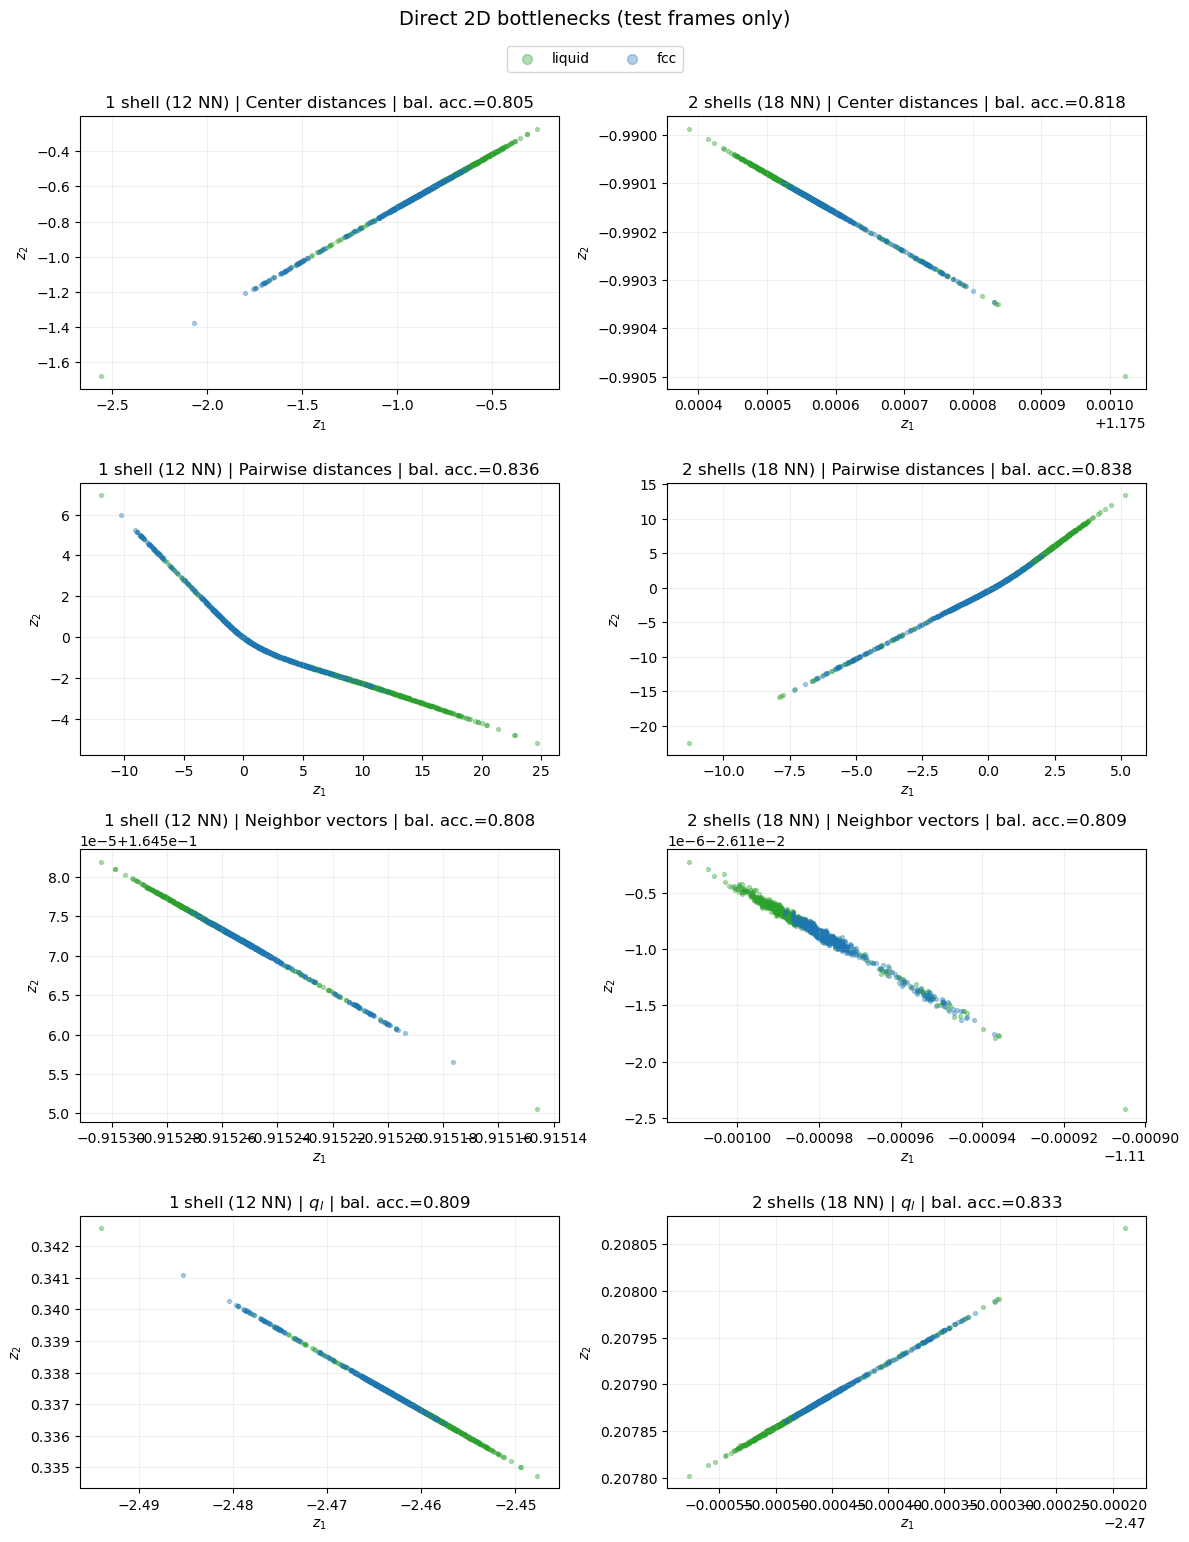

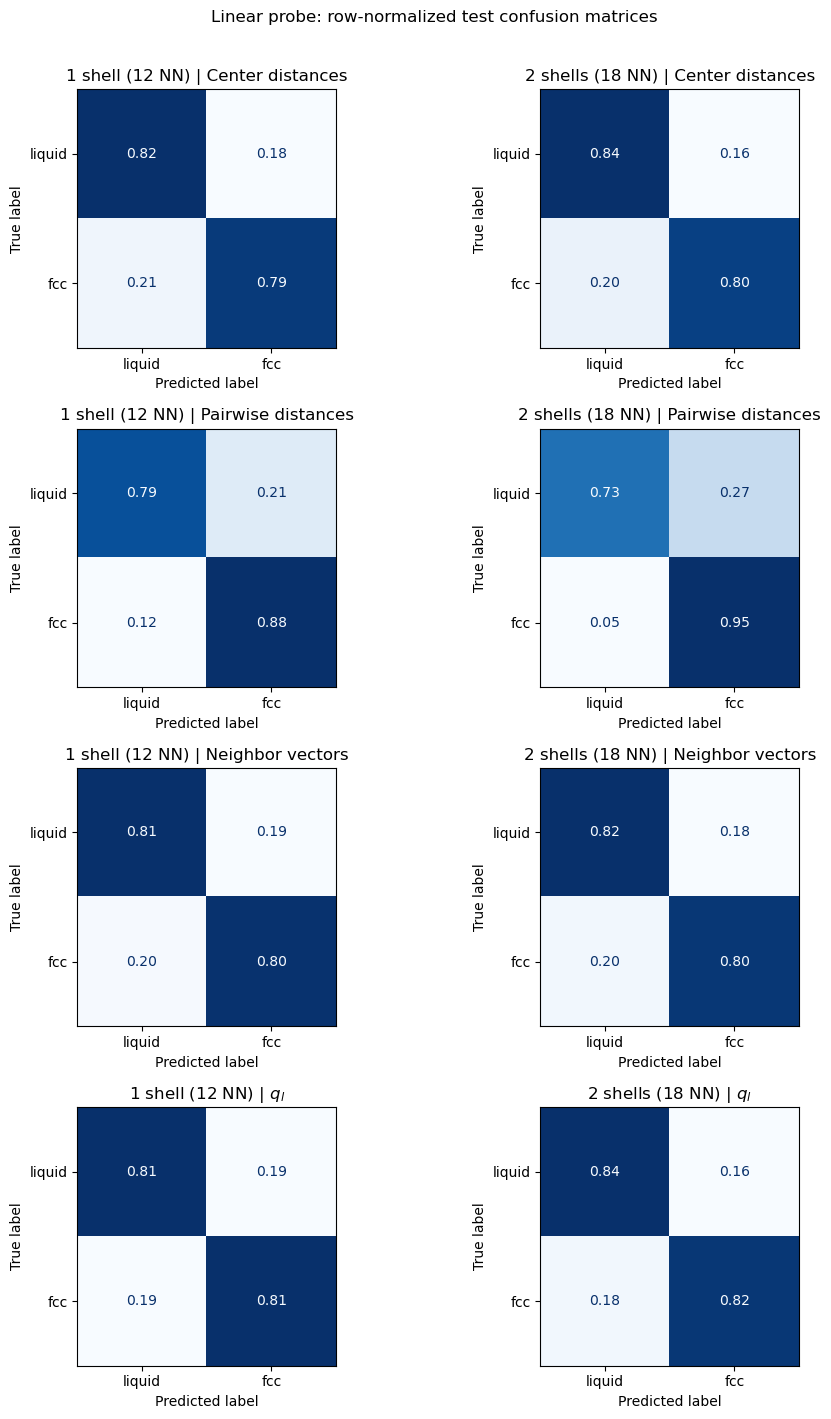

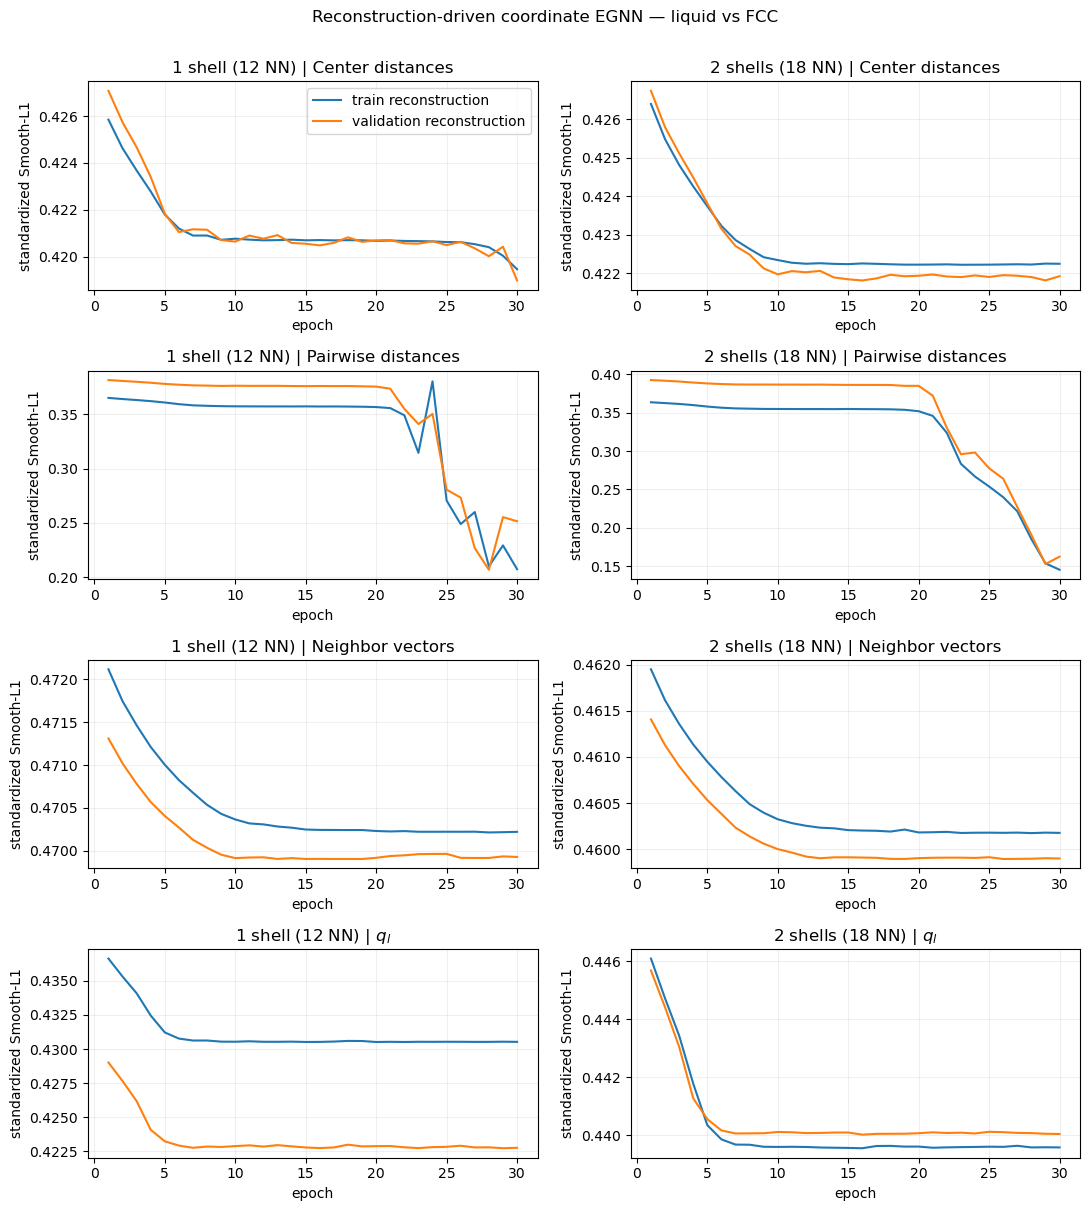

In [106]:
if RUN_RECONSTRUCTION_EGNN_LIQUID_FCC:
    plot_latent_grid(reconstruction_egnn_artifacts, split_to_plot="test")
    plot_confusion_grid(reconstruction_egnn_artifacts)

    fig, axes = plt.subplots(
        len(WORKING_EGNN_TARGET_ORDER),
        len(SHELL_ORDER),
        figsize=(11, 12),
        squeeze=False,
    )
    for row, target_kind in enumerate(WORKING_EGNN_TARGET_ORDER):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            history = reconstruction_egnn_artifacts[
                (shell_name, target_kind)
            ]["history"]
            epochs = np.arange(
                1, len(history["train_reconstruction"]) + 1
            )
            ax.plot(
                epochs,
                history["train_reconstruction"],
                label="train reconstruction",
            )
            ax.plot(
                epochs,
                history["val_reconstruction"],
                label="validation reconstruction",
            )
            ax.set_title(
                f"{SHELL_CONFIG[shell_name]['label']} | "
                f"{WORKING_EGNN_TARGET_LABELS[target_kind]}"
            )
            ax.set_xlabel("epoch")
            ax.set_ylabel("standardized Smooth-L1")
            ax.grid(alpha=0.2)
    axes[0, 0].legend()
    fig.suptitle(
        "Reconstruction-driven coordinate EGNN — liquid vs FCC",
        y=1.005,
    )
    plt.tight_layout()
    plt.show()

### Probe robustness across 30 seeds

The complete balanced sampling, frame-grouped split, EGNN training, encoding, and linear probing pipeline is repeated for the same 30 seeds used above. No plots are produced inside the loop. Balanced accuracy is the primary downstream metric; latent effective rank is reported diagnostically, not optimized. Consequently, a rank near one is an admissible result rather than something the loss is instructed to hide.

Reconstruction-driven EGNN robustness run for seed 0
Reconstruction-driven EGNN robustness run for seed 1
Reconstruction-driven EGNN robustness run for seed 2
Reconstruction-driven EGNN robustness run for seed 3
Reconstruction-driven EGNN robustness run for seed 4
Reconstruction-driven EGNN robustness run for seed 5
Reconstruction-driven EGNN robustness run for seed 6
Reconstruction-driven EGNN robustness run for seed 7
Reconstruction-driven EGNN robustness run for seed 8
Reconstruction-driven EGNN robustness run for seed 9
Reconstruction-driven EGNN robustness run for seed 10
Reconstruction-driven EGNN robustness run for seed 11
Reconstruction-driven EGNN robustness run for seed 12
Reconstruction-driven EGNN robustness run for seed 13
Reconstruction-driven EGNN robustness run for seed 14
Reconstruction-driven EGNN robustness run for seed 15
Reconstruction-driven EGNN robustness run for seed 16
Reconstruction-driven EGNN robustness run for seed 17
Reconstruction-driven EGNN robustness 

,,BA_mean,BA_std,BA_median,BA_min,BA_max,reconstruction_mean,reconstruction_std,rank_mean,rank_std,correlation_median
feature_label,shell_label,,,,,,,,,,
Center distances,1 shell (12 NN),0.8244,0.0226,0.8231,0.7761,0.9095,0.4126,0.0203,1.0005,0.0012,1.0000
Pairwise distances,1 shell (12 NN),0.8358,0.0161,0.8373,0.8066,0.8600,0.2810,0.0680,1.0023,0.0053,0.9998
Neighbor vectors,1 shell (12 NN),0.8220,0.0118,0.8218,0.8017,0.8494,0.4710,0.0006,1.0029,0.0145,1.0000
$q_l$,1 shell (12 NN),0.8250,0.0168,0.8228,0.8016,0.8971,0.4305,0.0065,1.0015,0.0082,1.0000
Center distances,2 shells (18 NN),0.8153,0.0109,0.8177,0.7825,0.8415,0.4230,0.0068,1.0005,0.0023,1.0000
Pairwise distances,2 shells (18 NN),0.8299,0.0111,0.8315,0.7959,0.8504,0.2471,0.0631,1.0073,0.0122,0.9974
Neighbor vectors,2 shells (18 NN),0.8108,0.0158,0.8129,0.7534,0.8380,0.4608,0.0006,1.0086,0.0315,0.9999
$q_l$,2 shells (18 NN),0.8169,0.0125,0.8169,0.7834,0.8415,0.4405,0.0055,1.0000,0.0001,1.0000


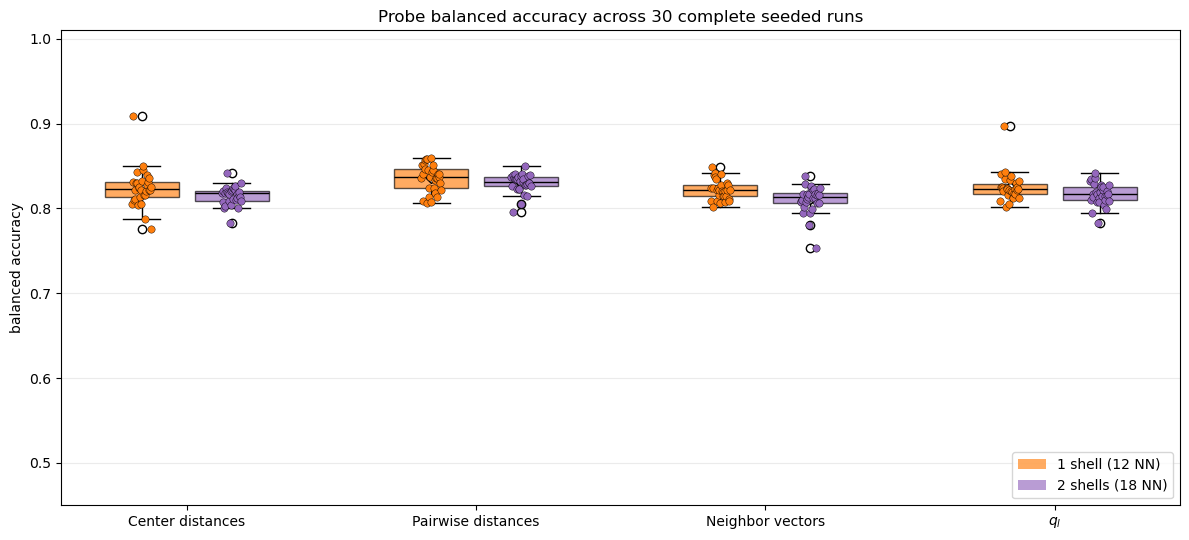

,target_mean_min,target_mean_max,range_across_targets
shell,,,
first_shell,0.8220,0.8358,0.0138
second_shell,0.8108,0.8299,0.0191


In [107]:
if (
    RUN_RECONSTRUCTION_EGNN_LIQUID_FCC
    and RUN_RECONSTRUCTION_EGNN_LIQUID_FCC_ROBUSTNESS
):
    reconstruction_egnn_score_frames = [reconstruction_egnn_scores]
    for seed in ROBUSTNESS_SEEDS:
        if seed == VISUAL_SEED:
            continue
        print(f"Reconstruction-driven EGNN robustness run for seed {seed}")
        seeded_scores, _, _ = run_reconstruction_egnn_liquid_fcc_suite(
            seed,
            keep_artifacts=False,
            verbose=False,
        )
        reconstruction_egnn_score_frames.append(seeded_scores)

    reconstruction_egnn_robustness_scores = pd.concat(
        reconstruction_egnn_score_frames,
        ignore_index=True,
    )
    expected_seed_count = len(set(ROBUSTNESS_SEEDS))
    actual_seed_count = reconstruction_egnn_robustness_scores[
        "seed"
    ].nunique()
    if actual_seed_count != expected_seed_count:
        raise RuntimeError(
            f"Expected {expected_seed_count} seeds, got {actual_seed_count}."
        )

    reconstruction_egnn_robustness_summary = (
        reconstruction_egnn_robustness_scores
        .groupby(["feature_label", "shell_label"], sort=False)
        .agg(
            BA_mean=("balanced_accuracy", "mean"),
            BA_std=("balanced_accuracy", "std"),
            BA_median=("balanced_accuracy", "median"),
            BA_min=("balanced_accuracy", "min"),
            BA_max=("balanced_accuracy", "max"),
            reconstruction_mean=(
                "test_standardized_reconstruction", "mean"
            ),
            reconstruction_std=(
                "test_standardized_reconstruction", "std"
            ),
            rank_mean=("latent_effective_rank", "mean"),
            rank_std=("latent_effective_rank", "std"),
            correlation_median=("latent_abs_correlation", "median"),
        )
    )
    display(reconstruction_egnn_robustness_summary.round(4))
    plot_robustness_boxplots(
        reconstruction_egnn_robustness_scores,
        metric="balanced_accuracy",
    )

    # This table makes target-insensitivity visible instead of relying on
    # visual comparison of four neighboring boxes.
    reconstruction_egnn_target_sensitivity = (
        reconstruction_egnn_robustness_scores
        .groupby(["shell", "feature"], as_index=False)[
            "balanced_accuracy"
        ]
        .mean()
        .groupby("shell")["balanced_accuracy"]
        .agg(target_mean_min="min", target_mean_max="max")
    )
    reconstruction_egnn_target_sensitivity["range_across_targets"] = (
        reconstruction_egnn_target_sensitivity["target_mean_max"]
        - reconstruction_egnn_target_sensitivity["target_mean_min"]
    )
    display(reconstruction_egnn_target_sensitivity.round(4))

### How to read this replacement experiment

This section intentionally does not define success as “the latent must look like a cloud.” First check that training and validation reconstruction decrease together and that the held-out reconstruction differs meaningfully between reconstruction targets. Then compare the 30-seed probe distributions. If different decoder targets now produce different latent geometries or balanced accuracies, that is evidence that reconstruction is shaping the representation. If their probe distributions remain nearly identical, the common graph encoder/readout is the stronger inductive bias even without an explicit latent penalty.

A line-like latent now has a clear interpretation: the selected reconstruction target only made reliable use of one direction in the severe two-dimensional bottleneck. The correct response would then be to enrich or combine the reconstruction task, or to relax the bottleneck—not to force an arbitrary second direction with a stronger shape loss. The vector reconstruction should remain poor because global orientation has been removed by the invariant encoder. Finally, the second-shell averaged $q_l$ result still carries the existing metadata warning until the descriptor is regenerated using all 18 requested neighbors.

## Part VIII — Full-data two-class PCA-decoder EGNN

This final experiment ports the **liquid-versus-FCC** settings selected in
`egnn_reconstruction_signal_exploration.ipynb`. It supersedes the smaller
3,000-sample reconstruction screen above as the definitive reconstruction-aligned
EGNN benchmark.

For every target and shell, a `StandardScaler` and two-component PCA are fitted on
training frames only. The decoder is the fixed PCA inverse transform; only the EGNN
encoder is optimized. This prevents a flexible decoder from ignoring either latent
coordinate. Phase labels are never used by the reconstruction model. They are used
only for balanced sampling, frame-grouped splitting, plots, and the held-out linear
probe.

The port keeps the exploration settings exactly: all 90,300 available samples from
each class, batch size 512, at most 12 epochs, patience 3, Adam at
$3\times10^{-4}$ with weight decay $10^{-6}$, gradient clipping at 1, two
coordinate-updating layers of width 48, 16 radial basis functions, center-aware
readout, and a native two-dimensional latent. The raw-vector target remains a
deliberate negative control because an invariant encoder cannot recover absolute
orientation.

In [ ]:
# Exact binary settings from egnn_reconstruction_signal_exploration.ipynb.
RUN_FINAL_PCA_EGNN_BINARY = True
RUN_FINAL_PCA_EGNN_BINARY_ROBUSTNESS = True

FINAL_PCA_EGNN_SEED = VISUAL_SEED
FINAL_PCA_EGNN_ROBUSTNESS_SEEDS = tuple(dict.fromkeys(ROBUSTNESS_SEEDS))
FINAL_PCA_EGNN_BATCH_SIZE = 512
FINAL_PCA_EGNN_MAX_EPOCHS = 12
FINAL_PCA_EGNN_PATIENCE = 3
FINAL_PCA_EGNN_LEARNING_RATE = 3e-4
FINAL_PCA_EGNN_WEIGHT_DECAY = 1e-6
FINAL_PCA_EGNN_GRAD_CLIP = 1.0
FINAL_PCA_EGNN_FEATURE_DIM = 48
FINAL_PCA_EGNN_MESSAGE_DIM = 48
FINAL_PCA_EGNN_N_LAYERS = 2
FINAL_PCA_EGNN_COORDINATE_UPDATE_SCALE = 0.05
FINAL_PCA_EGNN_LATENT_DIM = 2
FINAL_PCA_EGNN_RBF_COUNT = 16
FINAL_PCA_EGNN_RBF_MAXIMUM = 3.5
FINAL_PCA_EGNN_MAX_SAMPLES_PER_PHASE = None  # full balanced dataset
FINAL_PCA_EGNN_MAX_PLOT_POINTS_PER_PHASE = 3_000
FINAL_PCA_EGNN_TARGET_ORDER = FEATURE_ORDER

if os.environ.get("AE_SMOKE_TEST") == "1":
    FINAL_PCA_EGNN_BATCH_SIZE = 32
    FINAL_PCA_EGNN_MAX_EPOCHS = 1
    FINAL_PCA_EGNN_PATIENCE = 1
    FINAL_PCA_EGNN_MAX_SAMPLES_PER_PHASE = 48


class FinalPCAEGNNMLP(nn.Module):
    def __init__(self, dimensions):
        super().__init__()
        layers = []
        for index in range(len(dimensions) - 1):
            layers.append(nn.Linear(dimensions[index], dimensions[index + 1]))
            if index < len(dimensions) - 2:
                layers.append(nn.SiLU())
        self.network = nn.Sequential(*layers)

    def forward(self, values):
        return self.network(values)


class FinalPCAEGNNRadialBasis(nn.Module):
    def __init__(self):
        super().__init__()
        centers = torch.linspace(
            0.0,
            FINAL_PCA_EGNN_RBF_MAXIMUM,
            FINAL_PCA_EGNN_RBF_COUNT,
        )
        spacing = float(centers[1] - centers[0])
        self.register_buffer("centers", centers)
        self.gamma = 1.0 / spacing**2

    def forward(self, distance):
        return torch.exp(-self.gamma * (distance - self.centers).square())


class FinalPCAEGNNLayer(nn.Module):
    def __init__(self):
        super().__init__()
        width = FINAL_PCA_EGNN_FEATURE_DIM
        message_width = FINAL_PCA_EGNN_MESSAGE_DIM
        self.rbf = FinalPCAEGNNRadialBasis()
        self.edge_mlp = FinalPCAEGNNMLP(
            [
                2 * width + FINAL_PCA_EGNN_RBF_COUNT,
                message_width,
                message_width,
                message_width,
            ]
        )
        self.coordinate_mlp = FinalPCAEGNNMLP(
            [message_width, message_width, 1]
        )
        self.node_mlp = FinalPCAEGNNMLP(
            [width + message_width, width, width]
        )

    def forward(self, features, coordinates, edge_index):
        receivers, senders = edge_index
        relative = coordinates[:, receivers] - coordinates[:, senders]
        squared_distance = relative.square().sum(dim=-1, keepdim=True)
        edge_features = self.rbf(torch.sqrt(squared_distance + 1e-8))
        messages = self.edge_mlp(
            torch.cat(
                [features[:, receivers], features[:, senders], edge_features],
                dim=-1,
            )
        )

        n_nodes = coordinates.shape[1]
        degree = torch.bincount(receivers, minlength=n_nodes).clamp_min(1)
        degree = degree.to(coordinates.dtype).view(1, n_nodes, 1)

        coordinate_weight = torch.tanh(self.coordinate_mlp(messages))
        coordinate_update = torch.zeros_like(coordinates)
        coordinate_update.index_add_(
            1, receivers, relative * coordinate_weight
        )
        coordinates = (
            coordinates
            + FINAL_PCA_EGNN_COORDINATE_UPDATE_SCALE
            * coordinate_update
            / degree
        )

        aggregated = torch.zeros(
            features.shape[0],
            n_nodes,
            FINAL_PCA_EGNN_MESSAGE_DIM,
            device=features.device,
            dtype=features.dtype,
        )
        aggregated.index_add_(1, receivers, messages)
        features = features + self.node_mlp(
            torch.cat([features, aggregated / degree], dim=-1)
        )
        return features, coordinates


class FinalPCAEGNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        width = FINAL_PCA_EGNN_FEATURE_DIM
        # Constant feature plus an explicit marker for the center node.
        self.embedding = FinalPCAEGNNMLP([2, width, width])
        self.layers = nn.ModuleList(
            [FinalPCAEGNNLayer() for _ in range(FINAL_PCA_EGNN_N_LAYERS)]
        )
        self.to_latent = FinalPCAEGNNMLP(
            [3 * width, width, width, FINAL_PCA_EGNN_LATENT_DIM]
        )

    def forward(self, coordinates, edge_index):
        batch_size, n_nodes, _ = coordinates.shape
        ones = torch.ones(
            batch_size,
            n_nodes,
            1,
            device=coordinates.device,
            dtype=coordinates.dtype,
        )
        center_marker = torch.zeros_like(ones)
        center_marker[:, 0] = 1.0
        features = self.embedding(torch.cat([ones, center_marker], dim=-1))

        updated_coordinates = coordinates
        for layer in self.layers:
            features, updated_coordinates = layer(
                features, updated_coordinates, edge_index
            )

        neighbors = features[:, 1:]
        graph_features = torch.cat(
            [
                features[:, 0],
                neighbors.mean(dim=1),
                neighbors.std(dim=1, unbiased=False),
            ],
            dim=-1,
        )
        return self.to_latent(graph_features)


class FinalFixedPCADecoder(nn.Module):
    """Inverse PCA transform stored as a non-trainable linear map."""
    def __init__(self, pca):
        super().__init__()
        self.register_buffer(
            "weight",
            torch.as_tensor(pca.components_.T, dtype=torch.float32),
        )
        self.register_buffer(
            "bias",
            torch.as_tensor(pca.mean_, dtype=torch.float32),
        )

    def forward(self, scores):
        return scores @ self.weight.T + self.bias


class FinalPCAReconstructionEGNN(nn.Module):
    def __init__(self, pca):
        super().__init__()
        self.encoder = FinalPCAEGNNEncoder()
        self.decoder = FinalFixedPCADecoder(pca)

    def forward(self, coordinates, edge_index):
        scores = self.encoder(coordinates, edge_index)
        return self.decoder(scores), scores


def final_complete_edge_index(n_nodes):
    receivers, senders = np.where(~np.eye(n_nodes, dtype=bool))
    return torch.tensor(
        np.stack([receivers, senders]), dtype=torch.long
    )


print("Final PCA-decoder binary EGNN enabled:", RUN_FINAL_PCA_EGNN_BINARY)
print(
    "Final PCA-decoder 30-seed robustness enabled:",
    RUN_FINAL_PCA_EGNN_BINARY_ROBUSTNESS,
)
print("Final PCA-decoder samples per phase: all available balanced samples")
print(
    "Final PCA-decoder robustness seed count:",
    len(FINAL_PCA_EGNN_ROBUSTNESS_SEEDS),
)

In [ ]:
def final_coordinates_with_center(vectors):
    center = np.zeros((len(vectors), 1, 3), dtype=np.float32)
    return np.concatenate([center, vectors.astype(np.float32)], axis=1)


def build_final_pca_binary_plan(seed):
    """Use every minority-class sample and a matched majority-class sample."""
    rng = np.random.default_rng(seed)
    n_per_phase = min(
        len(shell_data["first_shell"][phase]["dist"])
        for phase in PHASES
    )
    if FINAL_PCA_EGNN_MAX_SAMPLES_PER_PHASE is not None:
        n_per_phase = min(
            n_per_phase, FINAL_PCA_EGNN_MAX_SAMPLES_PER_PHASE
        )

    plan = {}
    for phase in PHASES:
        reference = shell_data["first_shell"][phase]
        if len(reference["dist"]) == n_per_phase:
            indices = np.arange(n_per_phase)
        else:
            indices = np.sort(
                rng.choice(
                    len(reference["dist"]),
                    size=n_per_phase,
                    replace=False,
                )
            )
        plan[phase] = {
            "indices": indices,
            "split": _frame_split(
                reference["frame_indices"][indices], rng
            ),
        }
    return plan


def prepare_final_pca_binary(shell_name, target_kind, plan):
    coordinate_parts, target_parts, label_parts, split_parts = [], [], [], []
    for phase in PHASES:
        entry = plan[phase]
        data = shell_data[shell_name][phase]
        vectors = data["vec_dist"][entry["indices"]]
        coordinate_parts.append(final_coordinates_with_center(vectors))
        target_parts.append(build_feature(data, target_kind, entry["indices"]))
        label_parts.append(
            np.full(
                len(entry["indices"]),
                LABEL_MAP[phase],
                dtype=np.int64,
            )
        )
        split_parts.append(entry["split"])

    return (
        np.concatenate(coordinate_parts).astype(np.float32, copy=False),
        np.concatenate(target_parts).astype(np.float32, copy=False),
        np.concatenate(label_parts),
        np.concatenate(split_parts),
    )


def encode_final_pca_egnn(model, coordinates, edge_index):
    chunks = []
    model.eval()
    with torch.no_grad():
        for start in range(0, len(coordinates), FINAL_PCA_EGNN_BATCH_SIZE):
            batch = torch.from_numpy(
                coordinates[start:start + FINAL_PCA_EGNN_BATCH_SIZE]
            ).to(DEVICE)
            chunks.append(model.encoder(batch, edge_index).cpu().numpy())
    return np.concatenate(chunks)


def final_pca_validation_mse(model, loader, edge_index):
    model.eval()
    squared_error = 0.0
    element_count = 0
    with torch.no_grad():
        for coordinate_batch, target_batch in loader:
            coordinate_batch = coordinate_batch.to(DEVICE, non_blocking=True)
            target_batch = target_batch.to(DEVICE, non_blocking=True)
            prediction, _ = model(coordinate_batch, edge_index)
            squared_error += nn.functional.mse_loss(
                prediction, target_batch, reduction="sum"
            ).item()
            element_count += target_batch.numel()
    return squared_error / element_count


def final_latent_diagnostics(latent):
    centered = latent - latent.mean(axis=0, keepdims=True)
    std = centered.std(axis=0)
    covariance = np.cov(centered, rowvar=False)
    eigenvalues = np.maximum(np.linalg.eigvalsh(covariance), 0.0)
    denominator = np.square(eigenvalues).sum()
    effective_rank = (
        float(eigenvalues.sum() ** 2 / denominator)
        if denominator > 0
        else 0.0
    )
    correlation = (
        float(np.corrcoef(centered, rowvar=False)[0, 1])
        if np.all(std >= 1e-12)
        else 1.0
    )
    return {
        "latent_std_1": float(std[0]),
        "latent_std_2": float(std[1]),
        "latent_total_std": float(np.linalg.norm(std)),
        "latent_abs_correlation": abs(correlation),
        "latent_effective_rank": effective_rank,
    }

In [ ]:
def train_final_pca_egnn(
    coordinates,
    targets,
    labels,
    split,
    seed,
    verbose=True,
):
    set_seed(seed)
    train_mask = split == "train"
    val_mask = split == "val"
    test_mask = split == "test"

    radius_scale = float(
        np.median(np.linalg.norm(coordinates[train_mask, 1:], axis=-1))
    )
    if not np.isfinite(radius_scale) or radius_scale <= 0:
        raise ValueError(f"Invalid training coordinate scale: {radius_scale}")
    scaled_coordinates = (coordinates / radius_scale).astype(np.float32)

    target_scaler = StandardScaler().fit(targets[train_mask])
    scaled_targets = target_scaler.transform(targets).astype(np.float32)
    target_pca = PCA(
        n_components=FINAL_PCA_EGNN_LATENT_DIM,
        svd_solver="randomized",
        random_state=seed,
    ).fit(scaled_targets[train_mask])

    edge_index = final_complete_edge_index(
        scaled_coordinates.shape[1]
    ).to(DEVICE)
    model = FinalPCAReconstructionEGNN(target_pca).to(DEVICE)

    initial_latent = encode_final_pca_egnn(
        model, scaled_coordinates, edge_index
    )
    initial_probe = probe_latent(initial_latent, labels, split, seed)
    del initial_latent

    generator = torch.Generator().manual_seed(seed)
    loader_options = {
        "num_workers": 0,
        "pin_memory": torch.cuda.is_available(),
    }
    train_loader = DataLoader(
        TensorDataset(
            torch.from_numpy(scaled_coordinates[train_mask]),
            torch.from_numpy(scaled_targets[train_mask]),
        ),
        batch_size=FINAL_PCA_EGNN_BATCH_SIZE,
        shuffle=True,
        generator=generator,
        **loader_options,
    )
    val_loader = DataLoader(
        TensorDataset(
            torch.from_numpy(scaled_coordinates[val_mask]),
            torch.from_numpy(scaled_targets[val_mask]),
        ),
        batch_size=FINAL_PCA_EGNN_BATCH_SIZE,
        shuffle=False,
        **loader_options,
    )

    optimizer = torch.optim.Adam(
        model.encoder.parameters(),
        lr=FINAL_PCA_EGNN_LEARNING_RATE,
        weight_decay=FINAL_PCA_EGNN_WEIGHT_DECAY,
    )
    history = {"train_mse": [], "val_mse": []}
    best_state = None
    best_val = np.inf
    best_epoch = -1
    stale_epochs = 0

    for epoch in range(FINAL_PCA_EGNN_MAX_EPOCHS):
        model.train()
        squared_error = 0.0
        element_count = 0
        for coordinate_batch, target_batch in train_loader:
            coordinate_batch = coordinate_batch.to(DEVICE, non_blocking=True)
            target_batch = target_batch.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            prediction, _ = model(coordinate_batch, edge_index)
            # Sum target-component errors per sample so wide targets do not
            # dilute the gradient, exactly as in the exploration notebook.
            loss = (prediction - target_batch).square().sum(dim=1).mean()
            if not torch.isfinite(loss):
                raise FloatingPointError("Non-finite PCA-decoder EGNN loss")
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.encoder.parameters(), FINAL_PCA_EGNN_GRAD_CLIP
            )
            optimizer.step()
            squared_error += nn.functional.mse_loss(
                prediction.detach(), target_batch, reduction="sum"
            ).item()
            element_count += target_batch.numel()

        train_mse = squared_error / element_count
        val_mse = final_pca_validation_mse(model, val_loader, edge_index)
        history["train_mse"].append(train_mse)
        history["val_mse"].append(val_mse)
        if verbose:
            print(
                f"epoch={epoch + 1:02d} train_mse={train_mse:.5f} "
                f"val_mse={val_mse:.5f}"
            )

        if val_mse < best_val - 1e-7:
            best_val = val_mse
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= FINAL_PCA_EGNN_PATIENCE:
                break

    if best_state is None:
        raise RuntimeError("PCA-decoder EGNN did not produce a checkpoint")
    model.load_state_dict(best_state)

    latent = encode_final_pca_egnn(model, scaled_coordinates, edge_index)
    trained_probe = probe_latent(latent, labels, split, seed)

    test_coordinates = scaled_coordinates[test_mask]
    prediction_chunks = []
    model.eval()
    with torch.no_grad():
        for start in range(
            0, len(test_coordinates), FINAL_PCA_EGNN_BATCH_SIZE
        ):
            batch = torch.from_numpy(
                test_coordinates[start:start + FINAL_PCA_EGNN_BATCH_SIZE]
            ).to(DEVICE)
            prediction_chunks.append(model(batch, edge_index)[0].cpu().numpy())
    test_prediction = np.concatenate(prediction_chunks)
    test_targets = scaled_targets[test_mask]
    test_mse = float(np.mean((test_prediction - test_targets) ** 2))
    constant_mse = float(np.mean(test_targets**2))

    pca_reconstruction = target_pca.inverse_transform(
        target_pca.transform(test_targets)
    )
    pca_mse = float(np.mean((pca_reconstruction - test_targets) ** 2))
    true_scores = target_pca.transform(test_targets)
    score_r2 = []
    for component in range(FINAL_PCA_EGNN_LATENT_DIM):
        residual = np.mean(
            (latent[test_mask, component] - true_scores[:, component]) ** 2
        )
        variance = np.var(true_scores[:, component])
        score_r2.append(1.0 - residual / max(variance, 1e-20))

    reconstruction_skill = 1.0 - test_mse / constant_mse
    pca_ceiling_skill = 1.0 - pca_mse / constant_mse
    return {
        "model": model,
        "target_scaler": target_scaler,
        "target_pca": target_pca,
        "coordinate_scale": radius_scale,
        "edge_index": edge_index,
        "history": history,
        "Z": latent,
        "probe": trained_probe,
        "best_epoch": best_epoch + 1,
        "validation_mse": float(best_val),
        "test_mse": test_mse,
        "constant_mse": constant_mse,
        "reconstruction_skill": reconstruction_skill,
        "pca_ceiling_skill": pca_ceiling_skill,
        "fraction_of_pca_ceiling": (
            reconstruction_skill / max(pca_ceiling_skill, 1e-20)
        ),
        "PC1_score_R2": score_r2[0],
        "PC2_score_R2": score_r2[1],
        "initial_probe_ba": initial_probe["balanced_accuracy"],
        "trained_probe_ba": trained_probe["balanced_accuracy"],
        "probe_ba_gain": (
            trained_probe["balanced_accuracy"]
            - initial_probe["balanced_accuracy"]
        ),
        **final_latent_diagnostics(latent),
    }

In [ ]:
def run_final_pca_binary_suite(
    seed=FINAL_PCA_EGNN_SEED,
    keep_artifacts=True,
    verbose=True,
):
    plan = build_final_pca_binary_plan(seed)
    rows = []
    artifacts = {}

    for shell_name in SHELL_ORDER:
        shell_config = SHELL_CONFIG[shell_name]
        ql_exact = all(
            shell_data[shell_name][phase]["ql_exact"] for phase in PHASES
        )
        for target_kind in FINAL_PCA_EGNN_TARGET_ORDER:
            if verbose:
                print(
                    f"PCA-decoder EGNN seed={seed:>3} | "
                    f"{shell_config['label']:<18} | "
                    f"{FEATURE_LABELS[target_kind]}"
                )
            coordinates, targets, labels, split = prepare_final_pca_binary(
                shell_name, target_kind, plan
            )
            trained = train_final_pca_egnn(
                coordinates,
                targets,
                labels,
                split,
                seed,
                verbose=verbose,
            )
            rows.append(
                {
                    "seed": seed,
                    "shell": shell_name,
                    "shell_label": shell_config["label"],
                    "n_neighbors": shell_config["n_neighbors"],
                    "target": target_kind,
                    "feature": target_kind,
                    "target_label": FEATURE_LABELS[target_kind],
                    "target_dim": targets.shape[1],
                    "n_samples": len(labels),
                    "best_epoch": trained["best_epoch"],
                    "validation_mse": trained["validation_mse"],
                    "test_mse": trained["test_mse"],
                    "pca_ceiling_skill": trained["pca_ceiling_skill"],
                    "reconstruction_skill": trained["reconstruction_skill"],
                    "fraction_of_pca_ceiling": trained[
                        "fraction_of_pca_ceiling"
                    ],
                    "PC1_score_R2": trained["PC1_score_R2"],
                    "PC2_score_R2": trained["PC2_score_R2"],
                    "initial_probe_ba": trained["initial_probe_ba"],
                    "balanced_accuracy": trained["trained_probe_ba"],
                    "probe_ba_gain": trained["probe_ba_gain"],
                    "latent_total_std": trained["latent_total_std"],
                    "latent_effective_rank": trained[
                        "latent_effective_rank"
                    ],
                    "latent_abs_correlation": trained[
                        "latent_abs_correlation"
                    ],
                    "q_l_variant": (
                        shell_config["ql_variant"]
                        if target_kind == "ql"
                        else pd.NA
                    ),
                    "q_l_exact_requested_NN": (
                        ql_exact if target_kind == "ql" else pd.NA
                    ),
                }
            )
            if keep_artifacts:
                artifacts[(shell_name, target_kind)] = {
                    "Z": trained["Z"],
                    "y": labels,
                    "split": split,
                    "probe": trained["probe"],
                    "history": trained["history"],
                    "model": trained["model"],
                    "target_scaler": trained["target_scaler"],
                    "target_pca": trained["target_pca"],
                    "coordinate_scale": trained["coordinate_scale"],
                    "edge_index": trained["edge_index"],
                }
            del coordinates, targets, labels, trained
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return pd.DataFrame(rows), artifacts, plan


if RUN_FINAL_PCA_EGNN_BINARY:
    (
        final_pca_egnn_scores,
        final_pca_egnn_artifacts,
        final_pca_egnn_plan,
    ) = run_final_pca_binary_suite(
        FINAL_PCA_EGNN_SEED,
        keep_artifacts=True,
        verbose=True,
    )
    display(summarize_plan(final_pca_egnn_plan))
    display(
        final_pca_egnn_scores[
            [
                "shell_label",
                "target_label",
                "n_samples",
                "pca_ceiling_skill",
                "reconstruction_skill",
                "fraction_of_pca_ceiling",
                "PC1_score_R2",
                "PC2_score_R2",
                "initial_probe_ba",
                "balanced_accuracy",
                "probe_ba_gain",
                "latent_total_std",
                "latent_effective_rank",
                "best_epoch",
                "q_l_exact_requested_NN",
            ]
        ].round(4)
    )

    plot_latent_grid(final_pca_egnn_artifacts, split_to_plot="test")
    plot_confusion_grid(final_pca_egnn_artifacts)

    fig, axes = plt.subplots(
        len(FINAL_PCA_EGNN_TARGET_ORDER),
        len(SHELL_ORDER),
        figsize=(11, 12),
        squeeze=False,
    )
    for row, target_kind in enumerate(FINAL_PCA_EGNN_TARGET_ORDER):
        for column, shell_name in enumerate(SHELL_ORDER):
            history = final_pca_egnn_artifacts[
                (shell_name, target_kind)
            ]["history"]
            epochs = np.arange(1, len(history["train_mse"]) + 1)
            axes[row, column].plot(
                epochs, history["train_mse"], label="train"
            )
            axes[row, column].plot(
                epochs, history["val_mse"], label="validation"
            )
            axes[row, column].set_title(
                f"{SHELL_CONFIG[shell_name]['label']} | "
                f"{FEATURE_LABELS[target_kind]}"
            )
            axes[row, column].set_xlabel("epoch")
            axes[row, column].set_ylabel("standardized reconstruction MSE")
            axes[row, column].grid(alpha=0.2)
    axes[0, 0].legend()
    fig.suptitle(
        "Full-data PCA-decoder EGNN — liquid versus FCC",
        y=1.003,
    )
    plt.tight_layout()
    plt.show()

### Balanced accuracy across 30 complete seeds

The loop below repeats balanced sampling, frame-grouped splitting, target scaling,
PCA fitting, EGNN initialization and reconstruction training, encoding, and the
held-out logistic-regression probe for every seed. Thus these are 30 complete
experimental repetitions—not 30 refits of the probe on a single learned latent.

The first table exposes every balanced accuracy (one row per seed and one column per
target/shell combination). The coverage assertion prevents a partial run from being
mistaken for the requested 30-seed result. The second table reports the corresponding
mean, sample standard deviation, median, minimum, maximum, standard error, and normal
95% confidence interval.

In [ ]:
if RUN_FINAL_PCA_EGNN_BINARY and RUN_FINAL_PCA_EGNN_BINARY_ROBUSTNESS:
    final_pca_egnn_score_frames = [final_pca_egnn_scores]
    for seed in FINAL_PCA_EGNN_ROBUSTNESS_SEEDS:
        if seed == FINAL_PCA_EGNN_SEED:
            continue
        print(f"Full-data PCA-decoder EGNN robustness run for seed {seed}")
        seeded_scores, _, _ = run_final_pca_binary_suite(
            seed,
            keep_artifacts=False,
            verbose=False,
        )
        final_pca_egnn_score_frames.append(seeded_scores)

    final_pca_egnn_robustness_scores = pd.concat(
        final_pca_egnn_score_frames,
        ignore_index=True,
    )
    expected_seed_count = len(FINAL_PCA_EGNN_ROBUSTNESS_SEEDS)
    expected_configuration_count = (
        len(SHELL_ORDER) * len(FINAL_PCA_EGNN_TARGET_ORDER)
    )
    coverage = (
        final_pca_egnn_robustness_scores
        .groupby(["target", "shell"])["seed"]
        .nunique()
    )
    if len(coverage) != expected_configuration_count or not (
        coverage == expected_seed_count
    ).all():
        raise RuntimeError(
            "Incomplete robustness result; seed coverage by configuration:\n"
            f"{coverage}"
        )
    duplicated = final_pca_egnn_robustness_scores.duplicated(
        ["seed", "target", "shell"]
    )
    if duplicated.any():
        raise RuntimeError("Duplicate seed/target/shell robustness rows detected")

    # The requested 30 individual balanced accuracies for all eight models.
    final_pca_egnn_balanced_accuracies = (
        final_pca_egnn_robustness_scores
        .pivot(
            index="seed",
            columns=["target_label", "shell_label"],
            values="balanced_accuracy",
        )
        .sort_index()
    )
    if final_pca_egnn_balanced_accuracies.isna().any().any():
        raise RuntimeError("Missing a balanced accuracy in the 30-seed table")
    display(final_pca_egnn_balanced_accuracies.round(5))

    final_pca_egnn_robustness_summary = (
        final_pca_egnn_robustness_scores
        .groupby(["target_label", "shell_label"], sort=False)
        .agg(
            n_seeds=("seed", "nunique"),
            BA_mean=("balanced_accuracy", "mean"),
            BA_std=("balanced_accuracy", "std"),
            BA_median=("balanced_accuracy", "median"),
            BA_min=("balanced_accuracy", "min"),
            BA_max=("balanced_accuracy", "max"),
            reconstruction_mean=("reconstruction_skill", "mean"),
            reconstruction_std=("reconstruction_skill", "std"),
            rank_mean=("latent_effective_rank", "mean"),
            rank_std=("latent_effective_rank", "std"),
        )
    )
    final_pca_egnn_robustness_summary["BA_sem"] = (
        final_pca_egnn_robustness_summary["BA_std"]
        / np.sqrt(final_pca_egnn_robustness_summary["n_seeds"])
    )
    final_pca_egnn_robustness_summary["BA_CI95_low"] = (
        final_pca_egnn_robustness_summary["BA_mean"]
        - 1.96 * final_pca_egnn_robustness_summary["BA_sem"]
    )
    final_pca_egnn_robustness_summary["BA_CI95_high"] = (
        final_pca_egnn_robustness_summary["BA_mean"]
        + 1.96 * final_pca_egnn_robustness_summary["BA_sem"]
    )
    display(final_pca_egnn_robustness_summary.round(5))
    plot_robustness_boxplots(
        final_pca_egnn_robustness_scores,
        metric="balanced_accuracy",
    )

### Interpretation and data-integrity boundary

Compare `reconstruction_skill` with `pca_ceiling_skill` before interpreting probe
accuracy. The former measures what the EGNN recovered; the latter is the best
two-component linear reconstruction available when PCA sees the target directly.
`initial_probe_ba` and `probe_ba_gain` distinguish phase information already present
in an untrained graph encoder from information added by reconstruction training.

The current fallback second-shell files contain 18 geometric neighbors but their
stored Lechner–Dellago averaged $q_l$ descriptors were generated from 12 neighbors.
The notebook preserves the warning and the `q_l_exact_requested_NN` column, so that
row must not be described as an exact 18-neighbor $q_l$ experiment until the NPZs
are regenerated. The 18-neighbor geometry experiments (center distances, pairwise
distances, and vectors) are unaffected.